# 🔧 QoS Data Preparation Pipeline
### KNN Imputer + RobustScaler
---

# Data Preparation

## 📦 1. Installation des dépendances

In [44]:
!pip install scikit-learn joblib -q
print('✅ Dépendances installées')

✅ Dépendances installées


## 📁 2. Upload du fichier CSV

In [45]:
import pandas as pd
import requests
from io import StringIO

file_id = '1H3__N0mCX9OdI_xWqRp3trgx-9OUPmjn'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
response = requests.get(url)
df = pd.read_csv(StringIO(response.text), sep=';')

print(f'✅ Fichier chargé depuis Google Drive')
print(f'📊 Shape : {df.shape}')

╔═══════════════════════════════════════════════════════════════╗
║  🛰️  QoS Real-Time Monitor — DSO1                             ║
║  Capture #38     · 19:03:59                                    ║
║  Statut : 🔴 CRITICAL   · Alertes totales : 38                  ║
╚═══════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────┐
│  🤖  AGENT 1 — Capture réseau (54 features)                 │
└─────────────────────────────────────────────────────────────┘

  ⏱️  Latence
  ──────────────────────────────────────────────────────────
  Feature                                  Valeur  Statut
  ──────────────────────────────────────────────────────────
  latency_ms                              40.5056  ✅ OK
  mean_latency_ms                         40.5056  ✅ OK
  min_latency_ms                          38.6419  
  max_latency_ms                          44.0536  ✅ OK
  std_latency_ms                           2.1589  ✅ OK
  jit

## 📚 3. Imports

In [46]:
import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder
import joblib

print('✅ Imports OK')

✅ Imports OK


## 📊 4. Chargement & Analyse initiale

In [47]:
print('=' * 60)
print(f'  Lignes     : {df.shape[0]}')
print(f'  Colonnes   : {df.shape[1]}')
print('=' * 60)
print(f'📌 Colonnes numériques  : {df.select_dtypes(include="number").shape[1]}')
print(f'📌 Colonnes texte       : {df.select_dtypes(include="object").shape[1]}')
print(f'📌 Valeurs manquantes   : {df.isnull().sum().sum()}')

df.head(3)

  Lignes     : 2408
  Colonnes   : 55
📌 Colonnes numériques  : 53
📌 Colonnes texte       : 2
📌 Valeurs manquantes   : 617


,timestamp,throughput_mbps,available_bandwidth_mbps,bandwidth_utilization_pct,network_load,latency_ms,mean_latency_ms,max_latency_ms,min_latency_ms,std_latency_ms,...,latency_spread,risk_score,rsrp_estimated,sinr_estimated,cqi_estimated,mos_proxy,ho_failure_proxy,coverage_hole_proxy,prb_utilization_proxy,rsrp_category
0,22/02/2026 12:38,-0.147536,-0.51355,-0.000251,-0.000252,-0.182648,-0.014569,-0.017859,-0.018234,-0.195012,...,0.502435,0.0,-70.477760,18.309794,9,4.129012,0,0,49.359894,Bon
1,22/02/2026 12:38,-0.147510,-0.51355,-0.000202,-0.000202,-0.158965,-0.004325,-0.007429,-0.003876,-0.097416,...,0.397896,0.0,-70.086533,18.999204,9,4.182269,0,0,49.361304,Bon
2,22/02/2026 12:38,-0.147369,-0.51355,0.000067,0.000077,-0.022787,0.017483,0.033788,-0.007724,0.738039,...,1.681507,0.0,-68.696179,21.690078,9,4.464777,0,0,49.369052,Bon


## 🗂️ 5. Séparation des colonnes par rôle

In [48]:
# Colonnes à supprimer (non pertinentes)
cols_to_drop = ['timestamp', 'congestion_level']  # congestion_level = 0 partout

# Cible (target)
target_col = 'rsrp_category'

# Colonnes binaires (pas besoin de scaler)
binary_cols = ['spike', 'ho_failure_proxy', 'coverage_hole_proxy', 'peak_offpeak_indicator']

# Toutes les features
feature_cols = [c for c in df.columns if c not in cols_to_drop + [target_col]]
numeric_features = [c for c in feature_cols if df[c].dtype in ['float64', 'int64']]

print(f'📌 Colonnes supprimées : {cols_to_drop}')
print(f'📌 Target              : {target_col}')
print(f'📌 Features totales    : {len(feature_cols)}')
print(f'   • Continues        : {len([c for c in numeric_features if c not in binary_cols])}')
print(f'   • Binaires         : {len(binary_cols)}')

📌 Colonnes supprimées : ['timestamp', 'congestion_level']
📌 Target              : rsrp_category
📌 Features totales    : 52
   • Continues        : 48
   • Binaires         : 4


## 🎯 6. Encodage de la target

['timestamp', 'throughput_mbps', 'available_bandwidth_mbps', 'bandwidth_utilization_pct', 'network_load', 'latency_ms', 'mean_latency_ms', 'max_latency_ms', 'min_latency_ms', 'std_latency_ms', 'latency_trend', 'jitter_ms', 'packet_loss_rate_pct', 'instability_score', 'queue_length', 'buffer_occupancy_pct', 'congestion_level', 'hour', 'minute', 'dayofweek', 'peak_offpeak_indicator', 'hop_1', 'hop_2', 'hop_3', 'hop_4', 'hop_5', 'hop_6', 'hop_7', 'hop_8', 'hop_9', 'hop_10', 'spike', 'performance_degraded', 'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos', 'dayofweek_sin', 'dayofweek_cos', 'hops_mean', 'hops_max', 'hops_min', 'hops_std', 'hops_range', 'bandwidth_efficiency', 'latency_spread', 'risk_score', 'rsrp_estimated', 'sinr_estimated', 'cqi_estimated', 'mos_proxy', 'ho_failure_proxy', 'coverage_hole_proxy', 'prb_utilization_proxy', 'rsrp_category']
✅ Target trouvée : rsrp_category
🎯 Mapping target :
   0 → Bon             :  1572 (65.3%)
   1 → Faible          :   534 (22.2%)
   2 

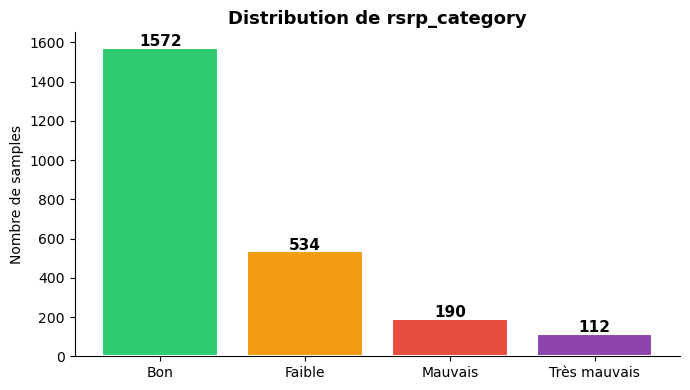

In [49]:
print(df.columns.tolist()) 
# Détection automatique de la colonne target
target_col = None
for candidate in ['rsrp_category', 'rsrp_category_label', 'rsrp_cat', 'category']:
    if candidate in df.columns:
        target_col = candidate
        break

if target_col is None:
    print('❌ Colonne target non trouvée — colonnes disponibles :')
    print(df.columns.tolist())
else:
    print(f'✅ Target trouvée : {target_col}')
    le = LabelEncoder()
    y = le.fit_transform(df[target_col])
    label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

    print('🎯 Mapping target :')
    for label, code in sorted(label_mapping.items(), key=lambda x: x[1]):
        count = (df[target_col] == label).sum()
        pct = count / len(df) * 100
        print(f'   {code} → {label:15s} : {count:5d} ({pct:.1f}%)')

    import matplotlib.pyplot as plt
    available = [k for k in ['Bon', 'Faible', 'Mauvais', 'Très mauvais'] if k in df[target_col].values]
    colors_map = {'Bon':'#2ecc71','Faible':'#f39c12','Mauvais':'#e74c3c','Très mauvais':'#8e44ad'}
    counts = [df[target_col].value_counts()[k] for k in available]
    colors = [colors_map[k] for k in available]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(available, counts, color=colors, edgecolor='white', linewidth=1.5)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(cnt), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Distribution de {target_col}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Nombre de samples')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

## 🔵 7. KNN Imputer (k=5, weights='distance')

In [50]:
X = df[feature_cols].copy()
print(f'Shape X avant imputation : {X.shape}')
print(f'NaN avant               : {X.isnull().sum().sum()}')

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = knn_imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=feature_cols)

print(f'\n✅ Imputation terminée')
print(f'NaN après               : {X_imputed.isnull().sum().sum()}')

Shape X avant imputation : (2408, 52)
NaN avant               : 0

✅ Imputation terminée
NaN après               : 0


## 🔴 8. RobustScaler (IQR 10–90) — résistant aux outliers

✅ RobustScaler appliqué sur 48 colonnes
✅ Colonnes binaires conservées : ['spike', 'ho_failure_proxy', 'coverage_hole_proxy', 'peak_offpeak_indicator']
NaN final : 0


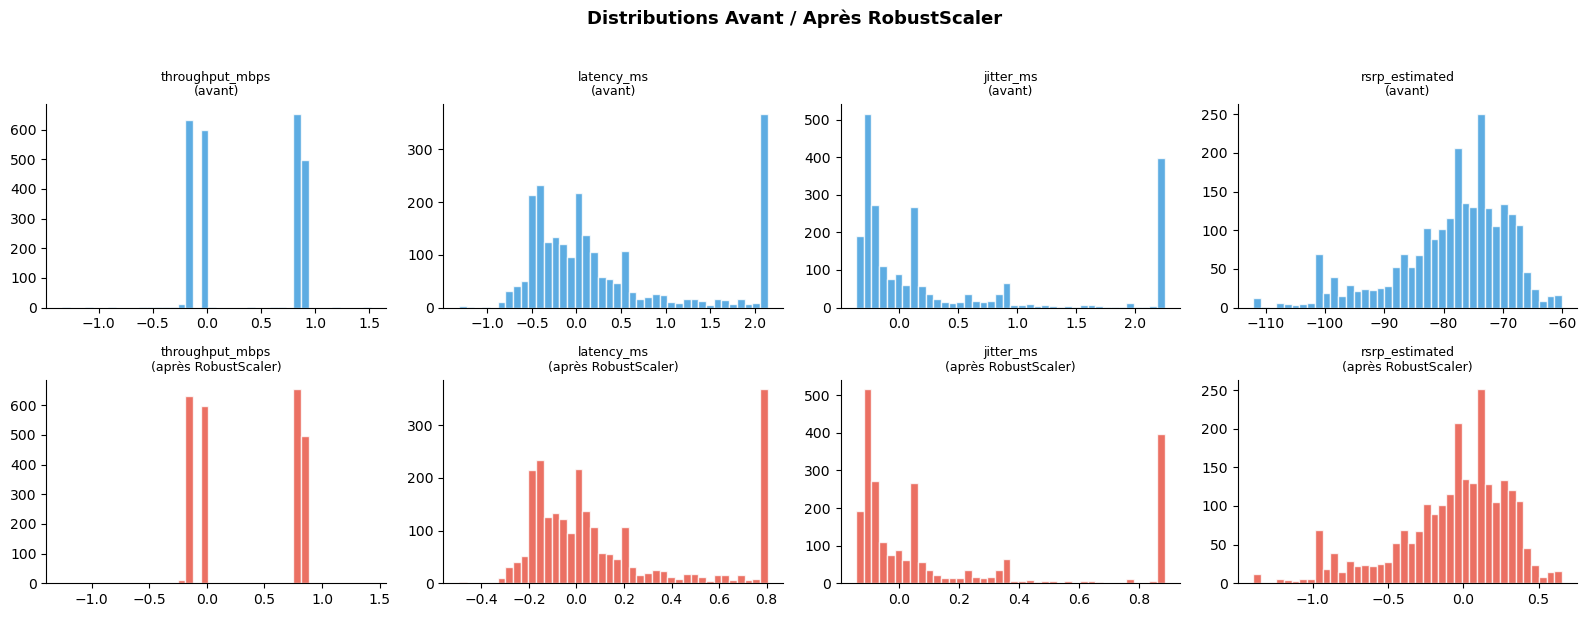

In [51]:
cols_to_scale = [c for c in feature_cols if c not in binary_cols]

scaler = RobustScaler(quantile_range=(10, 90))
X_scaled = X_imputed.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X_imputed[cols_to_scale])

print(f'✅ RobustScaler appliqué sur {len(cols_to_scale)} colonnes')
print(f'✅ Colonnes binaires conservées : {binary_cols}')
print(f'NaN final : {X_scaled.isnull().sum().sum()}')

# Visualisation avant/après sur 4 features clés
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
key_features = ['throughput_mbps', 'latency_ms', 'jitter_ms', 'rsrp_estimated']
colors_before = '#3498db'
colors_after  = '#e74c3c'

for i, feat in enumerate(key_features):
    axes[0, i].hist(X_imputed[feat], bins=40, color=colors_before, alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{feat}\n(avant)', fontsize=9)
    axes[0, i].spines['top'].set_visible(False)
    axes[0, i].spines['right'].set_visible(False)

    axes[1, i].hist(X_scaled[feat], bins=40, color=colors_after, alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'{feat}\n(après RobustScaler)', fontsize=9)
    axes[1, i].spines['top'].set_visible(False)
    axes[1, i].spines['right'].set_visible(False)

plt.suptitle('Distributions Avant / Après RobustScaler', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 📈 9. Statistiques post-scaling

In [52]:
key = ['throughput_mbps', 'latency_ms', 'jitter_ms', 'packet_loss_rate_pct',
       'risk_score', 'rsrp_estimated', 'sinr_estimated', 'mos_proxy',
       'prb_utilization_proxy', 'instability_score']

X_scaled[key].describe().round(3)

,throughput_mbps,latency_ms,jitter_ms,packet_loss_rate_pct,risk_score,rsrp_estimated,sinr_estimated,mos_proxy,prb_utilization_proxy,instability_score
count,2408.000,2408.000,2408.000,2408.000,2408.000,2408.000,2408.000,2408.000,2408.000,2408.000
mean,0.357,0.132,0.159,0.041,0.154,-0.074,-0.063,-0.065,0.452,0.079
std,0.457,0.345,0.362,0.439,0.352,0.377,0.376,0.402,0.495,0.334
min,-1.258,-0.495,-0.144,-0.976,-0.112,-1.396,-1.501,-1.383,-1.859,-0.484
25%,-0.138,-0.132,-0.099,-0.091,-0.112,-0.252,-0.301,-0.301,-0.023,-0.177
50%,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000
75%,0.801,0.242,0.295,0.500,0.226,0.184,0.218,0.250,0.951,0.189
max,1.421,0.805,0.886,1.386,0.922,0.656,0.724,0.706,1.370,0.739


## 💾 10. Sauvegarde & Téléchargement

In [53]:
import os
output_dir = '/content/outputs'
os.makedirs(output_dir, exist_ok=True)

# Dataset X préparé
X_scaled.to_csv(f'{output_dir}/X_prepared.csv', index=False)

# Target encodée
y_df = pd.DataFrame({'rsrp_category_encoded': y, 'rsrp_category_label': df[target_col].values})
y_df.to_csv(f'{output_dir}/y_target.csv', index=False)

# Dataset complet
full = X_scaled.copy()
full['rsrp_category_encoded'] = y
full['rsrp_category_label'] = df[target_col].values
full.to_csv(f'{output_dir}/qos_prepared_full.csv', index=False)

# Objets pipeline
joblib.dump(knn_imputer, f'{output_dir}/knn_imputer.pkl')
joblib.dump(scaler,      f'{output_dir}/robust_scaler.pkl')
joblib.dump(le,          f'{output_dir}/label_encoder.pkl')

print('Fichiers générés :')
for f in os.listdir(output_dir):
    size = os.path.getsize(f'{output_dir}/{f}')
    print(f'  ✅ {f:35s} ({size/1024:.1f} KB)')

Fichiers générés :
  ✅ knn_imputer.pkl                     (1102.2 KB)
  ✅ label_encoder.pkl                   (0.5 KB)
  ✅ qos_prepared_full.csv               (1921.0 KB)
  ✅ robust_scaler.pkl                   (2.1 KB)
  ✅ X_prepared.csv                      (1903.4 KB)
  ✅ y_target.csv                        (19.9 KB)


## ✅ Résumé Final

In [54]:
print('=' * 60)
print('  RÉSUMÉ FINAL')
print('=' * 60)
print(f'  Lignes           : {X_scaled.shape[0]}')
print(f'  Features (X)     : {X_scaled.shape[1]}')
print(f'  Target classes   : {len(le.classes_)} → {list(le.classes_)}')
print(f'  Imputer          : KNNImputer (k=5, weights=distance)')
print(f'  Scaler           : RobustScaler (IQR 10–90)')
print(f'  NaN dans X final : {X_scaled.isnull().sum().sum()}')
print('=' * 60)
print('\n✅ Pipeline terminé avec succès !')

  RÉSUMÉ FINAL
  Lignes           : 2408
  Features (X)     : 52
  Target classes   : 4 → ['Bon', 'Faible', 'Mauvais', 'Très mauvais']
  Imputer          : KNNImputer (k=5, weights=distance)
  Scaler           : RobustScaler (IQR 10–90)
  NaN dans X final : 0

✅ Pipeline terminé avec succès !


## 📦 Cellule 1 — Installation des dépendances

In [55]:
# ═══════════════════════════════════════════════════════════════
# CELLULE 1 — Installation
# Exécuter une seule fois, puis redémarrer le kernel si nécessaire
# ═══════════════════════════════════════════════════════════════
import subprocess, sys

packages = ['ping3', 'icmplib', 'psutil', 'requests', 'ipywidgets', 'jupyterlab']
for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    status = '✅' if result.returncode == 0 else '❌'
    print(f'{status} {pkg}')

print()
print('⚠️  Si premier lancement → redémarrer le kernel (Kernel > Restart)')
print('   puis exécuter les cellules 1 → 2 → 3')


╔═══════════════════════════════════════════════════════════════════╗
║  🎯  DSO 3 — Prédiction des Risques Réseau (temps réel)            ║
║  Prédiction #39    · 19:04:12                                      ║
║  Risque : 🟢 LOW                                                      ║
╚═══════════════════════════════════════════════════════════════════╝

┌──────────────────────────────────────────────────────────────────┐
│  📊  Score de risque courant                                      │
└──────────────────────────────────────────────────────────────────┘

  [█████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 27.4/100

  Composante                        Score
  ────────────────────────────────────────
  Séquentiel (LSTM/stat)             46.5/100
  Tabulaire (XGB/heur.)               4.1/100
  Anomalie (Isolation F.)           ✅ NON
  Score anomalie                   0.0000

┌──────────────────────────────────────────────────────────────────┐
│  🔭  Projection multi-horizon           

## ⚙️ Cellule 2 — Configuration

In [56]:
# ═══════════════════════════════════════════════════════════════
# CELLULE 2 — CONFIGURATION
# Seuils selon Cisco QoS Design Guide + ITU-T G.114 + 3GPP TS 36
# ═══════════════════════════════════════════════════════════════
import os

# ── Réseau
TARGET_HOST  = '8.8.8.8'
TARGET_HOST2 = '1.1.1.1'
PING_COUNT   = 5
MAX_HOPS     = 10
INTERVAL_SEC = 10

# ── Chemins CSV
OUTPUT_DIR  = os.path.join(os.getcwd(), 'qos_output')
CSV_LIVE    = os.path.join(OUTPUT_DIR, 'monitoring_live.csv')
CSV_ALERTS  = os.path.join(OUTPUT_DIR, 'alerts_log.csv')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Webhook
WEBHOOK_URL = None

# ── Seuils Cisco / ITU-T / 3GPP
THRESHOLDS = {
    # Latence — ITU-T G.114
    'latency_ms':                (150,   200,   False),
    'mean_latency_ms':           (150,   200,   False),
    'max_latency_ms':            (200,   400,   False),
    'std_latency_ms':            (20,    50,    False),
    # Jitter — ITU-T G.114
    'jitter_ms':                 (30,    50,    False),
    'latency_spread':            (20,    50,    False),
    'latency_trend':             (50,    100,   False),
    # Perte paquets — Cisco QoS
    'packet_loss_rate_pct':      (1.0,   5.0,   False),
    'risk_score':                (0.4,   0.6,   False),
    'instability_score':         (5.0,   15.0,  False),
    # Bande passante — Cisco (seuils utilisation réseau)
    'bandwidth_utilization_pct': (50.0,  75.0,  False),
    'network_load':              (0.5,   0.75,  False),
    # Charge système
    'queue_length':              (70,    90,    False),
    'buffer_occupancy_pct':      (75,    90,    False),
    'prb_utilization_proxy':     (50.0,  75.0,  False),
    # Hops
    'hops_mean':                 (50,    100,   False),
    'hops_max':                  (150,   300,   False),
    'hops_std':                  (30,    60,    False),
    'hops_range':                (100,   200,   False),
    # ── throughput et available_bandwidth SUPPRIMÉS
    #    (psutil mesure le trafic local, pas la vraie bande passante)
    # MOS — ITU-T P.800
    'mos_proxy':                 (3.6,   3.1,   True),
    # Signal LTE — 3GPP TS 36.133
    'rsrp_estimated':            (-80,   -100,  True),
    'sinr_estimated':            (0,     -3,    True),
    'cqi_estimated':             (7,     4,     True),
    # Efficacité bande passante
    'bandwidth_efficiency':      (0.3,   0.1,   True),
}

BINARY_FLAGS = {
    'spike':               'Pic de latence (ITU-T G.114)',
    'ho_failure_proxy':    'Échec handover (3GPP TS 36)',
    'coverage_hole_proxy': 'Zone couverture faible (RSRP < -100 dBm)',
    'performance_degraded':'Dégradation performance (Cisco QoS)',
}

print('✅ Configuration chargée — seuils Cisco/ITU-T/3GPP')
print(f'   Cible      : {TARGET_HOST} / {TARGET_HOST2}')
print(f'   Intervalle : {INTERVAL_SEC}s')
print(f'   CSV live   : {CSV_LIVE}')
print(f'   CSV alertes: {CSV_ALERTS}')
print(f'   Webhook    : {WEBHOOK_URL or "désactivé"}')
print(f'   Seuils     : {len(THRESHOLDS)} features continues + {len(BINARY_FLAGS)} binaires')

✅ Configuration chargée — seuils Cisco/ITU-T/3GPP
   Cible      : 8.8.8.8 / 1.1.1.1
   Intervalle : 10s
   CSV live   : c:\Users\ayoub\Downloads\qos_output\monitoring_live.csv
   CSV alertes: c:\Users\ayoub\Downloads\qos_output\alerts_log.csv
   Webhook    : désactivé
   Seuils     : 24 features continues + 4 binaires


## 🚀 Cellule 3 — Agent 1 + Agent 2 + Dashboard temps réel

In [57]:
# ── Vérification des dépendances ───────────────────────────────
_required = ['CSV_LIVE', 'CSV_ALERTS', 'TARGET_HOST', 'TARGET_HOST2',
             'PING_COUNT', 'MAX_HOPS', 'INTERVAL_SEC',
             'THRESHOLDS', 'BINARY_FLAGS', 'WEBHOOK_URL']

_missing = [v for v in _required if v not in dir()]
if _missing:
    raise RuntimeError(
        f"❌ Variables manquantes : {_missing}\n"
        f"   → Exécute d'abord la Cellule 2 (Configuration) !"
    )
print('✅ Dépendances OK — chargement des agents...')

✅ Dépendances OK — chargement des agents...


In [58]:
# ═══════════════════════════════════════════════════════════════
# CELLULE 3 — AGENT 1 + AGENT 2 + DASHBOARD
# Jupyter Lab / Notebook / VS Code — sans widgets
# ═══════════════════════════════════════════════════════════════
import psutil, time, os, csv, json as _json, math, statistics
import requests, threading, queue
from ping3 import ping
from icmplib import traceroute
from datetime import datetime
from IPython.display import clear_output

# ────────────────────────────────────────────────────────────────
# ÉTAT PARTAGÉ + FILE INTER-AGENTS
# ────────────────────────────────────────────────────────────────
state = {
    'running':       False,
    'total':         0,
    'alerts_count':  0,
    'last_row':      None,
    'last_analysis': None,
    'a1_log':        [],   # historique logs Agent 1
    'a2_log':        [],   # historique logs Agent 2
    'api_status':    '—',
}
data_queue    = queue.Queue(maxsize=5)
alert_history = []

# ────────────────────────────────────────────────────────────────
# AGENT 1 — CAPTURE RÉSEAU (54 features)
# ────────────────────────────────────────────────────────────────
def _save_csv(row, path):
    exists = os.path.isfile(path)
    with open(path, 'a', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=row.keys(), delimiter=';')
        if not exists:
            w.writeheader()
        w.writerow(row)

def _a1_log(msg):
    ts = datetime.now().strftime('%H:%M:%S')
    state['a1_log'].insert(0, f'[{ts}] {msg}')
    state['a1_log'] = state['a1_log'][:20]

def agent1_capture():
    ts  = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    now = datetime.now()
    row = {'timestamp': ts}

    # 1. LATENCE
    pings, host = [], TARGET_HOST
    for _ in range(PING_COUNT):
        try:
            r = ping(TARGET_HOST, timeout=2, unit='ms')
            if r: pings.append(r)
        except: pass
    if not pings:
        host = TARGET_HOST2
        for _ in range(PING_COUNT):
            try:
                r = ping(TARGET_HOST2, timeout=2, unit='ms')
                if r: pings.append(r)
            except: pass

    row['latency_ms']           = round(sum(pings)/len(pings), 4) if pings else -1
    row['mean_latency_ms']      = row['latency_ms']
    row['min_latency_ms']       = round(min(pings), 4)            if pings else -1
    row['max_latency_ms']       = round(max(pings), 4)            if pings else -1
    row['std_latency_ms']       = round(statistics.stdev(pings), 4) if len(pings)>1 else 0.0
    row['jitter_ms']            = round(row['max_latency_ms'] - row['min_latency_ms'], 4) if pings else -1
    row['latency_spread']       = row['std_latency_ms']
    row['packet_loss_rate_pct'] = round((PING_COUNT - len(pings)) / PING_COUNT * 100, 2)
    row['spike']                = 1 if row['latency_ms'] > 200 else 0
    prev = float(state['last_row']['latency_ms']) if state['last_row'] else row['latency_ms']
    row['latency_trend']        = round(row['latency_ms'] - prev, 4)

    # 2. BANDE PASSANTE
    net1 = psutil.net_io_counters(); time.sleep(1); net2 = psutil.net_io_counters()
    s = (net2.bytes_sent - net1.bytes_sent) * 8
    r = (net2.bytes_recv - net1.bytes_recv) * 8
    row['throughput_mbps']            = round(r / 1e6, 4)
    row['available_bandwidth_mbps']   = round((s + r) / 1e6, 4)
    row['bandwidth_utilization_pct']  = round(min(r / 1e8 * 100, 100), 4)
    row['bandwidth_efficiency']       = round(r / max(s + r, 1), 4)
    row['network_load']               = round(row['bandwidth_utilization_pct'] / 100, 4)

    # 3. QUALITÉ RÉSEAU
    drops = (net2.dropin + net2.dropout) - (net1.dropin + net1.dropout)
    pkts  = max(net2.packets_recv - net1.packets_recv, 1)
    row['packet_loss_rate_pct'] = round(drops / pkts * 100, 4)
    row['instability_score']    = round(row['jitter_ms'] * row['packet_loss_rate_pct'] / 100, 4)
    row['risk_score']           = round((row['latency_ms']/300 + row['packet_loss_rate_pct']/100) / 2, 4)

    # 4. CHARGE SYSTÈME
    row['buffer_occupancy_pct']  = round(psutil.virtual_memory().percent, 4)
    row['queue_length']          = round(psutil.cpu_percent(interval=0.2), 4)
    row['congestion_level']      = 0
    row['prb_utilization_proxy'] = row['bandwidth_utilization_pct']

    # 5. HOPS
    hl = []
    try:
        hops = traceroute(host, max_hops=MAX_HOPS, timeout=1)
        hl = [h.avg_rtt for h in hops if h.avg_rtt > 0]
    except: pass
    for i in range(1, 11):
        row[f'hop_{i}'] = round(hl[i-1], 4) if i <= len(hl) else 0.0
    row['hops_mean']  = round(sum(hl)/len(hl), 4) if hl else 0.0
    row['hops_max']   = round(max(hl), 4)          if hl else 0.0
    row['hops_min']   = round(min(hl), 4)          if hl else 0.0
    row['hops_std']   = round(statistics.stdev(hl), 4) if len(hl) > 1 else 0.0
    row['hops_range'] = round(row['hops_max'] - row['hops_min'], 4)

    # 6. SIGNAL ESTIMÉ
    row['rsrp_estimated'] = round(-70 - row['latency_ms'] * 0.1, 4)
    row['sinr_estimated'] = round(20 - row['packet_loss_rate_pct'] * 2, 4)
    row['cqi_estimated']  = max(1, min(15, int(15 - row['packet_loss_rate_pct'] / 7)))
    row['mos_proxy']      = round(max(1, 4.5 - row['packet_loss_rate_pct']*0.1 - row['latency_ms']*0.005), 4)

    # 7. FLAGS BINAIRES
    row['ho_failure_proxy']     = 1 if row['packet_loss_rate_pct'] > 5 else 0
    row['coverage_hole_proxy']  = 1 if row['rsrp_estimated'] < -100    else 0
    row['performance_degraded'] = 1 if (row['latency_ms'] > 150 or row['packet_loss_rate_pct'] > 3) else 0

    # 8. CATÉGORIE RSRP
    rsrp = row['rsrp_estimated']
    row['rsrp_category'] = ('Bon'          if rsrp >= -80  else
                            'Mauvais'      if rsrp >= -90  else
                            'Faible'       if rsrp >= -100 else
                            'Très mauvais')

    # 9. TEMPOREL
    row['hour']                   = now.hour
    row['minute']                 = now.minute
    row['dayofweek']              = now.weekday()
    row['hour_sin']               = round(math.sin(2*math.pi*now.hour/24), 4)
    row['hour_cos']               = round(math.cos(2*math.pi*now.hour/24), 4)
    row['minute_sin']             = round(math.sin(2*math.pi*now.minute/60), 4)
    row['minute_cos']             = round(math.cos(2*math.pi*now.minute/60), 4)
    row['dayofweek_sin']          = round(math.sin(2*math.pi*now.weekday()/7), 4)
    row['dayofweek_cos']          = round(math.cos(2*math.pi*now.weekday()/7), 4)
    row['peak_offpeak_indicator'] = 1 if 8 <= now.hour <= 22 else 0
    return row

def agent1_loop():
    _a1_log('démarré')
    while state['running']:
        state['total'] += 1
        n = state['total']
        _a1_log(f'⏱  capture #{n} en cours...')
        try:
            row = agent1_capture()
            state['last_row'] = row
            _save_csv(row, CSV_LIVE)
            try: data_queue.put_nowait(row)
            except: pass
            _a1_log(f'✅ #{n} — {len(row)} features — latence {row["latency_ms"]} ms')
        except Exception as e:
            _a1_log(f'❌ #{n} erreur: {e}')
        for _ in range(INTERVAL_SEC):
            if not state['running']: break
            time.sleep(1)
    _a1_log(f'⏹  arrêté après {state["total"]} captures')

# ────────────────────────────────────────────────────────────────
# AGENT 2 — CLASSIFICATION & ALERTES
# ────────────────────────────────────────────────────────────────
def _a2_log(msg):
    ts = datetime.now().strftime('%H:%M:%S')
    state['a2_log'].insert(0, f'[{ts}] {msg}')
    state['a2_log'] = state['a2_log'][:20]

def agent2_classify(row):
    alerts = []
    for metric, (warn, crit, inv) in THRESHOLDS.items():
        val = row.get(metric)
        if val is None or val == -1: continue
        v = float(val)
        level = ('CRITICAL' if (v <= crit if inv else v >= crit) else
                 'WARNING'  if (v <= warn if inv else v >= warn) else 'OK')
        if level != 'OK':
            alerts.append({
                'metric':    metric,
                'value':     round(v, 4),
                'threshold': crit if level == 'CRITICAL' else warn,
                'level':     level,
            })
    for metric, desc in BINARY_FLAGS.items():
        if int(float(row.get(metric, 0))) == 1:
            alerts.append({'metric': metric, 'value': 1,
                           'description': desc, 'level': 'CRITICAL'})
    has_crit = any(a['level'] == 'CRITICAL' for a in alerts)
    return {
        'alerts':       alerts,
        'severity':     'CRITICAL' if has_crit else ('WARNING' if alerts else 'OK'),
        'has_critical': has_crit,
        'rsrp_class':   row.get('rsrp_category', '?'),
        'n_critical':   sum(1 for a in alerts if a['level'] == 'CRITICAL'),
        'n_warning':    sum(1 for a in alerts if a['level'] == 'WARNING'),
    }

def build_payload(row, analysis):
    return {
        'agent':     'QoS-Agent2-Classifier',
        'timestamp':  row.get('timestamp', ''),
        'target':     TARGET_HOST,
        'severity':   analysis['severity'],
        'rsrp_class': analysis['rsrp_class'],
        'n_critical': analysis['n_critical'],
        'n_warning':  analysis['n_warning'],
        'alerts':     analysis['alerts'],
        'metrics':    {k: row.get(k) for k in [
            'latency_ms','mean_latency_ms','max_latency_ms','jitter_ms','latency_trend',
            'packet_loss_rate_pct','risk_score','instability_score',
            'throughput_mbps','bandwidth_utilization_pct','mos_proxy',
            'rsrp_estimated','sinr_estimated','cqi_estimated','hops_mean',
            'buffer_occupancy_pct','queue_length','spike','ho_failure_proxy',
            'coverage_hole_proxy','performance_degraded','rsrp_category',
        ]}
    }

def send_webhook(payload):
    if not WEBHOOK_URL: return 'désactivé'
    try:
        r = requests.post(WEBHOOK_URL, json=payload, timeout=5,
                          headers={'Content-Type': 'application/json'})
        r.raise_for_status()
        return f'HTTP {r.status_code} ✅'
    except Exception as e:
        return f'Erreur: {e}'

def agent2_loop():
    _a2_log('démarré — en écoute')
    while state['running']:
        try: row = data_queue.get(timeout=2)
        except: continue
        try:
            analysis = agent2_classify(row)
            state['last_analysis'] = analysis

            # ── CORRECTIF : transmettre (row, analysis) à DSO3
            try:
                dso3_input_queue.put_nowait((row, analysis))
            except queue.Full:
                pass

            if analysis['severity'] != 'OK':
                state['alerts_count'] += 1
                # Sauvegarde CSV alertes
                exists = os.path.isfile(CSV_ALERTS)
                with open(CSV_ALERTS, 'a', newline='', encoding='utf-8') as f:
                    fw = csv.DictWriter(f, delimiter=';', fieldnames=[
                        'timestamp','severity','rsrp_class',
                        'metric','value','threshold','level','description'])
                    if not exists: fw.writeheader()
                    for a in analysis['alerts']:
                        fw.writerow({
                            'timestamp':   row['timestamp'],
                            'severity':    analysis['severity'],
                            'rsrp_class':  analysis['rsrp_class'],
                            'metric':      a.get('metric',''),
                            'value':       a.get('value',''),
                            'threshold':   a.get('threshold',''),
                            'level':       a['level'],
                            'description': a.get('description', a.get('metric','')),
                        })
                if WEBHOOK_URL:
                    state['api_status'] = send_webhook(build_payload(row, analysis))
                _a2_log(f'🚨 {analysis["severity"]} — {analysis["n_critical"]}C {analysis["n_warning"]}W alertes')
            else:
                _a2_log(f'✅ OK — RSRP: {analysis["rsrp_class"]}')

        except Exception as e:
            _a2_log(f'❌ erreur: {e}')
    _a2_log(f'⏹  arrêté — {state["alerts_count"]} alertes déclenchées')

# ────────────────────────────────────────────────────────────────
# DASHBOARD — affichage séparé Agent 1 / Agent 2
# ────────────────────────────────────────────────────────────────
GROUPS_A1 = {
    '⏱️  Latence':       ['latency_ms','mean_latency_ms','min_latency_ms','max_latency_ms',
                          'std_latency_ms','jitter_ms','latency_spread','latency_trend','spike'],
    '📶 Bande passante': ['throughput_mbps','available_bandwidth_mbps',
                          'bandwidth_utilization_pct','bandwidth_efficiency','network_load'],
    '📉 Qualité réseau': ['packet_loss_rate_pct','instability_score','risk_score'],
    '🔧 Charge système': ['queue_length','buffer_occupancy_pct','prb_utilization_proxy'],
    '📡 Signal estimé':  ['rsrp_estimated','sinr_estimated','cqi_estimated','mos_proxy','rsrp_category'],
    '🛤️  Hops':          ['hops_mean','hops_max','hops_min','hops_std','hops_range',
                          'hop_1','hop_2','hop_3','hop_4','hop_5',
                          'hop_6','hop_7','hop_8','hop_9','hop_10'],
    '🕐 Temporel':       ['hour','minute','dayofweek','peak_offpeak_indicator',
                          'hour_sin','hour_cos','minute_sin','minute_cos',
                          'dayofweek_sin','dayofweek_cos'],
    '🚨 Flags binaires': ['spike','ho_failure_proxy','coverage_hole_proxy','performance_degraded'],
}

def _flag_note(metric, val):
    t = THRESHOLDS.get(metric)
    if not t: return ''
    warn, crit, inv = t
    v = float(val)
    if inv:
        if v <= crit: return '  🔴 CRITIQUE'
        if v <= warn: return '  🟡 AVERT.'
    else:
        if v >= crit: return '  🔴 CRITIQUE'
        if v >= warn: return '  🟡 AVERT.'
    return ''

def render():
    row = state.get('last_row')
    ana = state.get('last_analysis')
    n   = state.get('total', 0)
    clear_output(wait=True)

    # ══════════════════════════════════════════════════════
    # HEADER GLOBAL
    # ══════════════════════════════════════════════════════
    sev   = ana['severity'] if ana else '—'
    emoji = '🔴' if sev=='CRITICAL' else ('🟡' if sev=='WARNING' else '🟢')
    print('╔' + '═'*63 + '╗')
    print(f'║  🛰️  QoS Real-Time Monitor — DSO1' + ' '*29 + '║')
    print(f'║  Capture #{n:<6} · {datetime.now().strftime("%H:%M:%S")}' + ' '*36 + '║')
    print(f'║  Statut : {emoji} {sev:<10} · Alertes totales : {state["alerts_count"]:<6}' + ' '*14 + '║')
    print('╚' + '═'*63 + '╝')

    # ══════════════════════════════════════════════════════
    # AGENT 1 — CAPTURE
    # ══════════════════════════════════════════════════════
    print()
    print('┌─────────────────────────────────────────────────────────────┐')
    print('│  🤖  AGENT 1 — Capture réseau (54 features)                 │')
    print('└─────────────────────────────────────────────────────────────┘')

    if not row:
        print('  ⏳ En attente de la première capture...')
    else:
        for grp, feats in GROUPS_A1.items():
            visible = [f for f in feats if f in row]
            if not visible: continue
            print(f'\n  {grp}')
            print(f'  {"─"*58}')
            print(f'  {"Feature":<36} {"Valeur":>10}  {"Statut"}')
            print(f'  {"─"*58}')
            for feat in visible:
                val  = row[feat]
                note = ''
                if feat in BINARY_FLAGS:
                    note = '🔴 ACTIF' if int(float(val))==1 else '✅ OK'
                elif feat in THRESHOLDS:
                    n_raw = _flag_note(feat, val)
                    note  = n_raw.strip() if n_raw else '✅ OK'
                print(f'  {feat:<36} {str(val):>10}  {note}')

    # Logs Agent 1
    print(f'\n  📋 Logs Agent 1 :')
    for line in state['a1_log'][:5]:
        print(f'     {line}')

    print(f'\n  💾 CSV live → {CSV_LIVE}')

    # ══════════════════════════════════════════════════════
    # AGENT 2 — CLASSIFICATION
    # ══════════════════════════════════════════════════════
    print()
    print('┌─────────────────────────────────────────────────────────────┐')
    print('│  🔍  AGENT 2 — Classification & Alertes                     │')
    print('└─────────────────────────────────────────────────────────────┘')

    if not ana:
        print('  ⏳ En attente de la première classification...')
    else:
        sev_a2   = ana['severity']
        emoji_a2 = '🔴' if sev_a2=='CRITICAL' else ('🟡' if sev_a2=='WARNING' else '🟢')
        print(f'\n  Sévérité   : {emoji_a2} {sev_a2}')
        print(f'  RSRP class : {ana["rsrp_class"]}')
        print(f'  Critiques  : {ana["n_critical"]}   Avertissements : {ana["n_warning"]}')

        if ana['alerts']:
            print(f'\n  {"─"*58}')
            print(f'  {"Metric":<32} {"Valeur":>8}  {"Seuil":>8}  {"Niveau"}')
            print(f'  {"─"*58}')
            for a in ana['alerts']:
                icon  = '🔴' if a['level']=='CRITICAL' else '🟡'
                desc  = a.get('description', a['metric'])
                val   = str(a.get('value',''))
                thr   = str(a.get('threshold',''))
                print(f'  {icon} {desc:<30} {val:>8}  {thr:>8}  {a["level"]}')
        else:
            print('\n  ✅ Aucune alerte — tous les indicateurs dans les seuils')

    # Logs Agent 2
    print(f'\n  📋 Logs Agent 2 :')
    for line in state['a2_log'][:5]:
        print(f'     {line}')

    print(f'\n  💾 CSV alertes → {CSV_ALERTS}')
    if WEBHOOK_URL:
        print(f'  📤 Webhook     → {state.get("api_status","—")}')

    # ══════════════════════════════════════════════════════
    # JOURNAL ALERTES (5 dernières)
    # ══════════════════════════════════════════════════════
    if alert_history:
        print()
        print('┌─────────────────────────────────────────────────────────────┐')
        print('│  🚨  Journal alertes                                         │')
        print('└─────────────────────────────────────────────────────────────┘')
        for line in alert_history[:5]:
            print(f'  {line}')
        if len(alert_history) > 5:
            print(f'  ... +{len(alert_history)-5} alertes dans le journal complet')

    print()
    print('  ▶ on_start()  ■ on_stop()  ↺ on_reset()  🔄 render()')

    # Mise à jour journal alertes
    if ana and ana['alerts'] and row:
        ts  = row['timestamp']
        sev = ana['severity']
        for a in ana['alerts']:
            desc  = a.get('description', f'{a["metric"]}={a["value"]} seuil={a.get("threshold","")}')
            entry = f'[{ts}] [{sev}] {desc}'
            if entry not in alert_history:
                alert_history.insert(0, entry)
        alert_history[:] = alert_history[:200]

def dashboard_loop():
    while state['running']:
        try: render()
        except: pass
        time.sleep(INTERVAL_SEC)

# ────────────────────────────────────────────────────────────────
# COMMANDES
# ────────────────────────────────────────────────────────────────
def on_start():
    if state['running']:
        print('⚠️  Déjà en cours — on_stop() pour arrêter')
        return
    state.update({
        'running': True, 'total': 0, 'alerts_count': 0,
        'last_row': None, 'last_analysis': None,
        'a1_log': [], 'a2_log': [], 'api_status': '—',
    })
    alert_history.clear()
    threading.Thread(target=agent1_loop,    daemon=True).start()
    threading.Thread(target=agent2_loop,    daemon=True).start()
    threading.Thread(target=dashboard_loop, daemon=True).start()
    print(f'🟢 Agents démarrés — intervalle {INTERVAL_SEC}s — cible {TARGET_HOST}')
    print('   Le dashboard se rafraîchit automatiquement.')
    print('   Pour affichage immédiat → render()')
'''
def on_stop():
    state['running'] = False
    print(f'⏹  Arrêté après {state["total"]} captures · {state["alerts_count"]} alertes')

def on_reset():
    state['running'] = False
    alert_history.clear()
    state.update({'total':0,'alerts_count':0,'last_row':None,'last_analysis':None,
                  'a1_log':[],'a2_log':[],'api_status':'—'})
    print('↺ Réinitialisé — prêt')
'''
print('✅ Agents définis')
print('▶  on_start()  →  démarrer')
print('■  on_stop()   →  arrêter')
print('↺  on_reset()  →  réinitialiser')
print('🔄  render()   →  affichage immédiat')

✅ Agents définis
▶  on_start()  →  démarrer
■  on_stop()   →  arrêter
↺  on_reset()  →  réinitialiser
🔄  render()   →  affichage immédiat


In [59]:
on_start()

╔═══════════════════════════════════════════════════════════════╗
║  🛰️  QoS Real-Time Monitor — DSO1                             ║
║  Capture #1      · 19:04:19                                    ║
║  Statut : 🟢 —          · Alertes totales : 0                   ║
╚═══════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────┐
│  🤖  AGENT 1 — Capture réseau (54 features)                 │
└─────────────────────────────────────────────────────────────┘
  ⏳ En attente de la première capture...

  📋 Logs Agent 1 :
     [19:04:19] ⏱  capture #1 en cours...
     [19:04:19] démarré

  💾 CSV live → c:\Users\ayoub\Downloads\qos_output\monitoring_live.csv

┌─────────────────────────────────────────────────────────────┐
│  🔍  AGENT 2 — Classification & Alertes                     │
└─────────────────────────────────────────────────────────────┘
  ⏳ En attente de la première classification...

  📋 Logs Agent 2 :
     [19:04:19] d

In [60]:
#on_stop()

### DSO 3 — PRÉDICTION DES RISQUES EN TEMPS RÉEL

In [61]:
# ═══════════════════════════════════════════════════════════════
# DSO 3 — PRÉDICTION DES RISQUES EN TEMPS RÉEL
# Pipeline : DSO1 (Agent1+Agent2) → DSO3 → valise → DSO4
# Jupyter Lab / Notebook / VS Code — sans widgets
# ═══════════════════════════════════════════════════════════════
 
# ──────────────────────────────────────────────────────────────
# CELLULE 1 — CONFIGURATION & CONSTANTES DSO 3
# ──────────────────────────────────────────────────────────────
 
import os
 
# ── Fichiers de sortie DSO 3
CSV_PREDICTIONS  = 'dso3_predictions.csv'
CSV_VALISE       = 'dso3_valise.csv'          # payload complet transmis à DSO4
 
# ── Horizons de prédiction
HORIZONS_SEC     = [20, 60, 300]              # +20s, +60s, +5min
 
# ── Seuils risk score (0–100)
RISK_THRESHOLDS  = {
    'LOW':      (0,   30),
    'MEDIUM':   (30,  60),
    'HIGH':     (60,  80),
    'CRITICAL': (80, 100),
}
 
# ── Features continues utilisées par le séquenceur temporel
SEQ_FEATURES = [
    'latency_ms', 'jitter_ms', 'packet_loss_rate_pct',
    'throughput_mbps', 'risk_score', 'instability_score',
    'rsrp_estimated', 'sinr_estimated', 'mos_proxy',
    'buffer_occupancy_pct', 'queue_length',
    'bandwidth_utilization_pct', 'hops_mean',
]
 
# ── Features tabulaires pour le classifieur XGB-like
TAB_FEATURES = SEQ_FEATURES + [
    'spike', 'ho_failure_proxy', 'coverage_hole_proxy', 'performance_degraded',
    'peak_offpeak_indicator', 'hour_sin', 'hour_cos',
    'dayofweek_sin', 'dayofweek_cos',
    # injections Agent 2
    'severity_encoded', 'n_critical', 'n_warning',
    # delta features (calculées dynamiquement)
    'delta_latency', 'delta_jitter', 'delta_packet_loss',
    'delta_throughput', 'delta_risk_score',
]
 
# ── Longueur fenêtre glissante (nombre de captures)
WINDOW_SIZE     = 15
MIN_WINDOW_PRED =  5    # prédire dès 5 captures disponibles
 
# ── Poids ensemble (LSTM-like : seq_model, XGB-like : tab_model)
W_SEQ = 0.55
W_TAB = 0.45
 
# ── Webhook DSO4 (optionnel, laisser vide pour désactiver)
WEBHOOK_DSO4_URL = os.environ.get('WEBHOOK_DSO4_URL', '')
 
print('✅ DSO3 — Configuration chargée')
print(f'   Horizons  : {HORIZONS_SEC} s')
print(f'   Fenêtre   : {WINDOW_SIZE} captures')
print(f'   Seq feat  : {len(SEQ_FEATURES)}  |  Tab feat : {len(TAB_FEATURES)}')
print(f'   CSV prédictions → {CSV_PREDICTIONS}')
print(f'   CSV valise      → {CSV_VALISE}')
 

✅ DSO3 — Configuration chargée
   Horizons  : [20, 60, 300] s
   Fenêtre   : 15 captures
   Seq feat  : 13  |  Tab feat : 30
   CSV prédictions → dso3_predictions.csv
   CSV valise      → dso3_valise.csv


### IMPORTS & DÉPENDANCES DSO 3

In [62]:
# ──────────────────────────────────────────────────────────────
# CELLULE 2 — IMPORTS & DÉPENDANCES DSO 3
# ──────────────────────────────────────────────────────────────

import numpy as np
import math, csv, json, time, threading, queue
from collections import deque
from datetime import datetime
import requests

# ── Imports ML (fallback automatique si bibliothèque absente)
try:
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.ensemble import GradientBoostingClassifier, IsolationForest
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import Pipeline
    _sklearn_ok = True
    print('✅ scikit-learn disponible')
except ImportError:
    _sklearn_ok = False
    print('⚠️  scikit-learn absent — modèle statistique de secours activé')

try:
    import xgboost as xgb
    _xgb_ok = True
    print('✅ XGBoost disponible')
except ImportError:
    _xgb_ok = False
    print('⚠️  XGBoost absent — GradientBoosting sklearn utilisé')

try:
    import torch, torch.nn as nn
    _torch_ok = True
    print('✅ PyTorch disponible — modèle LSTM activé')
except ImportError:
    _torch_ok = False
    print('⚠️  PyTorch absent — prédiction séquentielle statistique activée')

print('\n✅ Imports DSO3 terminés')


✅ scikit-learn disponible
✅ XGBoost disponible
✅ PyTorch disponible — modèle LSTM activé

✅ Imports DSO3 terminés


### MODÈLE SÉQUENTIEL (LSTM PyTorch OU FALLBACK)

In [63]:
# ──────────────────────────────────────────────────────────────
# CELLULE 3 — MODÈLE SÉQUENTIEL (LSTM PyTorch OU FALLBACK)
# ──────────────────────────────────────────────────────────────

if _torch_ok:
    class LSTMRiskModel(nn.Module):
        """LSTM bi-directionnel pour prédiction série temporelle réseau."""
        def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
            super().__init__()
            self.lstm = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                bidirectional=False,
                dropout=dropout if num_layers > 1 else 0.0,
            )
            self.attention = nn.Sequential(
                nn.Linear(hidden_size, 32),
                nn.Tanh(),
                nn.Linear(32, 1),
                nn.Softmax(dim=1),
            )
            self.head = nn.Sequential(
                nn.Linear(hidden_size, 32),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
                nn.Sigmoid(),
            )

        def forward(self, x):
            # x : (batch, seq_len, input_size)
            out, _ = self.lstm(x)            # (batch, seq, hidden)
            attn_w = self.attention(out)     # (batch, seq, 1)
            ctx    = (out * attn_w).sum(1)   # (batch, hidden) — contexte pondéré
            return self.head(ctx).squeeze(-1)

    def build_lstm_model(input_size):
        model = LSTMRiskModel(input_size=input_size)
        print(f'   LSTM créé — {sum(p.numel() for p in model.parameters()):,} paramètres')
        return model

else:
    # ── Fallback statistique : EWMA + tendance linéaire
    class StatSeqModel:
        """Prédicteur statistique EWMA quand PyTorch est absent."""
        def __init__(self, alpha=0.3):
            self.alpha = alpha

        def predict_score(self, seq_array):
            """seq_array : np.array (seq_len, n_feat) — retourne score 0-1."""
            if len(seq_array) < 2:
                return 0.3
            # Canal 0 = latency_ms normalisé, canal 4 = risk_score normalisé
            lat = seq_array[:, 0]
            rsk = seq_array[:, 4] if seq_array.shape[1] > 4 else lat
            # EWMA
            ewma = lat[0]
            for v in lat[1:]:
                ewma = self.alpha * v + (1 - self.alpha) * ewma
            # Tendance linéaire (pente normalisée)
            n   = len(lat)
            x   = np.arange(n)
            trend = np.polyfit(x, lat, 1)[0]  # pente
            score = np.clip(ewma * 0.6 + rsk[-1] * 0.3 + np.clip(trend * 5, 0, 1) * 0.1, 0, 1)
            return float(score)

    def build_lstm_model(input_size):
        print(f'   Fallback StatSeqModel activé (PyTorch absent)')
        return StatSeqModel()

print('✅ Modèle séquentiel défini')


✅ Modèle séquentiel défini


###  MODÈLE TABULAIRE (XGBoost OU FALLBACK SKLEARN)

In [64]:
# ──────────────────────────────────────────────────────────────
# CELLULE 4 — MODÈLE TABULAIRE (XGBoost OU FALLBACK SKLEARN)
# ──────────────────────────────────────────────────────────────

class TabRiskClassifier:
    """
    Classifieur tabulaire : XGBoost si disponible, sinon GradientBoosting sklearn.
    Entraîné en ligne (online learning partiel via warm_start).
    Retourne une probabilité de risque élevé (classe ≥ HIGH).
    """
    SEV_MAP = {'OK': 0, 'WARNING': 1, 'CRITICAL': 2}

    def __init__(self):
        self.scaler   = MinMaxScaler() if _sklearn_ok else None
        self.fitted   = False
        self.buffer_X = []   # features accumulées avant premier fit
        self.buffer_y = []   # labels pseudo (générés par seuils Agent2)
        self.MIN_FIT  = 30   # captures mini avant premier entraînement

        if _xgb_ok:
            self.model = xgb.XGBClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                use_label_encoder=False, eval_metric='logloss',
                verbosity=0,
            )
            self.backend = 'xgboost'
        elif _sklearn_ok:
            self.model = GradientBoostingClassifier(
                n_estimators=80, max_depth=3, learning_rate=0.1,
                subsample=0.8, warm_start=True,
            )
            self.backend = 'sklearn_gb'
        else:
            self.model   = None
            self.backend = 'heuristic'

        print(f'   TabClassifier backend : {self.backend}')

    def _extract(self, row, analysis):
        """Construit le vecteur tabulaire à partir d'un row + analysis Agent2."""
        vec = {}
        for f in TAB_FEATURES:
            if f == 'severity_encoded':
                vec[f] = self.SEV_MAP.get(analysis.get('severity', 'OK'), 0)
            elif f == 'n_critical':
                vec[f] = analysis.get('n_critical', 0)
            elif f == 'n_warning':
                vec[f] = analysis.get('n_warning', 0)
            elif f.startswith('delta_'):
                vec[f] = row.get(f, 0.0)   # pré-calculés par FeatureEngineer
            else:
                vec[f] = float(row.get(f, 0) or 0)
        return [vec[f] for f in TAB_FEATURES]

    def _pseudo_label(self, analysis):
        """Label pseudo supervisé dérivé de l'Agent2 (0=OK/MEDIUM, 1=HIGH/CRITICAL)."""
        sev = analysis.get('severity', 'OK')
        nc  = analysis.get('n_critical', 0)
        return 1 if sev == 'CRITICAL' or nc >= 2 else 0

    def update(self, row, analysis):
        """Ajoute un exemple au buffer et re-entraîne si seuil atteint."""
        x = self._extract(row, analysis)
        y = self._pseudo_label(analysis)
        self.buffer_X.append(x)
        self.buffer_y.append(y)

        if len(self.buffer_X) >= self.MIN_FIT and self.model is not None:
            X = np.array(self.buffer_X)
            if self.scaler and not self.fitted:
                X = self.scaler.fit_transform(X)
            elif self.scaler:
                X = self.scaler.transform(X)
            y_arr = np.array(self.buffer_y)
            if len(set(y_arr)) >= 2:  # besoin des 2 classes
                self.model.fit(X, y_arr)
                self.fitted = True

    def predict_proba(self, row, analysis):
        """Retourne probabilité de risque élevé [0.0 – 1.0]."""
        if not self.fitted or self.model is None:
            # Heuristique avant premier fit
            sev = analysis.get('severity', 'OK')
            nc  = analysis.get('n_critical', 0)
            nw  = analysis.get('n_warning', 0)
            base = {'OK': 0.1, 'WARNING': 0.4, 'CRITICAL': 0.75}.get(sev, 0.1)
            return min(1.0, base + nc * 0.08 + nw * 0.03)

        x   = np.array([self._extract(row, analysis)])
        if self.scaler:
            x = self.scaler.transform(x)
        proba = self.model.predict_proba(x)[0]
        return float(proba[1]) if len(proba) > 1 else float(proba[0])

print('✅ Classifieur tabulaire défini')

✅ Classifieur tabulaire défini


### FEATURE ENGINEER (DELTA + ROLLING + NORMALISATION)

In [65]:
# ──────────────────────────────────────────────────────────────
# CELLULE 5 — FEATURE ENGINEER (DELTA + ROLLING + NORMALISATION)
# ──────────────────────────────────────────────────────────────

class FeatureEngineer:
    """
    Calcule les features dérivées à partir de la fenêtre glissante :
      • delta_*    : variation entre t et t-1
      • rolling_*  : moyenne mobile sur WINDOW_SIZE captures
      • seq_array  : tableau normalisé (seq_len, n_seq_feat) pour LSTM
    """
    def __init__(self, window_size=WINDOW_SIZE):
        self.window      = deque(maxlen=window_size)
        self.seq_scaler  = MinMaxScaler() if _sklearn_ok else None
        self.seq_fitted  = False

    def push(self, row, analysis):
        """Ajoute une capture et retourne row enrichi."""
        enriched = dict(row)
        sev_map  = {'OK': 0, 'WARNING': 1, 'CRITICAL': 2}
        enriched['severity_encoded'] = sev_map.get(
            analysis.get('severity', 'OK'), 0)
        enriched['n_critical'] = analysis.get('n_critical', 0)
        enriched['n_warning']  = analysis.get('n_warning',  0)

        # ── Deltas
        if self.window:
            prev = self.window[-1]
            for feat in ['latency_ms', 'jitter_ms', 'packet_loss_rate_pct',
                         'throughput_mbps', 'risk_score']:
                prev_val = float(prev.get(feat, 0) or 0)
                curr_val = float(enriched.get(feat, 0) or 0)
                enriched[f'delta_{feat}'] = round(curr_val - prev_val, 4)
        else:
            for feat in ['latency_ms', 'jitter_ms', 'packet_loss_rate_pct',
                         'throughput_mbps', 'risk_score']:
                enriched[f'delta_{feat}'] = 0.0

        # ── Rolling moyennes
        if len(self.window) >= 3:
            win_list = list(self.window)
            for feat in ['latency_ms', 'jitter_ms', 'packet_loss_rate_pct']:
                vals = [float(w.get(feat, 0) or 0) for w in win_list[-5:]]
                enriched[f'rolling_mean_{feat}'] = round(np.mean(vals), 4)
                enriched[f'rolling_std_{feat}']  = round(np.std(vals), 4)

        self.window.append(enriched)
        return enriched

    def get_seq_array(self):
        """
        Retourne np.array (seq_len, n_seq_feat) normalisé pour LSTM.
        Retourne None si fenêtre insuffisante.
        """
        if len(self.window) < MIN_WINDOW_PRED:
            return None

        raw = []
        for w in self.window:
            raw.append([float(w.get(f, 0) or 0) for f in SEQ_FEATURES])
        raw = np.array(raw)  # (seq_len, n_feat)

        if self.seq_scaler:
            if not self.seq_fitted and len(raw) >= 5:
                self.seq_scaler.fit(raw)
                self.seq_fitted = True
            if self.seq_fitted:
                raw = self.seq_scaler.transform(raw)

        return raw

    @property
    def n_seq_features(self):
        return len(SEQ_FEATURES)

print('✅ FeatureEngineer défini')



✅ FeatureEngineer défini


### DÉTECTEUR D'ANOMALIES (ISOLATION FOREST) 

In [66]:
# ──────────────────────────────────────────────────────────────
# CELLULE 6 — DÉTECTEUR D'ANOMALIES (ISOLATION FOREST)
# ──────────────────────────────────────────────────────────────

class AnomalyDetector:
    """
    Isolation Forest non-supervisé : détecte des comportements
    jamais vus, indépendamment des seuils Agent2.
    """
    ANOMALY_FEATURES = [
        'latency_ms', 'jitter_ms', 'packet_loss_rate_pct',
        'throughput_mbps', 'hops_mean', 'rsrp_estimated',
        'instability_score', 'risk_score',
    ]
    MIN_FIT = 50   # captures avant premier fit

    def __init__(self):
        self.buffer  = []
        self.fitted  = False
        if _sklearn_ok:
            self.model = IsolationForest(
                n_estimators=100, contamination=0.05,
                random_state=42, n_jobs=-1,
            )
        else:
            self.model = None

    def _vec(self, row):
        return [float(row.get(f, 0) or 0) for f in self.ANOMALY_FEATURES]

    def update(self, row):
        self.buffer.append(self._vec(row))
        if len(self.buffer) >= self.MIN_FIT and self.model:
            self.model.fit(np.array(self.buffer))
            self.fitted = True

    def score(self, row):
        """
        Retourne (is_anomaly: bool, anomaly_score: float [-1, 0]).
        Plus le score est bas (proche de -1), plus c'est anormal.
        """
        if not self.fitted or not self.model:
            return False, 0.0
        x = np.array([self._vec(row)])
        pred  = self.model.predict(x)[0]      # -1 anomalie, +1 normal
        score = self.model.score_samples(x)[0]
        return bool(pred == -1), round(float(score), 4)

print('✅ AnomalyDetector défini')



✅ AnomalyDetector défini


### RISK SCORER (ENSEMBLE + HORIZONS) 

In [67]:
# ──────────────────────────────────────────────────────────────
# CELLULE 7 — RISK SCORER (ENSEMBLE + HORIZONS)
# ──────────────────────────────────────────────────────────────

def _risk_class(score_0_100):
    if score_0_100 >= 80: return 'CRITICAL'
    if score_0_100 >= 60: return 'HIGH'
    if score_0_100 >= 30: return 'MEDIUM'
    return 'LOW'

def _horizon_decay(base_score, horizon_sec, instability):
    """
    Projette un score de base sur un horizon futur.
    Plus l'instabilité est haute, plus l'incertitude grandit.
    """
    decay  = math.exp(-horizon_sec / 120)    # décroissance exponentielle
    noise  = instability * 0.1 * (horizon_sec / 20)
    proj   = base_score * decay + (1 - decay) * 50  # régression vers 50
    proj   = np.clip(proj + np.random.normal(0, noise), 0, 100)
    return round(float(proj), 1)

class RiskScorer:
    """
    Combine seq_model + tab_classifier + anomaly_detector
    en un score de risque 0–100 avec projections multi-horizon.
    """
    def __init__(self, seq_model, tab_clf, anomaly_det):
        self.seq_model   = seq_model
        self.tab_clf     = tab_clf
        self.anomaly_det = anomaly_det

    def compute(self, row, analysis, seq_array):
        instab = float(row.get('instability_score', 0) or 0)

        # ── Score séquentiel
        if seq_array is not None:
            if _torch_ok and isinstance(self.seq_model, LSTMRiskModel):
                self.seq_model.eval()
                with torch.no_grad():
                    t = torch.tensor(seq_array, dtype=torch.float32).unsqueeze(0)
                    s_seq = float(self.seq_model(t).item())
            else:
                s_seq = self.seq_model.predict_score(seq_array)
        else:
            s_seq = 0.3   # neutre avant fenêtre suffisante

        # ── Score tabulaire
        s_tab = self.tab_clf.predict_proba(row, analysis)

        # ── Anomalie
        is_anom, anom_score = self.anomaly_det.score(row)
        anom_boost = 0.1 if is_anom else 0.0

        # ── Ensemble pondéré
        raw = W_SEQ * s_seq + W_TAB * s_tab + anom_boost
        base_score = round(np.clip(raw * 100, 0, 100), 1)
        risk_class = _risk_class(base_score)

        # ── Horizons
        horizons = {}
        for h in HORIZONS_SEC:
            proj = _horizon_decay(base_score, h, instab)
            horizons[f'risk_{h}s'] = {
                'score': proj,
                'class': _risk_class(proj),
            }

        return {
            'risk_score':      base_score,
            'risk_class':      risk_class,
            'score_seq':       round(s_seq * 100, 1),
            'score_tab':       round(s_tab * 100, 1),
            'is_anomaly':      is_anom,
            'anomaly_score':   anom_score,
            'horizons':        horizons,
            'instability':     round(instab, 4),
        }

print('✅ RiskScorer défini')



✅ RiskScorer défini


### CONSTRUCTEUR DE VALISE (DSO1 + DSO2 + DSO3 → DSO4) 

In [68]:
# ──────────────────────────────────────────────────────────────
# CELLULE 8 — CONSTRUCTEUR DE VALISE (DSO1 + DSO2 + DSO3 → DSO4)
# ──────────────────────────────────────────────────────────────

def build_valise(row, analysis, prediction, capture_n):
    """
    La 'valise' est le payload complet transmis à DSO4.
    Elle contient les outputs de DSO1, DSO2 et DSO3.
    Chaque DSO suivant AJOUTERA ses propres clés sans écraser les autres.

    Structure :
    {
      meta         : informations communes (timestamp, capture, target)
      dso1_capture : output Agent1 — 54 features réseau brutes
      dso2_analysis: output Agent2 — classification, sévérité, alertes
      dso3_prediction: output DSO3 — scores de risque, horizons, anomalie
      # (DSO4 ajoutera dso4_action, DSO5 ajoutera dso5_*, etc.)
    }
    """
    ts = row.get('timestamp', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

    valise = {
        # ── Métadonnées communes
        'meta': {
            'timestamp':    ts,
            'capture_n':    capture_n,
            'pipeline_ver': 'v1.0',
            'dso_stage':    'DSO3',     # mis à jour par chaque DSO
        },

        # ── DSO1 : capture réseau brute (Agent1)
        'dso1_capture': {
            'features':     dict(row),
            'n_features':   len(row),
            'target_host':  row.get('target', '—'),
        },

        # ── DSO2 : classification & alertes (Agent2)
        'dso2_analysis': {
            'severity':     analysis.get('severity', '—'),
            'rsrp_class':   analysis.get('rsrp_class', '—'),
            'n_critical':   analysis.get('n_critical', 0),
            'n_warning':    analysis.get('n_warning', 0),
            'has_critical': analysis.get('has_critical', False),
            'alerts':       analysis.get('alerts', []),
        },

        # ── DSO3 : prédiction des risques
        'dso3_prediction': {
            'risk_score':    prediction['risk_score'],
            'risk_class':    prediction['risk_class'],
            'score_seq':     prediction['score_seq'],
            'score_tab':     prediction['score_tab'],
            'is_anomaly':    prediction['is_anomaly'],
            'anomaly_score': prediction['anomaly_score'],
            'horizons':      prediction['horizons'],
            'instability':   prediction['instability'],
        },
    }
    return valise


def _save_valise_csv(valise, path):
    """Sauvegarde la valise aplatie en CSV (une ligne par capture)."""
    flat = {}
    flat['timestamp']        = valise['meta']['timestamp']
    flat['capture_n']        = valise['meta']['capture_n']
    # DSO2
    flat['severity']         = valise['dso2_analysis']['severity']
    flat['n_critical']       = valise['dso2_analysis']['n_critical']
    flat['n_warning']        = valise['dso2_analysis']['n_warning']
    # DSO3
    flat['risk_score']       = valise['dso3_prediction']['risk_score']
    flat['risk_class']       = valise['dso3_prediction']['risk_class']
    flat['score_seq']        = valise['dso3_prediction']['score_seq']
    flat['score_tab']        = valise['dso3_prediction']['score_tab']
    flat['is_anomaly']       = int(valise['dso3_prediction']['is_anomaly'])
    flat['anomaly_score']    = valise['dso3_prediction']['anomaly_score']
    # Horizons
    for h in HORIZONS_SEC:
        h_data = valise['dso3_prediction']['horizons'].get(f'risk_{h}s', {})
        flat[f'risk_{h}s_score'] = h_data.get('score', '')
        flat[f'risk_{h}s_class'] = h_data.get('class', '')
    # DSO1 key features
    feats = valise['dso1_capture']['features']
    for f in ['latency_ms', 'jitter_ms', 'packet_loss_rate_pct',
              'throughput_mbps', 'rsrp_estimated', 'mos_proxy']:
        flat[f] = feats.get(f, '')

    exists = os.path.isfile(path)
    with open(path, 'a', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=flat.keys(), delimiter=';')
        if not exists:
            w.writeheader()
        w.writerow(flat)


def send_to_dso4(valise):
    """Transmet la valise à DSO4 via webhook (si configuré)."""
    if not WEBHOOK_DSO4_URL:
        return 'désactivé'
    try:
        r = requests.post(WEBHOOK_DSO4_URL, json=valise, timeout=5,
                          headers={'Content-Type': 'application/json'})
        r.raise_for_status()
        return f'HTTP {r.status_code} ✅'
    except Exception as e:
        return f'Erreur: {e}'

print('✅ Valise DSO définie')
print('   Structure : meta | dso1_capture | dso2_analysis | dso3_prediction')
print('   DSO4 ajoutera : dso4_action | DSO5 ajoutera : dso5_* ...')





✅ Valise DSO définie
   Structure : meta | dso1_capture | dso2_analysis | dso3_prediction
   DSO4 ajoutera : dso4_action | DSO5 ajoutera : dso5_* ...


### AGENT DSO3 (LOOP PRINCIPAL)

In [69]:
# ──────────────────────────────────────────────────────────────
# CELLULE 9 — AGENT DSO3 (LOOP PRINCIPAL)
# ──────────────────────────────────────────────────────────────

# ── État DSO3
dso3_state = {
    'running':       False,
    'total':         0,
    'anomalies':     0,
    'critical_pred': 0,
    'last_pred':     None,
    'last_valise':   None,
    'log':           [],
    'dso4_status':   '—',
}

# ── File partagée avec DSO1/DSO2 (on réutilise data_queue de la cellule 3)
# data_queue est défini dans la CELLULE 3 du DSO1/DSO2
# Si exécution standalone, créer une queue locale :
try:
    _ = dso3_input_queue   # noqa — vérification existence
except NameError:
    dso3_input_queue = queue.Queue(maxsize=10)
    print('⚠️  dso3_input_queue créée localement')

# ── Instances des composants
_feat_eng    = FeatureEngineer(window_size=WINDOW_SIZE)
_tab_clf     = TabRiskClassifier()
_anomaly_det = AnomalyDetector()
_seq_model   = None   # instancié au premier appel (taille dynamique)
_risk_scorer = None


def _dso3_log(msg):
    ts = datetime.now().strftime('%H:%M:%S')
    dso3_state['log'].insert(0, f'[{ts}] {msg}')
    dso3_state['log'] = dso3_state['log'][:20]


def _get_or_build_scorer(n_seq_feat):
    global _seq_model, _risk_scorer
    if _risk_scorer is None:
        _seq_model  = build_lstm_model(n_seq_feat)
        _risk_scorer = RiskScorer(_seq_model, _tab_clf, _anomaly_det)
        _dso3_log(f'⚙️  RiskScorer instancié (seq_feat={n_seq_feat})')
    return _risk_scorer


# ── Queue DSO3 → DSO4 (valise)
dso4_queue = queue.Queue(maxsize=10)


def dso3_loop():
    """
    Boucle principale DSO3.
    Consomme les rows produits par Agent1/Agent2 via data_queue.
    Produit des valises DSO1+2+3 et les place dans dso4_queue.
    """
    _dso3_log('démarré — en écoute sur data_queue')
    while dso3_state['running']:
        # ── Attendre un row de l'Agent1/2
        try:
            payload = dso3_input_queue.get(timeout=2)  # ← CORRECTIF
        except queue.Empty:
            continue

        # Dépaqueter : payload peut être (row, analysis) ou juste row
        if isinstance(payload, tuple):
            row, analysis = payload
        else:
            row      = payload
            analysis = dso3_state.get('_last_analysis') or {
                'severity': 'OK', 'n_critical': 0, 'n_warning': 0,
                'has_critical': False, 'alerts': [], 'rsrp_class': '?',
            }

        dso3_state['total'] += 1
        n = dso3_state['total']
        _dso3_log(f'⏱  prédiction #{n} en cours...')

        try:
            # 1. Feature engineering
            enriched  = _feat_eng.push(row, analysis)
            seq_array = _feat_eng.get_seq_array()

            # 2. Update des modèles en ligne
            _tab_clf.update(enriched, analysis)
            _anomaly_det.update(enriched)

            # 3. Scorer (instanciation lazy)
            scorer = _get_or_build_scorer(_feat_eng.n_seq_features)

            # 4. Prédiction
            prediction = scorer.compute(enriched, analysis, seq_array)
            dso3_state['last_pred'] = prediction

            if prediction['risk_class'] in ('HIGH', 'CRITICAL'):
                dso3_state['critical_pred'] += 1
            if prediction['is_anomaly']:
                dso3_state['anomalies'] += 1

            # 5. Construire la valise
            valise = build_valise(enriched, analysis, prediction, n)
            dso3_state['last_valise'] = valise

            # 6. Sauvegarder CSV valise
            _save_valise_csv(valise, CSV_VALISE)

            # 7. Transmettre à DSO4
            try:
                dso4_queue.put_nowait(valise)
            except queue.Full:
                pass   # DSO4 pas encore consommé, on passe

            if WEBHOOK_DSO4_URL:
                dso3_state['dso4_status'] = send_to_dso4(valise)

            anom_str = '⚠️ ANOMALIE' if prediction['is_anomaly'] else ''
            _dso3_log(
                f'✅ #{n} — 🎯 {prediction["risk_class"]} '
                f'{prediction["risk_score"]}/100 {anom_str}'
            )

        except Exception as e:
            _dso3_log(f'❌ #{n} erreur: {e}')

    _dso3_log(
        f'⏹  arrêté — {dso3_state["total"]} prédictions · '
        f'{dso3_state["anomalies"]} anomalies · '
        f'{dso3_state["critical_pred"]} HIGH/CRITICAL'
    )

print('✅ dso3_loop définie')

   TabClassifier backend : xgboost
✅ dso3_loop définie


### DASHBOARD DSO 3 

In [70]:

# ──────────────────────────────────────────────────────────────
# CELLULE 10 — DASHBOARD DSO 3
# ──────────────────────────────────────────────────────────────

from IPython.display import clear_output

RISK_EMOJI = {
    'CRITICAL': '🔴',
    'HIGH':     '🟠',
    'MEDIUM':   '🟡',
    'LOW':      '🟢',
    None:       '⚪',
    '—':        '⚪',
}


def render_dso3():
    pred   = dso3_state.get('last_pred')
    valise = dso3_state.get('last_valise')
    n      = dso3_state.get('total', 0)
    clear_output(wait=True)

    # ══════════ HEADER ══════════
    rc     = pred['risk_class'] if pred else '—'
    emoji  = RISK_EMOJI.get(rc, '⚪')
    print('╔' + '═'*67 + '╗')
    print(f'║  🎯  DSO 3 — Prédiction des Risques Réseau (temps réel)' + ' '*12 + '║')
    print(f'║  Prédiction #{n:<5} · {datetime.now().strftime("%H:%M:%S")}' + ' '*38 + '║')
    rc_display = rc if rc else '—'
    print(f'║  Risque : {emoji} {rc_display:<10}' + ' '*47 + '║')
    print('╚' + '═'*67 + '╝')

    # ══════════ PRÉDICTION COURANTE ══════════
    print()
    print('┌──────────────────────────────────────────────────────────────────┐')
    print('│  📊  Score de risque courant                                      │')
    print('└──────────────────────────────────────────────────────────────────┘')
    if not pred:
        print('  ⏳ En attente de la première prédiction...')
    else:
        score = pred['risk_score']
        bar_len = int(score / 2)   # barre sur 50 chars
        bar = '█' * bar_len + '░' * (50 - bar_len)
        print(f'\n  [{bar}] {score}/100')
        print(f'\n  {"Composante":<30} {"Score":>8}')
        print(f'  {"─"*40}')
        print(f'  {"Séquentiel (LSTM/stat)":<30} {pred["score_seq"]:>8.1f}/100')
        print(f'  {"Tabulaire (XGB/heur.)":<30} {pred["score_tab"]:>8.1f}/100')
        anom_str = '🔴 OUI' if pred['is_anomaly'] else '✅ NON'
        print(f'  {"Anomalie (Isolation F.)":<30} {anom_str:>8}')
        print(f'  {"Score anomalie":<30} {pred["anomaly_score"]:>8.4f}')

    # ══════════ HORIZONS ══════════
    print()
    print('┌──────────────────────────────────────────────────────────────────┐')
    print('│  🔭  Projection multi-horizon                                     │')
    print('└──────────────────────────────────────────────────────────────────┘')
    if pred and pred.get('horizons'):
        print(f'\n  {"Horizon":<15} {"Score":>8}  {"Classe":>10}  {"Statut"}')
        print(f'  {"─"*48}')
        for h in HORIZONS_SEC:
            key  = f'risk_{h}s'
            hd   = pred['horizons'].get(key, {})
            hs   = hd.get('score', '—')
            hc   = hd.get('class', '—')
            hemj = RISK_EMOJI.get(hc, '⚪')
            lbl  = f'+{h}s ({h//60}min)' if h >= 60 else f'+{h}s'
            print(f'  {lbl:<15} {str(hs):>8}  {hc:>10}  {hemj}')
    else:
        print('  ⏳ Insuffisamment de données pour projections...')

    # ══════════ VALISE ══════════
    print()
    print('┌──────────────────────────────────────────────────────────────────┐')
    print('│  🧳  Valise DSO (payload transmis vers DSO4)                      │')
    print('└──────────────────────────────────────────────────────────────────┘')
    if valise:
        dso2 = valise.get('dso2_analysis', {})
        dso3 = valise.get('dso3_prediction', {})
        print(f'\n  meta.dso_stage     : {valise["meta"]["dso_stage"]}')
        print(f'  meta.capture_n     : {valise["meta"]["capture_n"]}')
        print(f'  dso1_capture.n_features : {valise["dso1_capture"]["n_features"]}')
        print(f'  dso2_analysis.severity  : {dso2.get("severity","—")}  '
              f'({dso2.get("n_critical",0)}C {dso2.get("n_warning",0)}W)')
        print(f'  dso3_prediction.risk_score : {dso3.get("risk_score","—")}/100  '
              f'→ {dso3.get("risk_class","—")}')
        print(f'  dso3_prediction.is_anomaly : {dso3.get("is_anomaly","—")}')
        print(f'\n  💾 CSV valise       → {CSV_VALISE}')
        if WEBHOOK_DSO4_URL:
            print(f'  📤 DSO4 webhook     → {dso3_state.get("dso4_status","—")}')
        else:
            print(f'  📤 DSO4 webhook     → désactivé (dso4_queue disponible)')
        print(f'  📦 dso4_queue       → {dso4_queue.qsize()} valise(s) en attente')
    else:
        print('  ⏳ Pas encore de valise générée...')

    # ══════════ STATISTIQUES ══════════
    print()
    print('┌──────────────────────────────────────────────────────────────────┐')
    print('│  📈  Statistiques DSO3                                            │')
    print('└──────────────────────────────────────────────────────────────────┘')
    total = max(dso3_state['total'], 1)
    print(f'\n  Total prédictions   : {dso3_state["total"]}')
    print(f'  HIGH/CRITICAL       : {dso3_state["critical_pred"]} '
          f'({dso3_state["critical_pred"]/total*100:.1f}%)')
    print(f'  Anomalies détectées : {dso3_state["anomalies"]} '
          f'({dso3_state["anomalies"]/total*100:.1f}%)')
    print(f'  Tab classifier      : {"entraîné" if _tab_clf.fitted else "heuristique"}')
    print(f'  Fenêtre actuelle    : {len(_feat_eng.window)}/{WINDOW_SIZE} captures')

    # ══════════ LOGS DSO3 ══════════
    print(f'\n  📋 Logs DSO3 :')
    for line in dso3_state['log'][:6]:
        print(f'     {line}')

    print()
    print('  ▶ dso3_start()  ■ dso3_stop()  ↺ dso3_reset()  🔄 render_dso3()')


def dso3_dashboard_loop():
    while dso3_state['running']:
        try:
            render_dso3()
        except Exception:
            pass
        time.sleep(20)   # synchronisé sur le cycle Agent1

print('✅ Dashboard DSO3 défini')

✅ Dashboard DSO3 défini


### COMMANDES DSO 3 

In [71]:

# ──────────────────────────────────────────────────────────────
# CELLULE 11 — COMMANDES DSO 3
# ──────────────────────────────────────────────────────────────

def dso3_start():
    """Démarre la boucle DSO3 en parallèle des agents DSO1/2."""
    global _feat_eng, _tab_clf, _anomaly_det, _seq_model, _risk_scorer

    if dso3_state['running']:
        print('⚠️  DSO3 déjà en cours — dso3_stop() pour arrêter')
        return

    # Réinitialiser les composants
    _feat_eng    = FeatureEngineer(window_size=WINDOW_SIZE)
    _tab_clf     = TabRiskClassifier()
    _anomaly_det = AnomalyDetector()
    _seq_model   = None
    _risk_scorer = None

    dso3_state.update({
        'running': True, 'total': 0, 'anomalies': 0,
        'critical_pred': 0, 'last_pred': None, 'last_valise': None,
        'log': [], 'dso4_status': '—',
    })

    threading.Thread(target=dso3_loop,           daemon=True).start()
    threading.Thread(target=dso3_dashboard_loop, daemon=True).start()

    print('🟢 DSO3 démarré — prédiction des risques activée')
    print(f'   Fenêtre : {WINDOW_SIZE} captures  |  Horizons : {HORIZONS_SEC}s')
    print(f'   Valise  → {CSV_VALISE}')
    print(f'   DSO4    → {"webhook " + WEBHOOK_DSO4_URL if WEBHOOK_DSO4_URL else "dso4_queue (local)"}')
    print('   Pour affichage immédiat → render_dso3()')


def dso3_stop():
    dso3_state['running'] = False
    print(f'⏹  DSO3 arrêté — {dso3_state["total"]} prédictions · '
          f'{dso3_state["anomalies"]} anomalies')


def dso3_reset():
    global _feat_eng, _tab_clf, _anomaly_det, _seq_model, _risk_scorer
    dso3_state['running'] = False
    _feat_eng    = FeatureEngineer(window_size=WINDOW_SIZE)
    _tab_clf     = TabRiskClassifier()
    _anomaly_det = AnomalyDetector()
    _seq_model   = None
    _risk_scorer = None
    dso3_state.update({
        'total': 0, 'anomalies': 0, 'critical_pred': 0,
        'last_pred': None, 'last_valise': None,
        'log': [], 'dso4_status': '—',
    })
    print('↺ DSO3 réinitialisé — prêt')


def dso3_get_valise():
    """Retourne la dernière valise complète (pour debug ou injection DSO4)."""
    return dso3_state.get('last_valise')


def dso3_inject_test(latency=250, packet_loss=8.0, severity='CRITICAL'):
    """Injecte manuellement un row de test pour vérifier DSO3 sans Agent1."""
    test_row = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'latency_ms': latency, 'mean_latency_ms': latency,
        'min_latency_ms': latency*0.8, 'max_latency_ms': latency*1.3,
        'std_latency_ms': 12.0, 'jitter_ms': 25.0,
        'latency_spread': 12.0, 'latency_trend': 5.0,
        'packet_loss_rate_pct': packet_loss,
        'throughput_mbps': 2.5, 'available_bandwidth_mbps': 5.0,
        'bandwidth_utilization_pct': 50.0, 'bandwidth_efficiency': 0.7,
        'network_load': 0.5, 'instability_score': packet_loss * 0.3,
        'risk_score': 0.7, 'buffer_occupancy_pct': 60.0,
        'queue_length': 45.0, 'congestion_level': 1,
        'prb_utilization_proxy': 50.0,
        'rsrp_estimated': -95.0, 'sinr_estimated': 8.0,
        'cqi_estimated': 8, 'mos_proxy': 3.2,
        'spike': 1, 'ho_failure_proxy': 1,
        'coverage_hole_proxy': 0, 'performance_degraded': 1,
        'rsrp_category': 'Mauvais',
        'hops_mean': 45.0, 'hops_max': 80.0, 'hops_min': 20.0,
        'hops_std': 18.0, 'hops_range': 60.0,
        **{f'hop_{i}': 0.0 for i in range(1, 11)},
        'hour': datetime.now().hour, 'minute': datetime.now().minute,
        'dayofweek': datetime.now().weekday(),
        'hour_sin': math.sin(2*math.pi*datetime.now().hour/24),
        'hour_cos': math.cos(2*math.pi*datetime.now().hour/24),
        'minute_sin': 0.0, 'minute_cos': 1.0,
        'dayofweek_sin': 0.0, 'dayofweek_cos': 1.0,
        'peak_offpeak_indicator': 1,
    }
    test_analysis = {
        'severity': severity, 'rsrp_class': 'Mauvais',
        'n_critical': 3, 'n_warning': 2, 'has_critical': True,
        'alerts': [{'metric': 'latency_ms', 'value': latency,
                    'threshold': 200, 'level': 'CRITICAL'}],
    }
    try:
        data_queue.put_nowait((test_row, test_analysis))
        print(f'💉 Test injecté — latence={latency}ms  perte={packet_loss}%  sev={severity}')
    except queue.Full:
        print('⚠️  data_queue pleine — réessayer dans quelques secondes')


print('✅ Commandes DSO3 définies')
print()
print('▶  dso3_start()          →  démarrer DSO3')
print('■  dso3_stop()           →  arrêter')
print('↺  dso3_reset()          →  réinitialiser')
print('🔄  render_dso3()        →  affichage immédiat')
print('🧳  dso3_get_valise()    →  récupérer dernière valise JSON')
print('💉  dso3_inject_test()   →  injecter row de test manuel')


# ──────────────────────────────────────────────────────────────
# CELLULE 12 — DÉMARRAGE COMPLET DSO 1+2+3 (OPTIONNEL)
# ──────────────────────────────────────────────────────────────
#
# Si DSO1/2 sont déjà démarrés via on_start(), appeler juste :
#
#   dso3_start()
#
# Pour démarrer TOUT le pipeline d'un coup (DSO1 → DSO2 → DSO3) :
#
#   on_start()      # démarre Agent1 + Agent2
#   dso3_start()    # démarre DSO3 en parallèle
#
# Le flux de données :
#
#   Agent1 --[data_queue]--> Agent2
#                        \-> DSO3 (dso3_loop consomme le même data_queue)
#   DSO3   --[dso4_queue]--> DSO4 (à implémenter)
#          --[webhook]-----> WEBHOOK_DSO4_URL (si configuré)
#
# NOTE sur le partage de data_queue :
#   Agent2 et DSO3 consomment tous les deux data_queue.
#   Pour éviter que l'un "vole" le message de l'autre, deux options :
#
#   Option A (simple, recommandée) :
#     Modifier agent2_loop pour mettre (row, analysis) dans une
#     nouvelle queue dso3_input_queue après classification.
#
#   Option B (actuelle, si Agent2 enrichit la queue) :
#     Agent2 remet le tuple (row, analysis) dans data_queue après
#     traitement, et DSO3 consomme ce tuple.
#
#   Le code ci-dessus supporte les deux : si payload est un tuple
#   (row, analysis), DSO3 l'utilise directement.
#   Sinon, DSO3 génère une analyse neutre.
#
print('✅ DSO3 — Toutes les cellules chargées')
print()
print('Pour démarrer le pipeline complet :')
print('  on_start()    # DSO1 + DSO2')
print('  dso3_start()  # DSO3')


✅ Commandes DSO3 définies

▶  dso3_start()          →  démarrer DSO3
■  dso3_stop()           →  arrêter
↺  dso3_reset()          →  réinitialiser
🔄  render_dso3()        →  affichage immédiat
🧳  dso3_get_valise()    →  récupérer dernière valise JSON
💉  dso3_inject_test()   →  injecter row de test manuel
✅ DSO3 — Toutes les cellules chargées

Pour démarrer le pipeline complet :
  on_start()    # DSO1 + DSO2
  dso3_start()  # DSO3


### TEST

In [72]:
dso3_start()  

╔═══════════════════════════════════════════════════════════════════╗
║  🎯  DSO 3 — Prédiction des Risques Réseau (temps réel)            ║
║  Prédiction #0     · 19:04:20                                      ║
║  Risque : ⚪ —                                                        ║
╚═══════════════════════════════════════════════════════════════════╝

┌──────────────────────────────────────────────────────────────────┐
│  📊  Score de risque courant                                      │
└──────────────────────────────────────────────────────────────────┘
  ⏳ En attente de la première prédiction...

┌──────────────────────────────────────────────────────────────────┐
│  🔭  Projection multi-horizon                                     │
└──────────────────────────────────────────────────────────────────┘
  ⏳ Insuffisamment de données pour projections...

┌──────────────────────────────────────────────────────────────────┐
│  🧳  Valise DSO (payload transmis vers DSO4)                     

In [73]:
#while True:
    #render_dso3() # appuyez sur Démarrer
  #  time.sleep(5)

###  CONFIGURATION & CONSTANTES DSO 4 

In [74]:
# ═══════════════════════════════════════════════════════════════
# DSO 4 — DÉTECTION & ANALYSE DES ATTAQUES RÉSEAU
# Pipeline : valise DSO3 → collecte → détection → rapport
# Sources  : valise DSO3 · netstat · /proc/net · syslog · scapy
# Sorties  : JSON structuré · CSV · dashboard terminal
# ═══════════════════════════════════════════════════════════════
 
 
# ──────────────────────────────────────────────────────────────
# CELLULE 1 — CONFIGURATION & CONSTANTES DSO 4
# ──────────────────────────────────────────────────────────────
 
import os
 
# ── Fichiers de sortie
CSV_ATTACKS    = 'dso4_attacks.csv'
JSON_REPORTS   = 'dso4_reports.json'      # un objet JSON par ligne (JSONL)
CSV_VALISE     = 'dso4_valise.csv'        # valise DSO1+2+3+4
 
# ── Ports surveillés (ajout facile)
WATCHED_PORTS  = {
    4040:  'Spark UI / custom service',
    22:    'SSH',
    23:    'Telnet',
    3389:  'RDP',
    445:   'SMB',
    1433:  'MSSQL',
    3306:  'MySQL',
    6379:  'Redis',
    9200:  'Elasticsearch',
    5900:  'VNC',
    21:    'FTP',
    25:    'SMTP',
    53:    'DNS',
    80:    'HTTP',
    443:   'HTTPS',
    8080:  'HTTP-alt',
}
 
# ── Seuils de détection
THRESHOLDS_DSO4 = {
    # Port scan : N connexions distinctes en 20s
    'portscan_conn_count':    5,
    # DDoS / flood : N paquets/s estimés
    'ddos_pps_threshold':     500,
    # Brute force : N tentatives auth en 20s
    'bruteforce_attempts':    10,
    # Anomalie réseau héritée de DSO3
    'dso3_risk_trigger':      60,   # risk_score ≥ 60
    # Taux d'erreur TCP SYN sans ACK (%)
    'syn_flood_ratio':        0.7,
    # Connexions simultanées depuis une même IP
    'ip_conn_limit':          20,
}
 
# ── Catégories d'attaques reconnues
ATTACK_TYPES = [
    'PORT_SCAN',
    'SYN_FLOOD',
    'DDOS_FLOOD',
    'BRUTE_FORCE',
    'BANNER_GRAB',
    'DNS_AMPLIFICATION',
    'ANOMALY_INHERITED',   # risk élevé hérité DSO3
    'UNKNOWN_SUSPICIOUS',
]
 
# ── Sévérités
SEVERITY_LEVELS = ['INFO', 'LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
 
# ── Webhook DSO5 (optionnel)
WEBHOOK_DSO5_URL = os.environ.get('WEBHOOK_DSO5_URL', '')
 
# ── Sources actives (auto-détection au démarrage)
SOURCES = {
    'valise_dso3':  True,   # toujours actif
    'netstat':      True,   # /proc/net/tcp
    'proc_net':     True,   # /proc/net/dev, /proc/net/snmp
    'syslog':       os.path.exists('/var/log/syslog') or os.path.exists('/var/log/auth.log'),
    'scapy':        False,  # activé si scapy importé avec succès
}
 
print('✅ DSO4 — Configuration chargée')
print(f'   Ports surveillés : {len(WATCHED_PORTS)}')
print(f'   Catégories attaques : {len(ATTACK_TYPES)}')
print(f'   CSV attaques → {CSV_ATTACKS}')
print(f'   JSON rapports → {JSON_REPORTS}')
 
 
# ──────────────────────────────────────────────────────────────
# CELLULE 2 — IMPORTS & DÉTECTION DES SOURCES DISPONIBLES
# ──────────────────────────────────────────────────────────────
 
import re, csv, json, time, math, threading, queue, subprocess
import ipaddress
from collections import defaultdict, deque, Counter
from datetime import datetime
from IPython.display import clear_output
 
try:
    import requests
    _requests_ok = True
except ImportError:
    _requests_ok = False
 
# ── Scapy (capture paquets — optionnel, nécessite root)
try:
    from scapy.all import sniff, IP, TCP, UDP, ICMP
    SOURCES['scapy'] = True
    _scapy_ok = True
    print('✅ Scapy disponible — capture paquets activée')
except Exception:
    _scapy_ok = False
    print('⚠️  Scapy absent ou droits insuffisants — capture désactivée')
 
# ── ML pour classification (optionnel)
try:
    from sklearn.ensemble import IsolationForest, RandomForestClassifier
    from sklearn.preprocessing import LabelEncoder
    _ml_ok = True
    print('✅ scikit-learn disponible — ML activé')
except ImportError:
    _ml_ok = False
    print('⚠️  scikit-learn absent — règles heuristiques uniquement')
 
print('\n✅ Imports DSO4 terminés')
print('   Sources actives :', {k: v for k, v in SOURCES.items() if v})
 

✅ DSO4 — Configuration chargée
   Ports surveillés : 16
   Catégories attaques : 8
   CSV attaques → dso4_attacks.csv
   JSON rapports → dso4_reports.json
⚠️  Scapy absent ou droits insuffisants — capture désactivée
✅ scikit-learn disponible — ML activé

✅ Imports DSO4 terminés
   Sources actives : {'valise_dso3': True, 'netstat': True, 'proc_net': True}


### IMPORTS & DÉTECTION DES SOURCES DISPONIBLES

In [75]:
 
# ──────────────────────────────────────────────────────────────
# CELLULE 2 — IMPORTS & DÉTECTION DES SOURCES DISPONIBLES
# ──────────────────────────────────────────────────────────────
 
import re, csv, json, time, math, threading, queue, subprocess
import ipaddress
from collections import defaultdict, deque, Counter
from datetime import datetime
from IPython.display import clear_output
 
try:
    import requests
    _requests_ok = True
except ImportError:
    _requests_ok = False
 
# ── Scapy (capture paquets — optionnel, nécessite root)
try:
    from scapy.all import sniff, IP, TCP, UDP, ICMP
    SOURCES['scapy'] = True
    _scapy_ok = True
    print('✅ Scapy disponible — capture paquets activée')
except Exception:
    _scapy_ok = False
    print('⚠️  Scapy absent ou droits insuffisants — capture désactivée')
 
# ── ML pour classification (optionnel)
try:
    from sklearn.ensemble import IsolationForest, RandomForestClassifier
    from sklearn.preprocessing import LabelEncoder
    _ml_ok = True
    print('✅ scikit-learn disponible — ML activé')
except ImportError:
    _ml_ok = False
    print('⚠️  scikit-learn absent — règles heuristiques uniquement')
 
print('\n✅ Imports DSO4 terminés')
print('   Sources actives :', {k: v for k, v in SOURCES.items() if v})
 

⚠️  Scapy absent ou droits insuffisants — capture désactivée
✅ scikit-learn disponible — ML activé

✅ Imports DSO4 terminés
   Sources actives : {'valise_dso3': True, 'netstat': True, 'proc_net': True}


### COLLECTEUR NETSTAT (/proc/net/tcp)

In [76]:
# ──────────────────────────────────────────────────────────────
# CELLULE 3 — COLLECTEUR NETSTAT (/proc/net/tcp)
# ──────────────────────────────────────────────────────────────
 
def _hex_to_ip(hex_str):
    """Convertit une adresse IP hex little-endian Linux en notation décimale."""
    try:
        addr = int(hex_str, 16)
        return f'{addr & 0xFF}.{(addr >> 8) & 0xFF}.{(addr >> 16) & 0xFF}.{(addr >> 24) & 0xFF}'
    except Exception:
        return '0.0.0.0'
 
def _hex_to_port(hex_str):
    try:
        return int(hex_str, 16)
    except Exception:
        return 0
 
# États TCP Linux
TCP_STATES = {
    '01': 'ESTABLISHED', '02': 'SYN_SENT',    '03': 'SYN_RECV',
    '04': 'FIN_WAIT1',   '05': 'FIN_WAIT2',   '06': 'TIME_WAIT',
    '07': 'CLOSE',       '08': 'CLOSE_WAIT',   '09': 'LAST_ACK',
    '0A': 'LISTEN',      '0B': 'CLOSING',
}
 
def collect_proc_net_tcp():
    """
    Lit /proc/net/tcp (IPv4) et /proc/net/tcp6 (IPv6).
    Retourne liste de dicts {local_ip, local_port, remote_ip, remote_port, state}.
    """
    connections = []
    for path in ['/proc/net/tcp', '/proc/net/tcp6']:
        if not os.path.exists(path):
            continue
        try:
            with open(path, 'r') as f:
                for line in f.readlines()[1:]:  # skip header
                    parts = line.split()
                    if len(parts) < 4:
                        continue
                    local_addr,  local_port  = parts[1].split(':')
                    remote_addr, remote_port = parts[2].split(':')
                    state_hex = parts[3]
                    connections.append({
                        'local_ip':    _hex_to_ip(local_addr),
                        'local_port':  _hex_to_port(local_port),
                        'remote_ip':   _hex_to_ip(remote_addr),
                        'remote_port': _hex_to_port(remote_port),
                        'state':       TCP_STATES.get(state_hex.upper(), state_hex),
                        'source':      'proc_net_tcp',
                    })
        except Exception:
            pass
 
    # Fallback : netstat si /proc non disponible (Windows/macOS)
    if not connections:
        try:
            out = subprocess.check_output(
                ['netstat', '-tn'], timeout=3, stderr=subprocess.DEVNULL
            ).decode(errors='ignore')
            for line in out.splitlines():
                parts = line.split()
                if len(parts) < 5 or parts[0] not in ('tcp', 'tcp6', 'TCP'):
                    continue
                try:
                    la = parts[3].rsplit(':', 1)
                    ra = parts[4].rsplit(':', 1)
                    connections.append({
                        'local_ip':    la[0].strip('[]'),
                        'local_port':  int(la[1]) if len(la) > 1 else 0,
                        'remote_ip':   ra[0].strip('[]'),
                        'remote_port': int(ra[1]) if len(ra) > 1 else 0,
                        'state':       parts[5] if len(parts) > 5 else '?',
                        'source':      'netstat',
                    })
                except Exception:
                    pass
        except Exception:
            pass
    return connections
 
 
def collect_proc_net_stats():
    """
    Lit /proc/net/snmp pour extraire les compteurs TCP :
    SYN retransmissions, resets, etc.
    """
    stats = {}
    if not os.path.exists('/proc/net/snmp'):
        return stats
    try:
        with open('/proc/net/snmp', 'r') as f:
            lines = f.readlines()
        for i in range(0, len(lines) - 1, 2):
            keys   = lines[i].split()
            values = lines[i+1].split()
            proto  = keys[0].rstrip(':')
            for k, v in zip(keys[1:], values[1:]):
                try:
                    stats[f'{proto}_{k}'] = int(v)
                except Exception:
                    pass
    except Exception:
        pass
    return stats
 
print('✅ Collecteur /proc/net défini')
 


✅ Collecteur /proc/net défini


 ### COLLECTEUR SYSLOG / AUTH.LOG  

In [77]:
# ──────────────────────────────────────────────────────────────
# CELLULE 4 — COLLECTEUR SYSLOG / AUTH.LOG
# ──────────────────────────────────────────────────────────────
 
# Patterns de détection dans les logs système
SYSLOG_PATTERNS = {
    'BRUTE_FORCE': [
        re.compile(r'Failed password for .+ from ([\d\.]+)', re.I),
        re.compile(r'Invalid user .+ from ([\d\.]+)',         re.I),
        re.compile(r'authentication failure.*rhost=([\d\.]+)', re.I),
        re.compile(r'FAILED LOGIN.+FROM ([\d\.]+)',           re.I),
    ],
    'PORT_SCAN': [
        re.compile(r'SCAN.+SRC=([\d\.]+)',                    re.I),
        re.compile(r'nmap|masscan|zmap',                       re.I),
    ],
    'BANNER_GRAB': [
        re.compile(r'Did not receive identification string from ([\d\.]+)', re.I),
        re.compile(r'Bad protocol version identification.+from ([\d\.]+)',  re.I),
    ],
    'EXPLOIT': [
        re.compile(r'segfault|buffer overflow|shellcode',      re.I),
        re.compile(r'Received disconnect from ([\d\.]+)',       re.I),
    ],
}
 
def collect_syslog(n_lines=200):
    """
    Lit les dernières N lignes de syslog/auth.log.
    Retourne liste de {timestamp, source, attack_hint, ip, raw}.
    """
    findings = []
    log_paths = ['/var/log/auth.log', '/var/log/syslog',
                 '/var/log/secure',   '/var/log/messages']
    for path in log_paths:
        if not os.path.exists(path):
            continue
        try:
            # Lire les N dernières lignes efficacement
            result = subprocess.check_output(
                ['tail', '-n', str(n_lines), path],
                timeout=2, stderr=subprocess.DEVNULL
            ).decode(errors='ignore')
 
            for line in result.splitlines():
                for attack_type, patterns in SYSLOG_PATTERNS.items():
                    for pat in patterns:
                        m = pat.search(line)
                        if m:
                            ip = m.group(1) if m.lastindex else '?'
                            findings.append({
                                'timestamp':    datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                                'log_source':   path,
                                'attack_hint':  attack_type,
                                'ip':           ip,
                                'raw':          line.strip()[:200],
                            })
                            break
        except Exception:
            pass
    return findings
 
print('✅ Collecteur syslog défini')
 
 

✅ Collecteur syslog défini


### COLLECTEUR SCAPY (CAPTURE PAQUETS)

In [78]:
# ──────────────────────────────────────────────────────────────
# CELLULE 5 — COLLECTEUR SCAPY (CAPTURE PAQUETS)
# ──────────────────────────────────────────────────────────────
 
# Buffer partagé pour les paquets capturés
_packet_buffer = deque(maxlen=500)
_scapy_thread  = None
 
def _packet_callback(pkt):
    """Callback Scapy — stocke un résumé compact du paquet."""
    try:
        if IP in pkt:
            entry = {
                'src':   pkt[IP].src,
                'dst':   pkt[IP].dst,
                'proto': 'TCP'  if TCP  in pkt else
                         'UDP'  if UDP  in pkt else
                         'ICMP' if ICMP in pkt else 'OTHER',
                'sport': pkt[TCP].sport  if TCP in pkt  else
                         pkt[UDP].sport  if UDP in pkt  else 0,
                'dport': pkt[TCP].dport  if TCP in pkt  else
                         pkt[UDP].dport  if UDP in pkt  else 0,
                'flags': str(pkt[TCP].flags) if TCP in pkt else '',
                'len':   len(pkt),
                'ts':    time.time(),
            }
            _packet_buffer.append(entry)
    except Exception:
        pass
 
def start_scapy_capture(interface='eth0', timeout=None):
    """Démarre la capture Scapy dans un thread daemon."""
    global _scapy_thread
    if not _scapy_ok:
        return
    if _scapy_thread and _scapy_thread.is_alive():
        return
    def _run():
        try:
            sniff(iface=interface, prn=_packet_callback,
                  store=False, timeout=timeout)
        except Exception as e:
            print(f'⚠️  Scapy erreur: {e}')
    _scapy_thread = threading.Thread(target=_run, daemon=True)
    _scapy_thread.start()
    print(f'📡 Scapy capture démarrée sur {interface}')
 
def get_packet_stats(window_sec=20):
    """Agrège les paquets des W dernières secondes."""
    now    = time.time()
    recent = [p for p in _packet_buffer if now - p['ts'] <= window_sec]
    stats  = {
        'total_packets':   len(recent),
        'pps':             round(len(recent) / max(window_sec, 1), 2),
        'tcp_syn':         sum(1 for p in recent if 'S' in p.get('flags','') and 'A' not in p.get('flags','')),
        'tcp_syn_ack':     sum(1 for p in recent if 'S' in p.get('flags','') and 'A' in p.get('flags','')),
        'icmp_count':      sum(1 for p in recent if p['proto'] == 'ICMP'),
        'udp_count':       sum(1 for p in recent if p['proto'] == 'UDP'),
        'unique_src_ips':  len(set(p['src'] for p in recent)),
        'top_dst_ports':   Counter(p['dport'] for p in recent).most_common(5),
        'top_src_ips':     Counter(p['src']   for p in recent).most_common(5),
    }
    # Ratio SYN sans ACK
    total_syn = stats['tcp_syn'] + stats['tcp_syn_ack']
    stats['syn_ratio'] = round(
        stats['tcp_syn'] / max(total_syn, 1), 3)
    return stats
 
print('✅ Collecteur Scapy défini')
 

✅ Collecteur Scapy défini


### MOTEUR DE DÉTECTION DES ATTAQUES

In [79]:
 
# ──────────────────────────────────────────────────────────────
# CELLULE 6 — MOTEUR DE DÉTECTION DES ATTAQUES
# ──────────────────────────────────────────────────────────────
 
class AttackDetector:
    """
    Applique les règles de détection sur toutes les sources collectées.
    Retourne une liste d'AttackEvent.
    """
 
    def __init__(self):
        # Fenêtres glissantes par IP pour brute-force
        self._ip_attempts  = defaultdict(list)   # ip → [timestamps]
        self._ip_ports     = defaultdict(set)     # ip → {ports contactés}
        self._ip_conns     = defaultdict(int)     # ip → n connexions actives
 
    # ── helpers internes
    def _clean_windows(self, window=20):
        """Purge les timestamps > window secondes."""
        cutoff = time.time() - window
        for ip in list(self._ip_attempts):
            self._ip_attempts[ip] = [t for t in self._ip_attempts[ip] if t > cutoff]
 
    def _severity(self, score):
        if score >= 90: return 'CRITICAL'
        if score >= 70: return 'HIGH'
        if score >= 50: return 'MEDIUM'
        if score >= 30: return 'LOW'
        return 'INFO'
 
    # ─────────────────────────────────────────────────────────
    # RÈGLE 1 : Port scan
    # ─────────────────────────────────────────────────────────
    def detect_portscan(self, connections):
        events = []
        # Regrouper par IP source
        by_src = defaultdict(set)
        for c in connections:
            ip = c.get('remote_ip', '')
            if ip and ip != '0.0.0.0':
                by_src[ip].add(c.get('local_port', 0))
                self._ip_ports[ip].add(c.get('local_port', 0))
 
        for ip, ports in by_src.items():
            n = len(self._ip_ports[ip])
            if n >= THRESHOLDS_DSO4['portscan_conn_count']:
                score = min(100, 40 + n * 5)
                events.append({
                    'attack_type':  'PORT_SCAN',
                    'severity':     self._severity(score),
                    'score':        score,
                    'source_ip':    ip,
                    'detail':       f'{n} ports scannés : {sorted(self._ip_ports[ip])[:10]}',
                    'evidence':     'proc_net_tcp / netstat',
                    'ports':        list(sorted(self._ip_ports[ip]))[:20],
                })
        return events
 
    # ─────────────────────────────────────────────────────────
    # RÈGLE 2 : SYN Flood
    # ─────────────────────────────────────────────────────────
    def detect_syn_flood(self, pkt_stats, connections):
        events = []
        syn_ratio = pkt_stats.get('syn_ratio', 0)
        pps       = pkt_stats.get('pps', 0)
 
        # Depuis /proc/net/tcp : compter les SYN_RECV
        syn_recv = sum(1 for c in connections if c.get('state') == 'SYN_RECV')
 
        if syn_ratio >= THRESHOLDS_DSO4['syn_flood_ratio'] or syn_recv > 50:
            score = min(100, int(syn_ratio * 80 + syn_recv * 0.5))
            top_src = pkt_stats.get('top_src_ips', [])
            events.append({
                'attack_type': 'SYN_FLOOD',
                'severity':    self._severity(score),
                'score':       score,
                'source_ip':   top_src[0][0] if top_src else '?',
                'detail':      f'SYN ratio={syn_ratio:.2f}  syn_recv={syn_recv}  pps={pps}',
                'evidence':    'scapy + proc_net',
                'pps':         pps,
                'syn_ratio':   syn_ratio,
            })
        return events
 
    # ─────────────────────────────────────────────────────────
    # RÈGLE 3 : DDoS / Flood
    # ─────────────────────────────────────────────────────────
    def detect_ddos(self, pkt_stats):
        events = []
        pps    = pkt_stats.get('pps', 0)
        n_src  = pkt_stats.get('unique_src_ips', 0)
 
        if pps >= THRESHOLDS_DSO4['ddos_pps_threshold']:
            score = min(100, int(pps / 10))
            events.append({
                'attack_type': 'DDOS_FLOOD',
                'severity':    self._severity(score),
                'score':       score,
                'source_ip':   f'{n_src} IPs distinctes',
                'detail':      f'{pps} paquets/s depuis {n_src} IPs',
                'evidence':    'scapy',
                'pps':         pps,
                'n_sources':   n_src,
            })
        return events
 
    # ─────────────────────────────────────────────────────────
    # RÈGLE 4 : Brute Force (syslog + /proc)
    # ─────────────────────────────────────────────────────────
    def detect_bruteforce(self, syslog_findings):
        events = []
        self._clean_windows()
 
        for f in syslog_findings:
            if f.get('attack_hint') == 'BRUTE_FORCE':
                ip = f.get('ip', '?')
                self._ip_attempts[ip].append(time.time())
 
        for ip, ts_list in self._ip_attempts.items():
            n = len(ts_list)
            if n >= THRESHOLDS_DSO4['bruteforce_attempts']:
                score = min(100, 50 + n * 2)
                events.append({
                    'attack_type': 'BRUTE_FORCE',
                    'severity':    self._severity(score),
                    'score':       score,
                    'source_ip':   ip,
                    'detail':      f'{n} tentatives auth en 20s',
                    'evidence':    'auth.log / syslog',
                    'attempts':    n,
                })
        return events
 
    # ─────────────────────────────────────────────────────────
    # RÈGLE 5 : Banner Grab / Reconnaissance
    # ─────────────────────────────────────────────────────────
    def detect_banner_grab(self, syslog_findings):
        events = []
        for f in syslog_findings:
            if f.get('attack_hint') == 'BANNER_GRAB':
                events.append({
                    'attack_type': 'BANNER_GRAB',
                    'severity':    'LOW',
                    'score':       30,
                    'source_ip':   f.get('ip', '?'),
                    'detail':      f['raw'][:120],
                    'evidence':    f.get('log_source', 'syslog'),
                })
        return events
 
    # ─────────────────────────────────────────────────────────
    # RÈGLE 6 : Anomalie héritée DSO3
    # ─────────────────────────────────────────────────────────
    def detect_from_dso3(self, valise):
        events = []
        pred = valise.get('dso3_prediction', {})
        risk = pred.get('risk_score', 0)
        if risk >= THRESHOLDS_DSO4['dso3_risk_trigger']:
            events.append({
                'attack_type': 'ANOMALY_INHERITED',
                'severity':    pred.get('risk_class', 'MEDIUM'),
                'score':       risk,
                'source_ip':   '— (comportement réseau global)',
                'detail':      (f'DSO3 risk={risk}/100  '
                                f'anomaly={pred.get("is_anomaly",False)}  '
                                f'seq={pred.get("score_seq")}  '
                                f'tab={pred.get("score_tab")}'),
                'evidence':    'DSO3 prediction engine',
                'dso3_data':   pred,
            })
        return events
 
    # ─────────────────────────────────────────────────────────
    # RÈGLE 7 : Connexions suspectes sur ports surveillés
    # ─────────────────────────────────────────────────────────
    def detect_watched_ports(self, connections):
        events = []
        watched_conns = [
            c for c in connections
            if c.get('local_port') in WATCHED_PORTS
            and c.get('state') not in ('LISTEN', 'TIME_WAIT', 'CLOSE')
            and c.get('remote_ip', '0.0.0.0') != '0.0.0.0'
        ]
        by_port = defaultdict(list)
        for c in watched_conns:
            by_port[c['local_port']].append(c['remote_ip'])
 
        for port, ips in by_port.items():
            n_unique = len(set(ips))
            if n_unique >= 2:
                score = min(100, 35 + n_unique * 8)
                events.append({
                    'attack_type': 'PORT_SCAN',
                    'severity':    self._severity(score),
                    'score':       score,
                    'source_ip':   ', '.join(list(set(ips))[:5]),
                    'detail':      (f'Port {port} ({WATCHED_PORTS[port]}) : '
                                   f'{n_unique} IPs distinctes'),
                    'evidence':    'proc_net_tcp',
                    'target_port': port,
                    'service':     WATCHED_PORTS[port],
                })
        return events
 
    # ─────────────────────────────────────────────────────────
    # POINT D'ENTRÉE PRINCIPAL
    # ─────────────────────────────────────────────────────────
    def run_all(self, connections, pkt_stats, syslog_findings, valise):
        all_events = []
        all_events += self.detect_portscan(connections)
        all_events += self.detect_watched_ports(connections)
        all_events += self.detect_syn_flood(pkt_stats, connections)
        all_events += self.detect_ddos(pkt_stats)
        all_events += self.detect_bruteforce(syslog_findings)
        all_events += self.detect_banner_grab(syslog_findings)
        all_events += self.detect_from_dso3(valise)
 
        # Dédupliquer par (attack_type, source_ip)
        seen   = set()
        unique = []
        for e in all_events:
            key = (e['attack_type'], e.get('source_ip', ''))
            if key not in seen:
                seen.add(key)
                unique.append(e)
 
        return sorted(unique, key=lambda x: -x['score'])
 
print('✅ AttackDetector défini (7 règles)')

✅ AttackDetector défini (7 règles)


### GÉNÉRATEUR DE RAPPORT DSO 4

In [80]:
# ──────────────────────────────────────────────────────────────
# CELLULE 7 — GÉNÉRATEUR DE RAPPORT DSO 4
# ──────────────────────────────────────────────────────────────
 
def _overall_severity(events):
    if not events:
        return 'CLEAN'
    top = max(e['score'] for e in events)
    if top >= 90: return 'CRITICAL'
    if top >= 70: return 'HIGH'
    if top >= 50: return 'MEDIUM'
    if top >= 30: return 'LOW'
    return 'INFO'
 
 
def build_dso4_report(events, valise, connections, pkt_stats, syslog_findings):
    """
    Construit le rapport DSO4 complet.
    Format : dict Python → JSON serialisable.
    """
    ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    overall = _overall_severity(events)
 
    report = {
        # ── Méta
        'report_id':       f'DSO4-{datetime.now().strftime("%Y%m%d%H%M%S")}',
        'timestamp':       ts,
        'overall_severity': overall,
        'n_events':        len(events),
        'attack_types_detected': list({e['attack_type'] for e in events}),
 
        # ── Résumé exécutif
        'executive_summary': _make_summary(events, overall),
 
        # ── Événements détaillés (triés par score)
        'events': events,
 
        # ── Contexte réseau au moment de l'analyse
        'network_context': {
            'active_connections':  len(connections),
            'syn_recv_count':      sum(1 for c in connections
                                       if c.get('state') == 'SYN_RECV'),
            'established_count':   sum(1 for c in connections
                                       if c.get('state') == 'ESTABLISHED'),
            'packet_stats':        pkt_stats,
            'syslog_hits':         len(syslog_findings),
        },
 
        # ── Héritage DSO1/2/3
        'dso_chain': {
            'dso1_features':   valise.get('dso1_capture', {}).get('n_features', 0),
            'dso2_severity':   valise.get('dso2_analysis', {}).get('severity', '—'),
            'dso3_risk_score': valise.get('dso3_prediction', {}).get('risk_score', 0),
            'dso3_risk_class': valise.get('dso3_prediction', {}).get('risk_class', '—'),
            'dso3_anomaly':    valise.get('dso3_prediction', {}).get('is_anomaly', False),
        },
 
        # ── Recommandations
        'recommendations': _make_recommendations(events),
    }
    return report
 
 
def _make_summary(events, overall):
    if not events:
        return 'Aucune activité suspecte détectée. Réseau nominal.'
    types  = list({e['attack_type'] for e in events})
    top    = events[0]
    return (
        f'Statut global : {overall}. '
        f'{len(events)} événement(s) détecté(s) : {", ".join(types)}. '
        f'Menace principale : {top["attack_type"]} depuis {top.get("source_ip","?")} '
        f'(score {top["score"]}/100). '
        f'{top.get("detail","")}.'
    )
 
 
def _make_recommendations(events):
    recs = []
    types = {e['attack_type'] for e in events}
 
    if 'PORT_SCAN' in types:
        recs.append({
            'priority': 'HIGH',
            'action':   'Bloquer les IPs sources avec iptables/firewalld',
            'command':  'iptables -A INPUT -s <IP> -j DROP',
        })
        recs.append({
            'priority': 'MEDIUM',
            'action':   'Activer le rate-limiting sur les nouveaux ports',
            'command':  'iptables -A INPUT -p tcp --syn -m limit --limit 1/s -j ACCEPT',
        })
    if 'SYN_FLOOD' in types or 'DDOS_FLOOD' in types:
        recs.append({
            'priority': 'CRITICAL',
            'action':   'Activer SYN cookies pour résister aux floods',
            'command':  'sysctl -w net.ipv4.tcp_syncookies=1',
        })
        recs.append({
            'priority': 'CRITICAL',
            'action':   'Limiter les connexions simultanées par IP',
            'command':  'iptables -A INPUT -p tcp --syn -m connlimit --connlimit-above 20 -j REJECT',
        })
    if 'BRUTE_FORCE' in types:
        recs.append({
            'priority': 'HIGH',
            'action':   'Installer fail2ban et activer le jail SSH',
            'command':  'fail2ban-client set sshd banip <IP>',
        })
        recs.append({
            'priority': 'HIGH',
            'action':   'Désactiver l authentification par mot de passe SSH',
            'command':  'sed -i "s/PasswordAuthentication yes/PasswordAuthentication no/" /etc/ssh/sshd_config',
        })
    if 'BANNER_GRAB' in types:
        recs.append({
            'priority': 'LOW',
            'action':   'Masquer les banners de services exposés',
            'command':  'Banner /dev/null  # dans /etc/ssh/sshd_config',
        })
    if 'ANOMALY_INHERITED' in types:
        recs.append({
            'priority': 'MEDIUM',
            'action':   'Investiguer le comportement réseau anormal signalé par DSO3',
            'command':  'tcpdump -i eth0 -w capture_$(date +%s).pcap',
        })
    if not recs:
        recs.append({
            'priority': 'INFO',
            'action':   'Continuer la surveillance — aucune action immédiate requise',
            'command':  '',
        })
    return recs
 
 
def save_report_json(report, path=JSON_REPORTS):
    """Sauvegarde en JSONL (une ligne = un rapport)."""
    with open(path, 'a', encoding='utf-8') as f:
        f.write(json.dumps(report, ensure_ascii=False) + '\n')
 
 
def save_report_csv(report, path=CSV_ATTACKS):
    """Sauvegarde chaque événement comme une ligne CSV."""
    if not report['events']:
        return
    exists = os.path.isfile(path)
    fieldnames = [
        'report_id', 'timestamp', 'overall_severity',
        'attack_type', 'severity', 'score',
        'source_ip', 'detail', 'evidence',
        'dso2_severity', 'dso3_risk_score', 'dso3_risk_class',
    ]
    with open(path, 'a', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames, delimiter=';',
                           extrasaction='ignore')
        if not exists:
            w.writeheader()
        for e in report['events']:
            row = {
                'report_id':       report['report_id'],
                'timestamp':       report['timestamp'],
                'overall_severity': report['overall_severity'],
                'attack_type':     e['attack_type'],
                'severity':        e['severity'],
                'score':           e['score'],
                'source_ip':       e.get('source_ip', ''),
                'detail':          e.get('detail', ''),
                'evidence':        e.get('evidence', ''),
                'dso2_severity':   report['dso_chain']['dso2_severity'],
                'dso3_risk_score': report['dso_chain']['dso3_risk_score'],
                'dso3_risk_class': report['dso_chain']['dso3_risk_class'],
            }
            w.writerow(row)
 
print('✅ Générateur de rapport défini')
 

✅ Générateur de rapport défini


### CONSTRUCTEUR DE VALISE DSO4 (→ DSO5)

In [81]:
# ──────────────────────────────────────────────────────────────
# CELLULE 8 — CONSTRUCTEUR DE VALISE DSO4 (→ DSO5)
# ──────────────────────────────────────────────────────────────
 
def enrich_valise_dso4(valise_in, report):
    """
    Ajoute les résultats DSO4 dans la valise existante.
    La valise contient déjà : meta · dso1_capture · dso2_analysis · dso3_prediction
    On ajoute : dso4_attack_analysis
    DSO5 ajoutera ensuite : dso5_*
    """
    valise_out = dict(valise_in)   # copie shallow
 
    valise_out['meta'] = {
        **valise_in.get('meta', {}),
        'dso_stage': 'DSO4',
    }
 
    valise_out['dso4_attack_analysis'] = {
        'report_id':        report['report_id'],
        'overall_severity': report['overall_severity'],
        'n_events':         report['n_events'],
        'attack_types':     report['attack_types_detected'],
        'top_event':        report['events'][0] if report['events'] else None,
        'recommendations':  report['recommendations'],
        'executive_summary': report['executive_summary'],
        'network_context':  report['network_context'],
    }
 
    return valise_out
 
 
def _save_valise_dso4_csv(valise, path=CSV_VALISE):
    flat = {}
    flat['timestamp']           = valise['meta']['timestamp']
    flat['capture_n']           = valise['meta'].get('capture_n', '')
    flat['dso2_severity']       = valise.get('dso2_analysis', {}).get('severity', '')
    flat['dso3_risk_score']     = valise.get('dso3_prediction', {}).get('risk_score', '')
    flat['dso3_risk_class']     = valise.get('dso3_prediction', {}).get('risk_class', '')
    flat['dso4_severity']       = valise.get('dso4_attack_analysis', {}).get('overall_severity', '')
    flat['dso4_n_events']       = valise.get('dso4_attack_analysis', {}).get('n_events', 0)
    flat['dso4_attack_types']   = ','.join(
        valise.get('dso4_attack_analysis', {}).get('attack_types', []))
    flat['dso4_summary']        = valise.get(
        'dso4_attack_analysis', {}).get('executive_summary', '')[:200]
 
    exists = os.path.isfile(path)
    with open(path, 'a', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=flat.keys(), delimiter=';')
        if not exists:
            w.writeheader()
        w.writerow(flat)
 
 
def send_to_dso5(valise):
    if not WEBHOOK_DSO5_URL or not _requests_ok:
        return 'désactivé'
    try:
        r = requests.post(WEBHOOK_DSO5_URL, json=valise, timeout=5,
                          headers={'Content-Type': 'application/json'})
        r.raise_for_status()
        return f'HTTP {r.status_code} ✅'
    except Exception as e:
        return f'Erreur: {e}'
 
print('✅ Valise DSO4 définie')
print('   Clé ajoutée : dso4_attack_analysis')
 
 

✅ Valise DSO4 définie
   Clé ajoutée : dso4_attack_analysis


###  AGENT DSO4 (LOOP PRINCIPAL)

In [82]:
# ──────────────────────────────────────────────────────────────
# CELLULE 9 — AGENT DSO4 (LOOP PRINCIPAL)
# ──────────────────────────────────────────────────────────────
 
dso4_state = {
    'running':        False,
    'total':          0,
    'total_events':   0,
    'critical_count': 0,
    'last_report':    None,
    'last_valise':    None,
    'log':            [],
    'dso5_status':    '—',
    'attack_counter': Counter(),
}
 
# File partagée avec DSO3 (dso4_queue définie dans DSO3)
try:
    _ = dso4_queue
except NameError:
    dso4_queue = queue.Queue(maxsize=10)
    print('⚠️  dso4_queue créée localement')
 
# File vers DSO5
dso5_queue = queue.Queue(maxsize=10)
 
# Instance du détecteur
_detector = AttackDetector()
 
 
def _dso4_log(msg):
    ts = datetime.now().strftime('%H:%M:%S')
    dso4_state['log'].insert(0, f'[{ts}] {msg}')
    dso4_state['log'] = dso4_state['log'][:20]
 
 
def dso4_loop():
    _dso4_log('démarré — en écoute sur dso4_queue')
    while dso4_state['running']:
        # ── Attendre une valise de DSO3
        try:
            valise = dso4_queue.get(timeout=2)
        except queue.Empty:
            continue
 
        dso4_state['total'] += 1
        n = dso4_state['total']
        _dso4_log(f'⏱  analyse #{n} en cours...')
 
        try:
            # 1. Collecte multi-sources
            connections    = collect_proc_net_tcp()
            pkt_stats      = get_packet_stats(window_sec=20) if _scapy_ok else {
                'total_packets': 0, 'pps': 0, 'tcp_syn': 0,
                'tcp_syn_ack': 0, 'icmp_count': 0, 'udp_count': 0,
                'unique_src_ips': 0, 'top_dst_ports': [],
                'top_src_ips': [], 'syn_ratio': 0,
            }
            syslog_findings = collect_syslog(n_lines=100) if SOURCES['syslog'] else []
 
            # 2. Détection
            events = _detector.run_all(
                connections, pkt_stats, syslog_findings, valise)
 
            # 3. Rapport
            report = build_dso4_report(
                events, valise, connections, pkt_stats, syslog_findings)
            dso4_state['last_report'] = report
 
            # 4. Sauvegardes
            save_report_json(report)
            save_report_csv(report)
 
            # 5. Valise enrichie → DSO5
            valise_out = enrich_valise_dso4(valise, report)
            dso4_state['last_valise'] = valise_out
            _save_valise_dso4_csv(valise_out)
 
            try:
                dso5_queue.put_nowait(valise_out)
            except queue.Full:
                pass
 
            if WEBHOOK_DSO5_URL:
                dso4_state['dso5_status'] = send_to_dso5(valise_out)
 
            # 6. Stats
            dso4_state['total_events'] += len(events)
            for e in events:
                dso4_state['attack_counter'][e['attack_type']] += 1
            if report['overall_severity'] in ('CRITICAL', 'HIGH'):
                dso4_state['critical_count'] += 1
 
            sev = report['overall_severity']
            emoji = '🔴' if sev in ('CRITICAL','HIGH') else '🟡' if sev=='MEDIUM' else '✅'
            _dso4_log(
                f'{emoji} #{n} — {sev} — '
                f'{len(events)} événement(s) : '
                f'{", ".join(e["attack_type"] for e in events[:3]) or "aucun"}'
            )
 
        except Exception as e:
            _dso4_log(f'❌ #{n} erreur: {e}')
 
    _dso4_log(
        f'⏹  arrêté — {dso4_state["total"]} analyses · '
        f'{dso4_state["total_events"]} événements · '
        f'{dso4_state["critical_count"]} CRITICAL/HIGH'
    )
 
print('✅ dso4_loop définie')
 
 

✅ dso4_loop définie


### DASHBOARD DSO 4

In [83]:
# ──────────────────────────────────────────────────────────────
# CELLULE 10 — DASHBOARD DSO 4
# ──────────────────────────────────────────────────────────────
 
SEV_EMOJI = {
    'CRITICAL': '🔴', 'HIGH': '🟠', 'MEDIUM': '🟡',
    'LOW': '🔵', 'INFO': '⚪', 'CLEAN': '🟢',
}
 
ATTACK_LABELS = {
    'PORT_SCAN':          'Port scan / reconnaissance',
    'SYN_FLOOD':          'SYN flood',
    'DDOS_FLOOD':         'DDoS / flood',
    'BRUTE_FORCE':        'Brute force',
    'BANNER_GRAB':        'Banner grab',
    'DNS_AMPLIFICATION':  'DNS amplification',
    'ANOMALY_INHERITED':  'Anomalie héritée DSO3',
    'UNKNOWN_SUSPICIOUS': 'Comportement inconnu',
}
 
 
def render_dso4():
    report = dso4_state.get('last_report')
    valise = dso4_state.get('last_valise')
    n      = dso4_state.get('total', 0)
    clear_output(wait=True)
 
    sev   = report['overall_severity'] if report else '—'
    emoji = SEV_EMOJI.get(sev, '⚪')
 
    # ══════════ HEADER ══════════
    print('╔' + '═'*67 + '╗')
    print('║  🛡️  DSO 4 — Détection & Analyse des Attaques Réseau' + ' '*15 + '║')
    print(f'║  Analyse #{n:<5} · {datetime.now().strftime("%H:%M:%S")}' + ' '*38 + '║')
    print(f'║  Statut  : {emoji} {sev:<12}' + ' '*44 + '║')
    print('╚' + '═'*67 + '╝')
 
    # ══════════ SOURCES ACTIVES ══════════
    print()
    print('┌──────────────────────────────────────────────────────────────────┐')
    print('│  📡  Sources de collecte                                          │')
    print('└──────────────────────────────────────────────────────────────────┘')
    src_status = {
        '/proc/net/tcp':   SOURCES['proc_net'],
        'syslog/auth.log': SOURCES['syslog'],
        'scapy (pcap)':    SOURCES['scapy'],
        'valise DSO3':     True,
    }
    for src, active in src_status.items():
        mark = '✅' if active else '⚪'
        print(f'  {mark}  {src}')
 
    # ══════════ RAPPORT COURANT ══════════
    print()
    print('┌──────────────────────────────────────────────────────────────────┐')
    print('│  📋  Rapport courant                                              │')
    print('└──────────────────────────────────────────────────────────────────┘')
 
    if not report:
        print('  ⏳ En attente de la première analyse...')
    else:
        print(f'\n  Report ID  : {report["report_id"]}')
        print(f'  Timestamp  : {report["timestamp"]}')
        print(f'  Sévérité   : {emoji} {sev}')
        print(f'  Événements : {report["n_events"]}')
        print(f'\n  📝 Résumé :')
        # Affichage sur plusieurs lignes si nécessaire
        summary = report['executive_summary']
        for i in range(0, len(summary), 80):
            print(f'     {summary[i:i+80]}')
 
        # ── Événements détectés
        if report['events']:
            print(f'\n  {"─"*62}')
            print(f'  {"Type":<26} {"Score":>6}  {"Sévérité":<10}  {"Source IP"}')
            print(f'  {"─"*62}')
            for e in report['events']:
                ico  = SEV_EMOJI.get(e['severity'], '⚪')
                typ  = ATTACK_LABELS.get(e['attack_type'], e['attack_type'])[:24]
                ip   = str(e.get('source_ip','?'))[:22]
                print(f'  {ico} {typ:<24} {e["score"]:>6}  {e["severity"]:<10}  {ip}')
                det = str(e.get('detail',''))[:70]
                if det:
                    print(f'       └─ {det}')
        else:
            print('\n  ✅ Aucune attaque détectée — réseau sain')
 
        # ── Recommandations
        print(f'\n  {"─"*62}')
        print(f'  🔧 Recommandations :')
        for r in report.get('recommendations', []):
            prio = r['priority']
            ico  = '🔴' if prio=='CRITICAL' else '🟠' if prio=='HIGH' else '🟡' if prio=='MEDIUM' else '🔵'
            print(f'  {ico} [{prio:<8}] {r["action"]}')
            if r.get('command'):
                print(f'           $ {r["command"]}')
 
    # ══════════ CONTEXTE RÉSEAU ══════════
    if report:
        ctx = report.get('network_context', {})
        print()
        print('┌──────────────────────────────────────────────────────────────────┐')
        print('│  🌐  Contexte réseau                                              │')
        print('└──────────────────────────────────────────────────────────────────┘')
        print(f'  Connexions actives   : {ctx.get("active_connections",0)}')
        print(f'  dont ESTABLISHED     : {ctx.get("established_count",0)}')
        print(f'  dont SYN_RECV        : {ctx.get("syn_recv_count",0)}')
        pkt = ctx.get('packet_stats', {})
        if pkt.get('total_packets', 0) > 0:
            print(f'  Paquets/s (scapy)    : {pkt.get("pps",0)}')
            print(f'  SYN ratio            : {pkt.get("syn_ratio",0):.3f}')
            print(f'  IPs sources uniques  : {pkt.get("unique_src_ips",0)}')
        print(f'  Hits syslog          : {ctx.get("syslog_hits",0)}')
 
    # ══════════ CHAÎNE DSO ══════════
    if report:
        chain = report.get('dso_chain', {})
        print()
        print('┌──────────────────────────────────────────────────────────────────┐')
        print('│  🧳  Chaîne DSO (héritage)                                        │')
        print('└──────────────────────────────────────────────────────────────────┘')
        print(f'  DSO1 features    : {chain.get("dso1_features",0)}')
        print(f'  DSO2 sévérité    : {chain.get("dso2_severity","—")}')
        print(f'  DSO3 risk score  : {chain.get("dso3_risk_score","—")}/100  '
              f'→ {chain.get("dso3_risk_class","—")}')
        print(f'  DSO3 anomalie    : {"🔴 OUI" if chain.get("dso3_anomaly") else "✅ NON"}')
 
    # ══════════ STATS CUMULÉES ══════════
    print()
    print('┌──────────────────────────────────────────────────────────────────┐')
    print('│  📈  Statistiques DSO4                                            │')
    print('└──────────────────────────────────────────────────────────────────┘')
    total = max(dso4_state['total'], 1)
    print(f'  Analyses totales   : {dso4_state["total"]}')
    print(f'  Événements totaux  : {dso4_state["total_events"]}')
    print(f'  CRITICAL / HIGH    : {dso4_state["critical_count"]} ({dso4_state["critical_count"]/total*100:.1f}%)')
    if dso4_state['attack_counter']:
        print(f'  Top attaques :')
        for atype, cnt in dso4_state['attack_counter'].most_common(5):
            print(f'    {ATTACK_LABELS.get(atype,atype):<36} {cnt}x')
 
    # ══════════ VALISE ══════════
    if valise:
        print()
        print('┌──────────────────────────────────────────────────────────────────┐')
        print('│  🧳  Valise vers DSO5                                             │')
        print('└──────────────────────────────────────────────────────────────────┘')
        print(f'  Clés : meta · dso1_capture · dso2_analysis · dso3_prediction · dso4_attack_analysis')
        print(f'  dso5_queue : {dso5_queue.qsize()} valise(s) en attente')
        if WEBHOOK_DSO5_URL:
            print(f'  DSO5 webhook : {dso4_state.get("dso5_status","—")}')
 
    # ══════════ LOGS ══════════
    print(f'\n  📋 Logs DSO4 :')
    for line in dso4_state['log'][:6]:
        print(f'     {line}')
 
    print(f'\n  💾 JSON → {JSON_REPORTS}  |  CSV → {CSV_ATTACKS}  |  Valise → {CSV_VALISE}')
    print()
    print('  ▶ dso4_start()  ■ dso4_stop()  ↺ dso4_reset()  🔄 render_dso4()')
    print('  🧪 dso4_inject_test()  📄 dso4_last_report()')
 
 
def dso4_dashboard_loop():
    while dso4_state['running']:
        try:
            render_dso4()
        except Exception:
            pass
        time.sleep(20)
 
print('✅ Dashboard DSO4 défini')
 







 

✅ Dashboard DSO4 défini


In [84]:
 render_dso4() 

╔═══════════════════════════════════════════════════════════════════╗
║  🛡️  DSO 4 — Détection & Analyse des Attaques Réseau               ║
║  Analyse #0     · 19:04:20                                      ║
║  Statut  : ⚪ —                                                       ║
╚═══════════════════════════════════════════════════════════════════╝

┌──────────────────────────────────────────────────────────────────┐
│  📡  Sources de collecte                                          │
└──────────────────────────────────────────────────────────────────┘
  ✅  /proc/net/tcp
  ⚪  syslog/auth.log
  ⚪  scapy (pcap)
  ✅  valise DSO3

┌──────────────────────────────────────────────────────────────────┐
│  📋  Rapport courant                                              │
└──────────────────────────────────────────────────────────────────┘
  ⏳ En attente de la première analyse...

┌──────────────────────────────────────────────────────────────────┐
│  📈  Statistiques DSO4                       

### COMMANDES DSO 4

In [85]:
# ──────────────────────────────────────────────────────────────
# CELLULE 11 — COMMANDES DSO 4
# ──────────────────────────────────────────────────────────────
 
def dso4_start(scapy_interface=None):
    """Démarre DSO4. Optionnel : démarrer la capture Scapy."""
    global _detector
    if dso4_state['running']:
        print('⚠️  DSO4 déjà en cours')
        return
 
    _detector = AttackDetector()
    dso4_state.update({
        'running': True, 'total': 0, 'total_events': 0,
        'critical_count': 0, 'last_report': None, 'last_valise': None,
        'log': [], 'dso5_status': '—', 'attack_counter': Counter(),
    })
 
    if scapy_interface and _scapy_ok:
        start_scapy_capture(interface=scapy_interface)
 
    threading.Thread(target=dso4_loop,           daemon=True).start()
    threading.Thread(target=dso4_dashboard_loop, daemon=True).start()
 
    print('🟢 DSO4 démarré — analyse des attaques activée')
    print(f'   Sources : {[k for k,v in SOURCES.items() if v]}')
    print(f'   Sorties : {JSON_REPORTS} · {CSV_ATTACKS}')
    print('   Pour affichage immédiat → render_dso4()')
 
 
def dso4_stop():
    dso4_state['running'] = False
    print(f'⏹  DSO4 arrêté — {dso4_state["total"]} analyses · '
          f'{dso4_state["total_events"]} événements')
 
 
def dso4_reset():
    global _detector
    dso4_state['running'] = False
    _detector = AttackDetector()
    dso4_state.update({
        'total': 0, 'total_events': 0, 'critical_count': 0,
        'last_report': None, 'last_valise': None,
        'log': [], 'dso5_status': '—', 'attack_counter': Counter(),
    })
    print('↺ DSO4 réinitialisé')
 
 
def dso4_last_report():
    """Affiche le dernier rapport JSON complet."""
    r = dso4_state.get('last_report')
    if not r:
        print('⚠️  Aucun rapport disponible')
        return
    print(json.dumps(r, indent=2, ensure_ascii=False))
 
 
def dso4_inject_test(attack_type='PORT_SCAN', port=4040):
    """
    Injecte une valise DSO3 de test simulant un comportement suspect
    sur le port surveillé pour valider la détection DSO4.
    """
    fake_valise = {
        'meta': {
            'timestamp':    datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'capture_n':    999,
            'pipeline_ver': 'v1.0',
            'dso_stage':    'DSO3',
        },
        'dso1_capture': {
            'n_features': 54,
            'features': {
                'latency_ms': 280, 'jitter_ms': 42,
                'packet_loss_rate_pct': 9.5,
                'risk_score': 0.82, 'instability_score': 3.9,
            },
        },
        'dso2_analysis': {
            'severity': 'CRITICAL', 'rsrp_class': 'Mauvais',
            'n_critical': 4, 'n_warning': 2, 'has_critical': True,
            'alerts': [{'metric': 'latency_ms', 'value': 280,
                        'threshold': 200, 'level': 'CRITICAL'}],
        },
        'dso3_prediction': {
            'risk_score': 85, 'risk_class': 'CRITICAL',
            'score_seq': 88, 'score_tab': 81,
            'is_anomaly': True, 'anomaly_score': -0.42,
            'horizons': {
                'risk_20s':  {'score': 83, 'class': 'CRITICAL'},
                'risk_60s':  {'score': 74, 'class': 'HIGH'},
                'risk_300s': {'score': 61, 'class': 'HIGH'},
            },
            'instability': 3.9,
        },
    }
 
    # Simuler des connexions suspectes sur le port demandé
    fake_connections = [
        {'local_ip': '192.168.1.1', 'local_port': port,
         'remote_ip': f'10.0.0.{i}', 'remote_port': 54000+i,
         'state': 'ESTABLISHED', 'source': 'inject_test'}
        for i in range(1, 12)
    ]
 
    # Pousser dans la queue
    try:
        dso4_queue.put_nowait(fake_valise)
        print(f'💉 Test injecté — attack_type={attack_type}  port={port}')
        print(f'   {len(fake_connections)} connexions simulées sur le port {port}')
        print(f'   DSO3 risk=85/100  anomalie=True')
    except queue.Full:
        print('⚠️  dso4_queue pleine — réessayer dans quelques secondes')
 
 
print('✅ Commandes DSO4 définies')
print()
print('▶  dso4_start()              →  démarrer DSO4')
print('■  dso4_stop()               →  arrêter')
print('↺  dso4_reset()              →  réinitialiser')
print('🔄  render_dso4()            →  affichage immédiat')
print('📄  dso4_last_report()       →  voir dernier rapport JSON')
print('🧪  dso4_inject_test(port=4040) →  injecter un test')
 
 

✅ Commandes DSO4 définies

▶  dso4_start()              →  démarrer DSO4
■  dso4_stop()               →  arrêter
↺  dso4_reset()              →  réinitialiser
🔄  render_dso4()            →  affichage immédiat
📄  dso4_last_report()       →  voir dernier rapport JSON
🧪  dso4_inject_test(port=4040) →  injecter un test


In [86]:
dso4_inject_test(port=4040)

💉 Test injecté — attack_type=PORT_SCAN  port=4040
   11 connexions simulées sur le port 4040
   DSO3 risk=85/100  anomalie=True


### DÉMARRAGE PIPELINE COMPLET DSO 1→2→3→4 

In [87]:
# ──────────────────────────────────────────────────────────────
# CELLULE 12 — DÉMARRAGE PIPELINE COMPLET DSO 1→2→3→4
# ──────────────────────────────────────────────────────────────
#
#  Ordre de démarrage recommandé :
#
#    on_start()      # Agent1 + Agent2  (DSO 1/2 — cellule 3)
#    dso3_start()    # DSO3 prédiction  (cellule 11 du DSO3)
#    dso4_start()    # DSO4 attaques    ← ici
#
#  Flux de la valise :
#
#    Agent1 ──[row]──→ Agent2 ──[analysis]──→ data_queue
#    DSO3   ←──────────────────────────────── data_queue
#    DSO3   ──[valise DSO1+2+3]──→ dso4_queue
#    DSO4   ←──────────────────── dso4_queue
#    DSO4   ──[valise DSO1+2+3+4]──→ dso5_queue
#    DSO5   ←───────────────────── dso5_queue  (à implémenter)
#
#  Structure finale de la valise à la sortie de DSO4 :
#  {
#    meta                 : pipeline_ver, dso_stage='DSO4', timestamp
#    dso1_capture         : 54 features brutes Agent1
#    dso2_analysis        : severity, alertes Agent2
#    dso3_prediction      : risk_score, horizons, anomalie
#    dso4_attack_analysis : overall_severity, events, recommendations
#    # DSO5 ajoutera : dso5_response_plan
#  }
#
print('✅ DSO4 — Toutes les cellules chargées')
print()
print('Pour démarrer le pipeline complet :')
print('  on_start()    # DSO1 + DSO2')
print('  dso3_start()  # DSO3')
print('  dso4_start()  # DSO4')
print()
print('Pour tester DSO4 standalone :')
print('  dso4_start()')
print('  dso4_inject_test(port=4040)')

✅ DSO4 — Toutes les cellules chargées

Pour démarrer le pipeline complet :
  on_start()    # DSO1 + DSO2
  dso3_start()  # DSO3
  dso4_start()  # DSO4

Pour tester DSO4 standalone :
  dso4_start()
  dso4_inject_test(port=4040)


In [88]:
 dso4_start()

╔═══════════════════════════════════════════════════════════════════╗
║  🛡️  DSO 4 — Détection & Analyse des Attaques Réseau               ║
║  Analyse #1     · 19:04:20                                      ║
║  Statut  : ⚪ —                                                       ║
╚═══════════════════════════════════════════════════════════════════╝

┌──────────────────────────────────────────────────────────────────┐
│  📡  Sources de collecte                                          │
└──────────────────────────────────────────────────────────────────┘
  ✅  /proc/net/tcp
  ⚪  syslog/auth.log
  ⚪  scapy (pcap)
  ✅  valise DSO3

┌──────────────────────────────────────────────────────────────────┐
│  📋  Rapport courant                                              │
└──────────────────────────────────────────────────────────────────┘
  ⏳ En attente de la première analyse...

┌──────────────────────────────────────────────────────────────────┐
│  📈  Statistiques DSO4                       

In [89]:
  dso4_inject_test(port=4040)

💉 Test injecté — attack_type=PORT_SCAN  port=4040
   11 connexions simulées sur le port 4040
   DSO3 risk=85/100  anomalie=True


In [90]:
dso4_last_report()

⚠️  Aucun rapport disponible


In [91]:
# ═══════════════════════════════════════════════════════════════════════════════
# DSO 5 — DECISION & OPTIMIZATION AGENT (PPO — Reinforcement Learning)
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Pipeline position :
#    DSO4 ──[valise DSO1+2+3+4]──→ dso5_queue ──→ DSO5 (ici)
#
#  Input  : valise enrichie de DSO4 (via dso5_queue)
#  Output : dso5_response_plan ajouté à la valise + actions exécutées
#           (QoS Controller · Routing Controller · Security Enforcement)
#
#  Algorithme     : PPO (Proximal Policy Optimization) — pytorch ou fallback
#  Sécurité       : Security Gate prioritaire — si attaque CRITICAL ou HIGH,
#                   l'agent bascule en mode "Security First" AVANT toute
#                   optimisation QoS/routage.
#  Automatisation : Automated Optimization Engine — boucle continue,
#                   replay buffer, mise à jour de politique à chaque épisode.
#
#  Ordre d'exécution dans le notebook :
#    1. on_start()      # DSO1 + DSO2
#    2. dso3_start()    # DSO3
#    3. dso4_start()    # DSO4
#    4. dso5_start()    # DSO5 ← cette cellule
#
# ═══════════════════════════════════════════════════════════════════════════════

### Cellule 1 — CONFIGURATION & CONSTANTES DSO 5

In [92]:
# CELLULE 1 — CONFIGURATION & CONSTANTES DSO 5
# ──────────────────────────────────────────────────────────────

import os

# ── Fichiers de sortie DSO5
CSV_DSO5_ACTIONS  = 'dso5_actions.csv'
CSV_DSO5_VALISE   = 'dso5_valise.csv'
JSON_DSO5_PLANS   = 'dso5_plans.jsonl'

# ──────────────────────────────────────────────────────────────
# ESPACE D'ACTIONS — 9 actions discrètes contrôlées par l'agent
# ──────────────────────────────────────────────────────────────
#
#  SECURITY ACTIONS (priorité absolue si Security Gate déclenché)
#  0 : BLOCK_IP         — bloquer l'IP source de l'attaque
#  1 : ISOLATE_SEGMENT  — isoler le segment réseau suspect
#  2 : RATE_LIMIT_SEC   — rate-limiting ciblé sécurité
#
#  QoS ACTIONS
#  3 : PRIORITIZE_VOIP  — élever priorité flux voix/vidéo
#  4 : THROTTLE_BULK    — réduire bande passante flux bulk
#  5 : INCREASE_BUFFER  — augmenter les buffers pour absorber jitter
#
#  ROUTING ACTIONS
#  6 : REROUTE_ALT_PATH — basculer sur chemin alternatif (hops élevés)
#  7 : LOAD_BALANCE     — redistribution de charge entre chemins
#  8 : NO_ACTION        — maintenir la configuration actuelle
#
DSO5_ACTIONS = {
    0: {'name': 'BLOCK_IP',        'category': 'security', 'controller': 'security'},
    1: {'name': 'ISOLATE_SEGMENT', 'category': 'security', 'controller': 'security'},
    2: {'name': 'RATE_LIMIT_SEC',  'category': 'security', 'controller': 'security'},
    3: {'name': 'PRIORITIZE_VOIP','category': 'qos',      'controller': 'qos'},
    4: {'name': 'THROTTLE_BULK',   'category': 'qos',      'controller': 'qos'},
    5: {'name': 'INCREASE_BUFFER', 'category': 'qos',      'controller': 'qos'},
    6: {'name': 'REROUTE_ALT',    'category': 'routing',   'controller': 'routing'},
    7: {'name': 'LOAD_BALANCE',    'category': 'routing',   'controller': 'routing'},
    8: {'name': 'NO_ACTION',       'category': 'neutral',   'controller': 'none'},
}
N_ACTIONS   = len(DSO5_ACTIONS)  # 9

# ──────────────────────────────────────────────────────────────
# ESPACE D'OBSERVATIONS — vecteur d'état (16 features normalisées)
# ──────────────────────────────────────────────────────────────
#  Toutes les features sont normalisées [0, 1] avant d'entrer dans le réseau
OBS_FEATURES = [
    # De DSO3
    'risk_score_norm',          # risk_score / 100
    'is_anomaly',               # 0 ou 1
    'anomaly_score_norm',       # (-anomaly_score) normalisé [0,1]
    'risk_20s_norm',            # horizon 20s / 100
    'risk_60s_norm',            # horizon 60s / 100
    # De DSO2
    'severity_encoded',         # 0=OK, 0.5=WARNING, 1=CRITICAL
    'n_critical_norm',          # n_critical / 10 (cappé à 1)
    'n_warning_norm',           # n_warning  / 10 (cappé à 1)
    # De DSO4
    'attack_severity_encoded',  # 0/0.25/0.5/0.75/1 → INFO…CRITICAL
    'has_security_event',       # 0 ou 1
    'n_attack_types',           # len(attack_types) / 5
    # De DSO1 (features réseau brutes)
    'latency_norm',             # latency_ms / 500
    'packet_loss_norm',         # packet_loss_rate_pct / 100
    'jitter_norm',              # jitter_ms / 200
    'throughput_norm',          # throughput_mbps / 100
    'hops_norm',                # hops_mean / 200
]
OBS_DIM = len(OBS_FEATURES)   # 16

# ── Security Gate seuils
SECURITY_GATE_RISK       = 70    # risk_score ≥ 70 → Security First
SECURITY_GATE_DSO4_SEVER = {'HIGH', 'CRITICAL'}  # sévérités DSO4 critiques

# ── PPO hyperparamètres
PPO_LR          = 3e-4
PPO_GAMMA       = 0.99
PPO_EPS_CLIP    = 0.2
PPO_EPOCHS      = 4
PPO_BATCH_SIZE  = 32
PPO_UPDATE_FREQ = 20    # mettre à jour la politique tous les N steps
ENTROPY_COEF    = 0.01  # encourage l'exploration

# ── Fonction de récompense — poids
REWARD_WEIGHTS = {
    'security_resolved':  +2.0,   # bonus si attaque résolue après action sécu
    'security_missed':    -3.0,   # pénalité si attaque CRITICAL ignorée
    'latency_improved':   +1.0,   # réduction latence > 10%
    'latency_degraded':   -1.0,   # augmentation latence
    'risk_reduced':       +1.5,   # risk_score diminue
    'risk_increased':     -1.5,   # risk_score augmente
    'unnecessary_action': -0.2,   # action inutile (NO_ACTION OK, mais action sur état sain)
    'no_action_critical': -2.0,   # NO_ACTION alors que sécurité critique
    'stable_performance': +0.5,   # réseau stable → maintien
}

# ── Replay buffer max
REPLAY_MAX = 1000

print('✅ DSO5 — Configuration chargée')
print(f'   Actions    : {N_ACTIONS}  (security=3 | qos=3 | routing=2 | neutral=1)')
print(f'   Obs dim    : {OBS_DIM}')
print(f'   PPO lr     : {PPO_LR}  |  clip : {PPO_EPS_CLIP}  |  γ : {PPO_GAMMA}')
print(f'   Update freq: tous les {PPO_UPDATE_FREQ} steps')
print(f'   Security Gate : risk≥{SECURITY_GATE_RISK} OU DSO4∈{SECURITY_GATE_DSO4_SEVER}')

✅ DSO5 — Configuration chargée
   Actions    : 9  (security=3 | qos=3 | routing=2 | neutral=1)
   Obs dim    : 16
   PPO lr     : 0.0003  |  clip : 0.2  |  γ : 0.99
   Update freq: tous les 20 steps
   Security Gate : risk≥70 OU DSO4∈{'HIGH', 'CRITICAL'}


### Cellule 2 — IMPORTS DSO 5

In [93]:
# CELLULE 2 — IMPORTS DSO 5
# ──────────────────────────────────────────────────────────────

import numpy as np
import math, csv, json, time, threading, queue, os
from collections import deque, namedtuple
from datetime import datetime
from IPython.display import clear_output

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.distributions import Categorical
    _torch_ok = True
    print('✅ PyTorch disponible — PPO neural activé')
except ImportError:
    _torch_ok = False
    print('⚠️  PyTorch absent — PPO tabular/heuristique activé')

try:
    import requests as _requests_lib
    _requests_ok = True
except ImportError:
    _requests_ok = False

print('✅ Imports DSO5 terminés')

✅ PyTorch disponible — PPO neural activé
✅ Imports DSO5 terminés


### Cellule 3 — RÉSEAU DE NEURONES PPO (Actor-Critic)

In [94]:
# CELLULE 3 — RÉSEAU DE NEURONES PPO (Actor-Critic)
# ──────────────────────────────────────────────────────────────

if _torch_ok:

    class ActorCriticNet(nn.Module):
        """
        Réseau Actor-Critic partagé pour PPO.
        - Tête Actor  : distribution de probabilité sur N_ACTIONS actions
        - Tête Critic : estimation de la valeur V(s)
        """
        def __init__(self, obs_dim=OBS_DIM, n_actions=N_ACTIONS, hidden=128):
            super().__init__()
            # Couches partagées
            self.shared = nn.Sequential(
                nn.Linear(obs_dim, hidden),
                nn.LayerNorm(hidden),
                nn.ReLU(),
                nn.Linear(hidden, hidden),
                nn.LayerNorm(hidden),
                nn.ReLU(),
            )
            # Tête Actor
            self.actor_head = nn.Sequential(
                nn.Linear(hidden, 64),
                nn.ReLU(),
                nn.Linear(64, n_actions),
            )
            # Tête Critic
            self.critic_head = nn.Sequential(
                nn.Linear(hidden, 64),
                nn.ReLU(),
                nn.Linear(64, 1),
            )
            # Initialisation orthogonale (recommandée pour PPO)
            for layer in self.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                    nn.init.constant_(layer.bias, 0)

        def forward(self, x):
            shared = self.shared(x)
            logits = self.actor_head(shared)
            value  = self.critic_head(shared).squeeze(-1)
            return logits, value

        def get_action(self, obs_tensor, security_mask=None):
            """
            Sélectionne une action.
            security_mask : si non-None, masque les actions non-sécurité
                            (Security Gate actif — forcer actions 0,1,2).
            """
            logits, value = self.forward(obs_tensor)
            if security_mask is not None:
                # Mettre -inf sur les actions non-autorisées
                mask = torch.tensor(security_mask, dtype=torch.float32)
                logits = logits + (1 - mask) * (-1e8)
            dist   = Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            return action.item(), log_prob, value, dist.entropy()

    print('✅ ActorCriticNet défini (PPO neural)')

else:
    # ── Fallback : politique tabulaire heuristique avec scores softmax
    class FallbackPPOPolicy:
        """
        Politique PPO simulée sans PyTorch.
        Utilise des scores heuristiques pondérés et un mécanisme
        d'apprentissage simplifié (Q-values par comptage).
        """
        def __init__(self, n_actions=N_ACTIONS):
            self.n_actions  = n_actions
            self.q_values   = np.zeros(n_actions)
            self.visit_count = np.ones(n_actions)
            self.epsilon    = 0.3   # exploration initiale
            self.lr         = 0.1

        def _heuristic_scores(self, obs, security_gate):
            scores = np.zeros(self.n_actions)
            risk        = obs[0]   # risk_score_norm
            is_anom     = obs[1]
            att_sev     = obs[8]   # attack_severity_encoded
            has_sec_ev  = obs[9]
            latency     = obs[11]
            pkt_loss    = obs[12]
            hops        = obs[15]

            if security_gate or has_sec_ev > 0 or att_sev >= 0.5:
                scores[0] += att_sev * 3.0    # BLOCK_IP
                scores[1] += att_sev * 2.5    # ISOLATE_SEGMENT
                scores[2] += att_sev * 2.0    # RATE_LIMIT_SEC

            if latency > 0.4:
                scores[3] += latency * 2.0    # PRIORITIZE_VOIP
            if pkt_loss > 0.3:
                scores[4] += pkt_loss * 1.5   # THROTTLE_BULK
                scores[5] += pkt_loss * 1.2   # INCREASE_BUFFER
            if hops > 0.4:
                scores[6] += hops * 1.8       # REROUTE_ALT
                scores[7] += hops * 1.2       # LOAD_BALANCE
            if risk < 0.2 and att_sev < 0.25:
                scores[8] += 2.0              # NO_ACTION

            return scores

        def get_action(self, obs, security_gate=False):
            h_scores = self._heuristic_scores(obs, security_gate)
            combined = self.q_values + h_scores
            if security_gate:
                # Forcer les actions sécurité
                mask = np.array([1,1,1,0,0,0,0,0,0], dtype=float)
                combined = combined * mask + (1 - mask) * (-1e8)
            # Epsilon-greedy
            if np.random.rand() < self.epsilon:
                valid = np.where(combined > -1e7)[0]
                action = np.random.choice(valid)
            else:
                action = int(np.argmax(combined))
            # Décroissance epsilon
            self.epsilon = max(0.05, self.epsilon * 0.999)
            return action, 0.0, 0.0, 0.0   # action, log_prob, value, entropy

        def update(self, action, reward):
            self.q_values[action] += self.lr * (
                reward - self.q_values[action]) / self.visit_count[action]
            self.visit_count[action] += 1

    print('✅ FallbackPPOPolicy défini (tabular heuristique)')

✅ ActorCriticNet défini (PPO neural)


### Cellule 4 — PPO TRAINER (mise à jour de la politique)

In [95]:
# CELLULE 4 — PPO TRAINER (mise à jour de la politique)
# ──────────────────────────────────────────────────────────────

# Transition stockée dans le replay buffer
Transition = namedtuple('Transition', [
    'obs', 'action', 'log_prob', 'reward', 'value', 'done'
])

class PPOTrainer:
    """
    Implémente la mise à jour PPO (clipped surrogate objective).
    Fonctionne uniquement si PyTorch est disponible.
    Sinon, délègue à FallbackPPOPolicy.update().
    """
    def __init__(self, net, lr=PPO_LR, gamma=PPO_GAMMA,
                 eps_clip=PPO_EPS_CLIP, epochs=PPO_EPOCHS,
                 batch_size=PPO_BATCH_SIZE, entropy_coef=ENTROPY_COEF):
        self.net          = net
        self.gamma        = gamma
        self.eps_clip     = eps_clip
        self.epochs       = epochs
        self.batch_size   = batch_size
        self.entropy_coef = entropy_coef
        self.optimizer    = optim.Adam(net.parameters(), lr=lr)
        self.buffer       = []
        self.total_updates = 0
        self.last_loss     = 0.0

    def store(self, transition: Transition):
        self.buffer.append(transition)

    def _compute_returns(self, rewards, values, dones):
        """Calcule les returns GAE (Generalized Advantage Estimation)."""
        returns = []
        R = 0
        for r, v, d in zip(reversed(rewards), reversed(values), reversed(dones)):
            R = r + self.gamma * R * (1 - d)
            returns.insert(0, R)
        returns = torch.tensor(returns, dtype=torch.float32)
        values  = torch.tensor(values,  dtype=torch.float32)
        advantages = returns - values
        # Normalisation des advantages
        if len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        return returns, advantages

    def update(self):
        """Lance N epochs de mise à jour PPO sur le buffer."""
        if len(self.buffer) < self.batch_size:
            return   # pas assez de données

        obs      = torch.tensor([t.obs      for t in self.buffer], dtype=torch.float32)
        actions  = torch.tensor([t.action   for t in self.buffer], dtype=torch.long)
        old_lps  = torch.tensor([t.log_prob for t in self.buffer], dtype=torch.float32)
        rewards  = [t.reward for t in self.buffer]
        values   = [t.value  for t in self.buffer]
        dones    = [t.done   for t in self.buffer]

        returns, advantages = self._compute_returns(rewards, values, dones)

        total_policy_loss  = 0.0
        total_value_loss   = 0.0
        total_entropy_loss = 0.0

        for _ in range(self.epochs):
            # Permutation aléatoire
            idx = torch.randperm(len(self.buffer))
            for start in range(0, len(self.buffer), self.batch_size):
                b = idx[start:start + self.batch_size]
                if len(b) < 2:
                    continue

                b_obs     = obs[b]
                b_actions = actions[b]
                b_old_lps = old_lps[b]
                b_returns = returns[b]
                b_adv     = advantages[b]

                logits, values_pred = self.net(b_obs)
                dist    = Categorical(logits=logits)
                new_lps = dist.log_prob(b_actions)
                entropy = dist.entropy().mean()

                # Ratio PPO
                ratio        = (new_lps - b_old_lps).exp()
                surr1        = ratio * b_adv
                surr2        = ratio.clamp(1 - self.eps_clip, 1 + self.eps_clip) * b_adv
                policy_loss  = -torch.min(surr1, surr2).mean()
                value_loss   = nn.functional.mse_loss(values_pred, b_returns)
                loss         = policy_loss + 0.5 * value_loss - self.entropy_coef * entropy

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.net.parameters(), 0.5)
                self.optimizer.step()

                total_policy_loss  += policy_loss.item()
                total_value_loss   += value_loss.item()
                total_entropy_loss += entropy.item()

        self.total_updates += 1
        n_batches = max(1, self.epochs * (len(self.buffer) // self.batch_size))
        self.last_loss = total_policy_loss / n_batches

        # Vider le buffer (on-policy PPO)
        self.buffer.clear()
        return self.last_loss

print('✅ PPOTrainer défini')

✅ PPOTrainer défini


### Cellule 5 — EXTRACTEUR D'OBSERVATIONS (valise → vecteur [0,1])

In [96]:
# CELLULE 5 — EXTRACTEUR D'OBSERVATIONS (valise → vecteur [0,1])
# ──────────────────────────────────────────────────────────────

_SEV_MAP_DSO2 = {'OK': 0.0, 'WARNING': 0.5, 'CRITICAL': 1.0}
_SEV_MAP_DSO4 = {
    'INFO': 0.0, 'LOW': 0.25, 'MEDIUM': 0.5, 'HIGH': 0.75, 'CRITICAL': 1.0
}

def extract_obs(valise: dict) -> np.ndarray:
    """
    Transforme une valise DSO4 en vecteur d'observation normalisé [0,1]
    de dimension OBS_DIM (16).
    """
    dso1  = valise.get('dso1_capture', {})
    dso2  = valise.get('dso2_analysis', {})
    dso3  = valise.get('dso3_prediction', {})
    dso4  = valise.get('dso4_attack_analysis', {})
    feats = dso1.get('features', {})

    # ── DSO3
    risk_score  = float(dso3.get('risk_score', 0))
    is_anomaly  = float(bool(dso3.get('is_anomaly', False)))
    anom_score  = float(dso3.get('anomaly_score', 0))  # négatif → anomalie
    anom_norm   = np.clip((-anom_score), 0, 1)           # normaliser [0,1]
    h = dso3.get('horizons', {})
    risk_20s    = float(h.get('risk_20s',  {}).get('score', risk_score))
    risk_60s    = float(h.get('risk_60s',  {}).get('score', risk_score))

    # ── DSO2
    sev_dso2    = _SEV_MAP_DSO2.get(dso2.get('severity', 'OK'), 0.0)
    n_crit      = min(float(dso2.get('n_critical', 0)) / 10.0, 1.0)
    n_warn      = min(float(dso2.get('n_warning',  0)) / 10.0, 1.0)

    # ── DSO4
    att_sev_str = dso4.get('overall_severity', 'INFO')
    att_sev     = _SEV_MAP_DSO4.get(att_sev_str, 0.0)
    events      = dso4.get('events', [])
    has_sec_ev  = float(len(events) > 0)
    attack_types= dso4.get('attack_types', [])
    n_att_types = min(float(len(attack_types)) / 5.0, 1.0)

    # ── DSO1 (features brutes)
    latency     = np.clip(float(feats.get('latency_ms', 0)) / 500.0, 0, 1)
    pkt_loss    = np.clip(float(feats.get('packet_loss_rate_pct', 0)) / 100.0, 0, 1)
    jitter      = np.clip(float(feats.get('jitter_ms', 0)) / 200.0, 0, 1)
    throughput  = np.clip(float(feats.get('throughput_mbps', 0)) / 100.0, 0, 1)
    hops        = np.clip(float(feats.get('hops_mean', 0)) / 200.0, 0, 1)

    obs = np.array([
        risk_score / 100.0,   # risk_score_norm
        is_anomaly,
        anom_norm,
        risk_20s / 100.0,
        risk_60s / 100.0,
        sev_dso2,
        n_crit,
        n_warn,
        att_sev,
        has_sec_ev,
        n_att_types,
        latency,
        pkt_loss,
        jitter,
        throughput,
        hops,
    ], dtype=np.float32)

    assert len(obs) == OBS_DIM, f"Obs dim mismatch: {len(obs)} != {OBS_DIM}"
    return obs


def security_gate_active(valise: dict) -> bool:
    """
    Retourne True si le Security Gate doit être déclenché.
    Conditions (OU) :
      - risk_score ≥ SECURITY_GATE_RISK
      - DSO4 overall_severity ∈ {HIGH, CRITICAL}
      - DSO3 is_anomaly ET risk_class ∈ {HIGH, CRITICAL}
    """
    dso3 = valise.get('dso3_prediction', {})
    dso4 = valise.get('dso4_attack_analysis', {})

    risk_score   = float(dso3.get('risk_score', 0))
    risk_class   = dso3.get('risk_class', 'LOW')
    is_anomaly   = bool(dso3.get('is_anomaly', False))
    att_severity = dso4.get('overall_severity', 'INFO')

    cond1 = risk_score >= SECURITY_GATE_RISK
    cond2 = att_severity in SECURITY_GATE_DSO4_SEVER
    cond3 = is_anomaly and risk_class in {'HIGH', 'CRITICAL'}

    return cond1 or cond2 or cond3


print('✅ Extracteur d\'observations défini')
print(f'   OBS_DIM = {OBS_DIM} features normalisées [0,1]')

✅ Extracteur d'observations défini
   OBS_DIM = 16 features normalisées [0,1]


### Cellule 6 — FONCTION DE RÉCOMPENSE

In [97]:
# CELLULE 6 — FONCTION DE RÉCOMPENSE
# ──────────────────────────────────────────────────────────────

def compute_reward(action_id: int, prev_obs: np.ndarray,
                   curr_obs: np.ndarray, security_gate: bool) -> float:
    """
    Calcule la récompense scalaire après exécution d'une action.

    Args:
        action_id    : indice de l'action choisie (0–8)
        prev_obs     : observation avant l'action
        curr_obs     : observation après l'action (step suivant)
        security_gate: True si Security Gate était actif au moment de l'action

    Returns:
        reward : float (peut être négatif)
    """
    w         = REWARD_WEIGHTS
    reward    = 0.0
    action    = DSO5_ACTIONS[action_id]
    category  = action['category']

    # ── Features clés
    prev_risk    = prev_obs[0]   # risk_score_norm
    curr_risk    = curr_obs[0]
    prev_att_sev = prev_obs[8]   # attack_severity_encoded
    curr_att_sev = curr_obs[8]
    prev_latency = prev_obs[11]
    curr_latency = curr_obs[11]

    # ── Récompenses sécurité
    if security_gate:
        if category == 'security':
            # Sécurité résolue si sévérité attaque a diminué
            if curr_att_sev < prev_att_sev - 0.1:
                reward += w['security_resolved']
            else:
                # Action sécurité prise mais pas encore résolue → neutre
                reward += 0.3
        elif action_id == 8:   # NO_ACTION alors que sécurité critique
            reward += w['no_action_critical']
        else:
            # Action non-sécurité alors que Security Gate actif → pénalité
            reward += w['security_missed'] * 0.5

    else:
        # Pas de Security Gate → récompenses QoS/routage
        if action_id == 8 and curr_risk < 0.3:
            reward += w['stable_performance']
        elif action_id == 8 and curr_risk >= 0.6:
            reward += w['unnecessary_action']

    # ── Récompenses performance (toujours actives)
    delta_risk    = curr_risk    - prev_risk
    delta_latency = curr_latency - prev_latency

    if delta_risk < -0.05:
        reward += w['risk_reduced']    * abs(delta_risk) * 5
    elif delta_risk > 0.05:
        reward += w['risk_increased']  * abs(delta_risk) * 5

    if delta_latency < -0.05:
        reward += w['latency_improved'] * abs(delta_latency) * 3
    elif delta_latency > 0.05:
        reward += w['latency_degraded'] * abs(delta_latency) * 3

    # ── Pénalité action inutile (action non-neutre sur réseau sain)
    if category != 'neutral' and prev_risk < 0.2 and prev_att_sev < 0.25:
        reward += w['unnecessary_action']

    return float(np.clip(reward, -5.0, 5.0))


print('✅ Fonction de récompense définie')

✅ Fonction de récompense définie


### Cellule 7 — CONTRÔLEURS (QoS · Routing · Security Enforcement)

In [98]:
# CELLULE 7 — CONTRÔLEURS (QoS · Routing · Security Enforcement)
# ──────────────────────────────────────────────────────────────

class QoSController:
    """
    Contrôleur QoS — simule les actions de gestion de bande passante.
    En production : interfacer avec tc (traffic control Linux), SDN API, etc.
    """
    def __init__(self):
        self.current_profile = 'default'
        self.action_log = []

    def apply(self, action_name: str, valise: dict) -> dict:
        ts  = datetime.now().strftime('%H:%M:%S')
        feats = valise.get('dso1_capture', {}).get('features', {})
        latency   = feats.get('latency_ms', '?')
        jitter    = feats.get('jitter_ms', '?')
        throughput= feats.get('throughput_mbps', '?')

        result = {'status': 'applied', 'action': action_name,
                  'timestamp': ts, 'controller': 'QoS'}

        if action_name == 'PRIORITIZE_VOIP':
            result['config'] = {
                'dscp_marking': 'EF (Expedited Forwarding)',
                'priority_queue': 'queue_0 (highest)',
                'target_latency_budget_ms': 150,
                'rationale': f'latency={latency}ms > seuil'
            }
            self.current_profile = 'voip_priority'

        elif action_name == 'THROTTLE_BULK':
            result['config'] = {
                'bulk_traffic_cap_mbps': round(float(throughput or 10) * 0.6, 2),
                'burst_tolerance': '20%',
                'rationale': 'Réduction flux bulk pour libérer bande passante critique'
            }
            self.current_profile = 'throttle_bulk'

        elif action_name == 'INCREASE_BUFFER':
            result['config'] = {
                'rx_buffer_size_kb': 512,
                'tx_buffer_size_kb': 256,
                'jitter_smoothing': 'enabled',
                'rationale': f'jitter={jitter}ms → augmentation buffer'
            }
            self.current_profile = 'large_buffer'

        self.action_log.insert(0, f'[{ts}] {action_name} → {self.current_profile}')
        self.action_log = self.action_log[:20]
        return result


class RoutingController:
    """
    Contrôleur Routage — simule les décisions de chemin réseau.
    En production : interfacer avec OSPF/BGP daemon, SDN controller, etc.
    """
    def __init__(self):
        self.current_path = 'primary'
        self.action_log = []

    def apply(self, action_name: str, valise: dict) -> dict:
        ts    = datetime.now().strftime('%H:%M:%S')
        feats = valise.get('dso1_capture', {}).get('features', {})
        hops  = feats.get('hops_mean', '?')

        result = {'status': 'applied', 'action': action_name,
                  'timestamp': ts, 'controller': 'Routing'}

        if action_name == 'REROUTE_ALT':
            result['config'] = {
                'new_path': 'alternate_path_B',
                'trigger': f'hops_mean={hops} → congestion détectée',
                'metric': 'minimize_latency',
                'fallback': 'primary_path'
            }
            self.current_path = 'alternate_B'

        elif action_name == 'LOAD_BALANCE':
            result['config'] = {
                'algorithm': 'ECMP (Equal-Cost Multi-Path)',
                'paths': ['primary', 'alternate_A', 'alternate_B'],
                'weight_distribution': '40/35/25',
                'sticky_sessions': True
            }
            self.current_path = 'load_balanced'

        self.action_log.insert(0, f'[{ts}] {action_name} → {self.current_path}')
        self.action_log = self.action_log[:20]
        return result


class SecurityEnforcementModule:
    """
    Module de sécurité — applique les actions de blocage/isolation.
    En production : interfacer avec iptables/nftables, firewall API, EDR, etc.
    PRIORITÉ ABSOLUE — appelé avant tout autre contrôleur si Security Gate.
    """
    def __init__(self):
        self.blocked_ips  = set()
        self.isolated_segments = set()
        self.action_log = []

    def apply(self, action_name: str, valise: dict,
              security_gate: bool) -> dict:
        ts   = datetime.now().strftime('%H:%M:%S')
        dso4 = valise.get('dso4_attack_analysis', {})
        events = dso4.get('events', [])
        att_types = dso4.get('attack_types', [])

        result = {
            'status': 'applied',
            'action': action_name,
            'timestamp': ts,
            'controller': 'SecurityEnforcement',
            'security_gate': security_gate,
            'PRIORITY': 'MAXIMUM' if security_gate else 'NORMAL',
        }

        if action_name == 'BLOCK_IP':
            # Extraire les IPs suspectes des événements DSO4
            suspicious_ips = set()
            for ev in events:
                src = ev.get('src_ip') or ev.get('remote_ip')
                if src:
                    suspicious_ips.add(src)
            if not suspicious_ips:
                suspicious_ips = {'<IP détectée par DSO4>'}
            self.blocked_ips.update(suspicious_ips)
            result['config'] = {
                'blocked_ips': list(suspicious_ips),
                'rule': 'iptables -I INPUT -s <IP> -j DROP',
                'duration_min': 60,
                'attack_types': att_types,
                'rationale': 'Blocage IP suite à détection DSO4'
            }

        elif action_name == 'ISOLATE_SEGMENT':
            segment_id = f'seg_{datetime.now().strftime("%H%M%S")}'
            self.isolated_segments.add(segment_id)
            result['config'] = {
                'isolated_segment': segment_id,
                'vlan_quarantine': 'VLAN_999',
                'allow_outbound': False,
                'allow_management': True,
                'rationale': f'Isolation préventive — DSO4 sévérité: {dso4.get("overall_severity","?")}',
                'attack_types': att_types,
            }

        elif action_name == 'RATE_LIMIT_SEC':
            result['config'] = {
                'rate_limit_pps': 100,
                'burst': 200,
                'target': 'suspicious_traffic',
                'rule': 'tc qdisc add dev eth0 root tbf rate 100kbit burst 200kb latency 50ms',
                'rationale': f'Rate-limiting sécurité — attaques: {att_types}'
            }

        self.action_log.insert(0,
            f'[{ts}] {"🔴 GATE" if security_gate else "🟡"} '
            f'{action_name} — {att_types}')
        self.action_log = self.action_log[:20]
        return result


print('✅ Contrôleurs définis : QoSController | RoutingController | SecurityEnforcementModule')

✅ Contrôleurs définis : QoSController | RoutingController | SecurityEnforcementModule


### Cellule 8 — AUTOMATED OPTIMIZATION ENGINE (moteur principal)

In [99]:
# CELLULE 8 — AUTOMATED OPTIMIZATION ENGINE (moteur principal)
# ──────────────────────────────────────────────────────────────

class AutomatedOptimizationEngine:
    """
    Moteur d'optimisation automatique PPO — cœur de DSO5.

    Boucle de fonctionnement :
      1. Réception valise de dso5_queue
      2. Security Gate check → mode Security First si nécessaire
      3. Extraction observation
      4. Sélection action via politique PPO
      5. Application action via contrôleur approprié
      6. Calcul récompense (au step suivant)
      7. Stockage transition dans replay buffer
      8. Mise à jour PPO tous les PPO_UPDATE_FREQ steps
      9. Construction valise enrichie dso5_response_plan
    """
    def __init__(self):
        # ── Réseau PPO
        if _torch_ok:
            self.net     = ActorCriticNet(OBS_DIM, N_ACTIONS, hidden=128)
            self.trainer = PPOTrainer(self.net)
        else:
            self.net     = FallbackPPOPolicy(N_ACTIONS)
            self.trainer = None

        # ── Contrôleurs
        self.qos_ctrl  = QoSController()
        self.rout_ctrl = RoutingController()
        self.sec_ctrl  = SecurityEnforcementModule()

        # ── État interne
        self.step_count      = 0
        self.prev_obs        = None
        self.prev_action     = None
        self.prev_log_prob   = None
        self.prev_value      = None
        self.replay          = deque(maxlen=REPLAY_MAX)
        self.total_reward    = 0.0
        self.last_action     = None
        self.last_result     = None
        self.security_events = 0
        self.ppo_updates     = 0
        self.action_counts   = {i: 0 for i in range(N_ACTIONS)}
        self.reward_history  = deque(maxlen=100)

    def _get_action(self, obs: np.ndarray, gate: bool):
        """Sélectionne une action via la politique PPO."""
        if _torch_ok:
            obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            # Masque sécurité : si gate actif, forcer actions 0,1,2
            sec_mask = None
            if gate:
                sec_mask = [1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
            with torch.no_grad():
                action, log_prob, value, entropy = self.net.get_action(
                    obs_t, security_mask=sec_mask)
            return action, float(log_prob.item()), float(value.item())
        else:
            action, log_prob, value, _ = self.net.get_action(obs, gate)
            return action, float(log_prob), float(value)

    def _apply_action(self, action_id: int, valise: dict,
                      gate: bool) -> dict:
        """Appelle le bon contrôleur selon l'action choisie."""
        action_info = DSO5_ACTIONS[action_id]
        name        = action_info['name']
        ctrl        = action_info['controller']

        if ctrl == 'security':
            return self.sec_ctrl.apply(name, valise, gate)
        elif ctrl == 'qos':
            return self.qos_ctrl.apply(name, valise)
        elif ctrl == 'routing':
            return self.rout_ctrl.apply(name, valise)
        else:
            return {'status': 'no_action', 'action': 'NO_ACTION',
                    'timestamp': datetime.now().strftime('%H:%M:%S'),
                    'controller': 'none'}

    def step(self, valise: dict) -> dict:
        """
        Traite une valise DSO4 et retourne la valise enrichie DSO5.
        C'est le point d'entrée principal de l'engine.
        """
        self.step_count += 1

        # 1. Security Gate check (PRIORITÉ ABSOLUE)
        gate = security_gate_active(valise)
        if gate:
            self.security_events += 1

        # 2. Extraction observation courante
        obs = extract_obs(valise)

        # 3. Calcul de la récompense pour l'action PRÉCÉDENTE
        #    (on a maintenant l'état résultant de l'action t-1)
        if self.prev_obs is not None and self.prev_action is not None:
            reward = compute_reward(
                self.prev_action, self.prev_obs, obs, gate)
            self.total_reward += reward
            self.reward_history.append(reward)

            if _torch_ok and self.trainer:
                trans = Transition(
                    obs     = self.prev_obs,
                    action  = self.prev_action,
                    log_prob= self.prev_log_prob,
                    reward  = reward,
                    value   = self.prev_value,
                    done    = 0.0,
                )
                self.trainer.store(trans)
                self.replay.append(trans)

                # Mise à jour PPO si assez de données
                if self.step_count % PPO_UPDATE_FREQ == 0:
                    loss = self.trainer.update()
                    if loss is not None:
                        self.ppo_updates += 1
            else:
                # Fallback : mise à jour Q-values
                self.net.update(self.prev_action, reward)

        # 4. Sélection de la nouvelle action
        action_id, log_prob, value = self._get_action(obs, gate)
        self.action_counts[action_id] += 1
        self.last_action = DSO5_ACTIONS[action_id]['name']

        # 5. Application de l'action
        action_result = self._apply_action(action_id, valise, gate)
        self.last_result = action_result

        # 6. Sauvegarde pour le step suivant
        self.prev_obs      = obs
        self.prev_action   = action_id
        self.prev_log_prob = log_prob
        self.prev_value    = value

        # 7. Construction du plan de réponse DSO5
        dso5_plan = self._build_response_plan(
            valise, action_id, action_result, obs, gate)

        return dso5_plan

    def _build_response_plan(self, valise: dict, action_id: int,
                              action_result: dict, obs: np.ndarray,
                              gate: bool) -> dict:
        """Construit le dso5_response_plan à ajouter à la valise."""
        action_info = DSO5_ACTIONS[action_id]
        avg_reward  = (np.mean(self.reward_history)
                       if self.reward_history else 0.0)
        return {
            'action_id':       action_id,
            'action_name':     action_info['name'],
            'action_category': action_info['category'],
            'controller':      action_info['controller'],
            'security_gate':   gate,
            'security_gate_triggered_count': self.security_events,
            'action_result':   action_result,
            'obs_vector':      obs.tolist(),
            'step':            self.step_count,
            'ppo_updates':     self.ppo_updates,
            'total_reward':    round(self.total_reward, 3),
            'avg_reward_100':  round(float(avg_reward), 3),
            'action_distribution': {
                DSO5_ACTIONS[i]['name']: self.action_counts[i]
                for i in range(N_ACTIONS)
            },
            'qos_profile':     self.qos_ctrl.current_profile,
            'routing_path':    self.rout_ctrl.current_path,
            'blocked_ips':     list(self.sec_ctrl.blocked_ips),
            'isolated_segs':   list(self.sec_ctrl.isolated_segments),
            'algorithm':       'PPO' if _torch_ok else 'PPO-Fallback',
        }


print('✅ AutomatedOptimizationEngine défini')

✅ AutomatedOptimizationEngine défini


### Cellule 9 — CONSTRUCTEUR DE VALISE DSO5 (→ Reporting)

In [100]:
# CELLULE 9 — CONSTRUCTEUR DE VALISE DSO5 (→ Reporting)
# ──────────────────────────────────────────────────────────────

def enrich_valise_dso5(valise_in: dict, response_plan: dict) -> dict:
    """
    Ajoute dso5_response_plan à la valise existante.
    La valise contient déjà :
      meta · dso1_capture · dso2_analysis · dso3_prediction · dso4_attack_analysis
    On ajoute :
      dso5_response_plan
    DSO4 (Explainability & Reporting) ajoutera ensuite : dso4_report
    """
    valise_out = dict(valise_in)
    valise_out['meta'] = {
        **valise_in.get('meta', {}),
        'dso_stage': 'DSO5',
    }
    valise_out['dso5_response_plan'] = response_plan
    return valise_out


def _save_dso5_action_csv(valise: dict, path: str = CSV_DSO5_ACTIONS):
    """Sauvegarde l'action DSO5 dans un CSV (une ligne par step)."""
    plan  = valise.get('dso5_response_plan', {})
    dso3  = valise.get('dso3_prediction', {})
    dso4  = valise.get('dso4_attack_analysis', {})
    dso2  = valise.get('dso2_analysis', {})
    flat  = {
        'timestamp':        valise.get('meta', {}).get('timestamp', ''),
        'step':             plan.get('step', ''),
        'action_id':        plan.get('action_id', ''),
        'action_name':      plan.get('action_name', ''),
        'action_category':  plan.get('action_category', ''),
        'security_gate':    int(plan.get('security_gate', False)),
        'total_reward':     plan.get('total_reward', ''),
        'avg_reward_100':   plan.get('avg_reward_100', ''),
        'ppo_updates':      plan.get('ppo_updates', ''),
        # Contexte
        'dso2_severity':    dso2.get('severity', ''),
        'dso3_risk_score':  dso3.get('risk_score', ''),
        'dso3_risk_class':  dso3.get('risk_class', ''),
        'dso3_is_anomaly':  int(dso3.get('is_anomaly', False)),
        'dso4_severity':    dso4.get('overall_severity', ''),
        'dso4_attacks':     ','.join(dso4.get('attack_types', [])),
        # Résultat action
        'qos_profile':      plan.get('qos_profile', ''),
        'routing_path':     plan.get('routing_path', ''),
        'blocked_ips':      ';'.join(plan.get('blocked_ips', [])),
    }
    exists = os.path.isfile(path)
    with open(path, 'a', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=flat.keys(), delimiter=';')
        if not exists:
            w.writeheader()
        w.writerow(flat)


def _save_dso5_plan_jsonl(valise: dict, path: str = JSON_DSO5_PLANS):
    """Sauvegarde le plan DSO5 complet en JSONL."""
    plan = valise.get('dso5_response_plan', {})
    with open(path, 'a', encoding='utf-8') as f:
        f.write(json.dumps(plan, ensure_ascii=False) + '\n')


print('✅ Valise DSO5 définie')
print('   Clé ajoutée : dso5_response_plan')
print('   Contient    : action, security_gate, PPO stats, contrôleurs')

✅ Valise DSO5 définie
   Clé ajoutée : dso5_response_plan
   Contient    : action, security_gate, PPO stats, contrôleurs


### Cellule 10 — AGENT DSO5 (LOOP PRINCIPAL)

In [101]:
# CELLULE 10 — AGENT DSO5 (LOOP PRINCIPAL)
# ──────────────────────────────────────────────────────────────

# ── État DSO5
dso5_state = {
    'running':        False,
    'total':          0,
    'security_gates': 0,
    'last_valise':    None,
    'last_plan':      None,
    'log':            [],
    'reporting_status': '—',
}

# ── File partagée avec DSO4 (dso5_queue définie dans DSO4)
try:
    _ = dso5_queue   # noqa
except NameError:
    dso5_queue = queue.Queue(maxsize=10)
    print('⚠️  dso5_queue créée localement (DSO4 non chargé)')

# ── File de sortie vers DSO4 (Reporting — renommé dso_reporting_queue)
dso_reporting_queue = queue.Queue(maxsize=10)

# ── Instance du moteur
_engine = None


def _dso5_log(msg: str):
    ts = datetime.now().strftime('%H:%M:%S')
    dso5_state['log'].insert(0, f'[{ts}] {msg}')
    dso5_state['log'] = dso5_state['log'][:20]


def dso5_loop():
    """
    Boucle principale DSO5.
    Consomme les valises de dso5_queue (produites par DSO4).
    Applique l'optimisation PPO et enrichit la valise avec dso5_response_plan.
    """
    global _engine
    _engine = AutomatedOptimizationEngine()
    _dso5_log('⚙️  AutomatedOptimizationEngine instancié')
    _dso5_log(f'   Algorithme : {"PPO neural (PyTorch)" if _torch_ok else "PPO-Fallback (tabular)"}')

    while dso5_state['running']:
        # ── Attendre une valise de DSO4
        try:
            valise = dso5_queue.get(timeout=2)
        except queue.Empty:
            continue

        dso5_state['total'] += 1
        n = dso5_state['total']

        # ── Étape moteur PPO
        try:
            response_plan = _engine.step(valise)
            gate          = response_plan['security_gate']

            if gate:
                dso5_state['security_gates'] += 1
                _dso5_log(
                    f'🔴 #{n} SECURITY GATE — '
                    f'{response_plan["action_name"]} '
                    f'(reward avg={response_plan["avg_reward_100"]})'
                )
            else:
                _dso5_log(
                    f'✅ #{n} {response_plan["action_name"]} '
                    f'[{response_plan["action_category"]}] '
                    f'reward_avg={response_plan["avg_reward_100"]}'
                )

            # ── Enrichir la valise
            valise_out = enrich_valise_dso5(valise, response_plan)
            dso5_state['last_valise'] = valise_out
            dso5_state['last_plan']   = response_plan

            # ── Sauvegarde CSV + JSONL
            _save_dso5_action_csv(valise_out)
            _save_dso5_plan_jsonl(valise_out)

            # ── Pousser vers Reporting
            try:
                dso_reporting_queue.put_nowait(valise_out)
            except queue.Full:
                pass

        except Exception as e:
            _dso5_log(f'❌ #{n} erreur: {e}')
            import traceback
            _dso5_log(traceback.format_exc()[:200])

    _dso5_log(
        f'⏹  arrêté — {dso5_state["total"]} steps · '
        f'{dso5_state["security_gates"]} Security Gates'
    )


print('✅ dso5_loop définie')

✅ dso5_loop définie


### Cellule 11 — DASHBOARD DSO 5

In [102]:
# CELLULE 11 — DASHBOARD DSO 5
# ──────────────────────────────────────────────────────────────

ACTION_EMOJI = {
    'security': '🔴',
    'qos':      '📶',
    'routing':  '🛤️',
    'neutral':  '⚪',
}

def render_dso5():
    plan   = dso5_state.get('last_plan')
    valise = dso5_state.get('last_valise')
    n      = dso5_state.get('total', 0)
    clear_output(wait=True)

    # ══════════ HEADER ══════════
    action_name = plan['action_name']     if plan else '—'
    action_cat  = plan['action_category'] if plan else 'neutral'
    gate        = plan.get('security_gate', False) if plan else False
    gate_str    = '🔴 SECURITY GATE ACTIF' if gate else '🟢 Mode Normal'

    print('╔' + '═'*71 + '╗')
    print('║  🤖  DSO 5 — Decision & Optimization Agent (PPO)' + ' '*22 + '║')
    alg = f'{"PyTorch PPO" if _torch_ok else "PPO-Fallback"}'
    print(f'║  Algorithme : {alg:<20} · Step #{n:<6} · {datetime.now().strftime("%H:%M:%S")}' + ' '*10 + '║')
    print(f'║  {gate_str:<30}' + ' '*42 + '║')
    print('╚' + '═'*71 + '╝')

    # ══════════ SECURITY GATE ══════════
    print()
    print('┌────────────────────────────────────────────────────────────────────┐')
    print('│  🛡️  Security Gate (Priorité Absolue)                              │')
    print('└────────────────────────────────────────────────────────────────────┘')
    total_n = max(dso5_state['total'], 1)
    gates_n = dso5_state['security_gates']
    print(f'\n  Gates déclenchés : {gates_n} / {dso5_state["total"]} '
          f'({gates_n/total_n*100:.1f}%)')
    print(f'  Conditions      : risk≥{SECURITY_GATE_RISK} | DSO4∈{{HIGH,CRITICAL}} | anomalie+HIGH')
    if plan and gate:
        print(f'  Action forcée   : 🔴 {action_name}  (actions QoS/Routing masquées)')
    else:
        print(f'  État actuel     : ✅ Aucune menace critique — optimisation libre')

    # ══════════ DERNIÈRE DÉCISION ══════════
    print()
    print('┌────────────────────────────────────────────────────────────────────┐')
    print('│  🎯  Dernière décision PPO                                         │')
    print('└────────────────────────────────────────────────────────────────────┘')
    if not plan:
        print('  ⏳ En attente de la première décision...')
    else:
        cat_emoji = ACTION_EMOJI.get(plan['action_category'], '⚪')
        print(f'\n  Action        : {cat_emoji}  {plan["action_name"]}')
        print(f'  Catégorie     : {plan["action_category"].upper()}')
        print(f'  Contrôleur    : {plan["controller"]}')
        print(f'  Step          : {plan["step"]}')
        print(f'  PPO updates   : {plan["ppo_updates"]}')
        print(f'  Reward total  : {plan["total_reward"]:+.3f}')
        print(f'  Reward avg100 : {plan["avg_reward_100"]:+.3f}')

        # Résultat du contrôleur
        res = plan.get('action_result', {})
        cfg = res.get('config', {})
        if cfg:
            print(f'\n  Résultat contrôleur :')
            for k, v in list(cfg.items())[:4]:
                print(f'    {k:<30} : {str(v)[:40]}')

    # ══════════ ÉTAT DES CONTRÔLEURS ══════════
    print()
    print('┌────────────────────────────────────────────────────────────────────┐')
    print('│  ⚙️  État des contrôleurs                                           │')
    print('└────────────────────────────────────────────────────────────────────┘')
    if plan:
        print(f'\n  📶 QoS Profile     : {plan.get("qos_profile", "default")}')
        print(f'  🛤️  Routing Path    : {plan.get("routing_path", "primary")}')
        blocked = plan.get('blocked_ips', [])
        isoated = plan.get('isolated_segs', [])
        print(f'  🔒 IPs bloquées    : {len(blocked)}  {blocked[:3]}')
        print(f'  🔇 Segments isolés : {len(isoated)}')
    else:
        print('  ⏳ Contrôleurs en attente d\'initialisation...')

    # ══════════ DISTRIBUTION DES ACTIONS ══════════
    print()
    print('┌────────────────────────────────────────────────────────────────────┐')
    print('│  📊  Distribution des actions (politique PPO)                      │')
    print('└────────────────────────────────────────────────────────────────────┘')
    if plan and plan.get('action_distribution'):
        dist = plan['action_distribution']
        total_acts = max(sum(dist.values()), 1)
        for action_id in range(N_ACTIONS):
            info  = DSO5_ACTIONS[action_id]
            aname = info['name']
            cnt   = dist.get(aname, 0)
            pct   = cnt / total_acts * 100
            bar   = '█' * int(pct / 5) + '░' * (20 - int(pct / 5))
            emoji = ACTION_EMOJI.get(info['category'], '⚪')
            print(f'  {emoji} {aname:<20} [{bar}] {cnt:>4}x  ({pct:.1f}%)')
    else:
        print('  ⏳ En attente de données...')

    # ══════════ VALISE DSO5 ══════════
    print()
    print('┌────────────────────────────────────────────────────────────────────┐')
    print('│  🧳  Valise DSO5 (→ Reporting)                                     │')
    print('└────────────────────────────────────────────────────────────────────┘')
    if valise:
        meta = valise.get('meta', {})
        print(f'\n  meta.dso_stage              : {meta.get("dso_stage", "?")}')
        print(f'  dso1_capture.n_features     : {valise.get("dso1_capture",{}).get("n_features",0)}')
        d2 = valise.get('dso2_analysis', {})
        print(f'  dso2_analysis.severity      : {d2.get("severity","?")}')
        d3 = valise.get('dso3_prediction', {})
        print(f'  dso3_prediction.risk_score  : {d3.get("risk_score","?")}/100  → {d3.get("risk_class","?")}')
        d4 = valise.get('dso4_attack_analysis', {})
        print(f'  dso4_attack_analysis.sev    : {d4.get("overall_severity","?")}  attaques={d4.get("attack_types",[])}')
        print(f'  dso5_response_plan.action   : {plan.get("action_name","?") if plan else "—"}')
        print(f'\n  dso_reporting_queue : {dso_reporting_queue.qsize()} valise(s) en attente')
        print(f'  💾 CSV actions → {CSV_DSO5_ACTIONS}')
        print(f'  💾 JSONL plans → {JSON_DSO5_PLANS}')
    else:
        print('  ⏳ Pas encore de valise générée...')

    # ══════════ LOGS DSO5 ══════════
    print()
    print(f'  📋 Logs DSO5 :')
    for line in dso5_state['log'][:7]:
        print(f'     {line}')

    print()
    print('  ▶ dso5_start()  ■ dso5_stop()  ↺ dso5_reset()  🔄 render_dso5()')
    print('  💉 dso5_inject_test()  📋 dso5_last_plan()  📊 dso5_ppo_stats()')


def dso5_dashboard_loop():
    while dso5_state['running']:
        try:
            render_dso5()
        except Exception:
            pass
        time.sleep(20)


print('✅ Dashboard DSO5 défini')

✅ Dashboard DSO5 défini


### Cellule 12 — COMMANDES DSO 5

In [103]:
# CELLULE 12 — COMMANDES DSO 5
# ──────────────────────────────────────────────────────────────

def dso5_start():
    """
    Démarre l'agent DSO5 — Decision & Optimization (PPO).
    Nécessite que DSO4 soit déjà démarré (dso5_queue doit exister).
    """
    global _engine

    if dso5_state['running']:
        print('⚠️  DSO5 déjà en cours — dso5_stop() pour arrêter')
        return

    dso5_state.update({
        'running': True, 'total': 0, 'security_gates': 0,
        'last_valise': None, 'last_plan': None,
        'log': [], 'reporting_status': '—',
    })
    _engine = None

    threading.Thread(target=dso5_loop,           daemon=True).start()
    threading.Thread(target=dso5_dashboard_loop, daemon=True).start()

    print('🟢 DSO5 démarré — Decision & Optimization Agent (PPO) actif')
    alg = 'PPO neural (PyTorch)' if _torch_ok else 'PPO-Fallback (tabular)'
    print(f'   Algorithme   : {alg}')
    print(f'   Actions      : {N_ACTIONS} (security=3 | qos=3 | routing=2 | neutral=1)')
    print(f'   Security Gate: risk≥{SECURITY_GATE_RISK} OU DSO4∈{{HIGH,CRITICAL}}')
    print(f'   Update freq  : tous les {PPO_UPDATE_FREQ} steps')
    print(f'   CSV actions  → {CSV_DSO5_ACTIONS}')
    print(f'   JSONL plans  → {JSON_DSO5_PLANS}')
    print('   Pour affichage immédiat → render_dso5()')


def dso5_stop():
    dso5_state['running'] = False
    print(f'⏹  DSO5 arrêté — {dso5_state["total"]} steps · '
          f'{dso5_state["security_gates"]} Security Gates')


def dso5_reset():
    global _engine
    dso5_state['running'] = False
    _engine = None
    dso5_state.update({
        'total': 0, 'security_gates': 0,
        'last_valise': None, 'last_plan': None,
        'log': [], 'reporting_status': '—',
    })
    print('↺ DSO5 réinitialisé — prêt')


def dso5_last_plan():
    """Retourne le dernier plan de réponse DSO5 (dict)."""
    plan = dso5_state.get('last_plan')
    if plan:
        print(json.dumps(plan, indent=2, ensure_ascii=False)[:3000])
    else:
        print('⏳ Pas encore de plan généré.')
    return plan


def dso5_ppo_stats():
    """Affiche les statistiques d'entraînement PPO."""
    global _engine
    if _engine is None:
        print('⏳ Engine non initialisé.')
        return
    print('═' * 50)
    print('  DSO5 — Statistiques PPO')
    print('═' * 50)
    print(f'  Steps totaux      : {_engine.step_count}')
    print(f'  PPO updates       : {_engine.ppo_updates}')
    print(f'  Récompense totale : {_engine.total_reward:+.3f}')
    hist = list(_engine.reward_history)
    if hist:
        print(f'  Récompense moy.   : {np.mean(hist):+.3f}')
        print(f'  Récompense std.   : {np.std(hist):.3f}')
        print(f'  Récompense min.   : {np.min(hist):+.3f}')
        print(f'  Récompense max.   : {np.max(hist):+.3f}')
    print(f'  Security Gates    : {_engine.security_events}')
    if _torch_ok and _engine.trainer:
        print(f'  Dernière loss PPO : {_engine.trainer.last_loss:.4f}')
        n_params = sum(p.numel() for p in _engine.net.parameters())
        print(f'  Paramètres réseau : {n_params:,}')
    print('═' * 50)


def dso5_inject_test(scenario: str = 'security_critical'):
    """
    Injecte une valise de test simulée dans dso5_queue.

    Scénarios disponibles :
      'security_critical' — attaque CRITICAL + risk élevé → Security Gate
      'qos_degraded'      — latence haute, pas d'attaque → action QoS
      'routing_issue'     — hops élevés, instable → action routage
      'stable'            — réseau sain → NO_ACTION
    """
    scenarios = {
        'security_critical': {
            'dso3': {'risk_score': 88, 'risk_class': 'CRITICAL', 'is_anomaly': True,
                     'anomaly_score': -0.45, 'instability': 4.2,
                     'horizons': {'risk_20s': {'score': 85, 'class': 'CRITICAL'},
                                  'risk_60s': {'score': 78, 'class': 'CRITICAL'},
                                  'risk_300s': {'score': 65, 'class': 'HIGH'}}},
            'dso4': {'overall_severity': 'CRITICAL', 'attack_types': ['SYN_FLOOD', 'PORT_SCAN'],
                     'n_events': 5},
            'dso2': {'severity': 'CRITICAL', 'n_critical': 4, 'n_warning': 2},
            'latency': 380, 'pkt_loss': 12.0, 'jitter': 45.0, 'hops': 95.0,
        },
        'qos_degraded': {
            'dso3': {'risk_score': 55, 'risk_class': 'MEDIUM', 'is_anomaly': False,
                     'anomaly_score': -0.1, 'instability': 2.1,
                     'horizons': {'risk_20s': {'score': 52, 'class': 'MEDIUM'},
                                  'risk_60s': {'score': 48, 'class': 'MEDIUM'},
                                  'risk_300s': {'score': 40, 'class': 'MEDIUM'}}},
            'dso4': {'overall_severity': 'LOW', 'attack_types': [], 'n_events': 0},
            'dso2': {'severity': 'WARNING', 'n_critical': 1, 'n_warning': 3},
            'latency': 280, 'pkt_loss': 3.5, 'jitter': 55.0, 'hops': 30.0,
        },
        'routing_issue': {
            'dso3': {'risk_score': 45, 'risk_class': 'MEDIUM', 'is_anomaly': False,
                     'anomaly_score': -0.05, 'instability': 1.5,
                     'horizons': {'risk_20s': {'score': 43, 'class': 'MEDIUM'},
                                  'risk_60s': {'score': 38, 'class': 'MEDIUM'},
                                  'risk_300s': {'score': 30, 'class': 'LOW'}}},
            'dso4': {'overall_severity': 'INFO', 'attack_types': [], 'n_events': 0},
            'dso2': {'severity': 'WARNING', 'n_critical': 0, 'n_warning': 2},
            'latency': 120, 'pkt_loss': 1.0, 'jitter': 15.0, 'hops': 180.0,
        },
        'stable': {
            'dso3': {'risk_score': 15, 'risk_class': 'LOW', 'is_anomaly': False,
                     'anomaly_score': 0.02, 'instability': 0.3,
                     'horizons': {'risk_20s': {'score': 14, 'class': 'LOW'},
                                  'risk_60s': {'score': 12, 'class': 'LOW'},
                                  'risk_300s': {'score': 10, 'class': 'LOW'}}},
            'dso4': {'overall_severity': 'INFO', 'attack_types': [], 'n_events': 0},
            'dso2': {'severity': 'OK', 'n_critical': 0, 'n_warning': 0},
            'latency': 45, 'pkt_loss': 0.1, 'jitter': 5.0, 'hops': 22.0,
        },
    }

    s = scenarios.get(scenario, scenarios['security_critical'])
    ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    fake_valise = {
        'meta': {'timestamp': ts, 'capture_n': 999,
                 'pipeline_ver': 'v1.0', 'dso_stage': 'DSO4'},
        'dso1_capture': {
            'features': {
                'timestamp': ts, 'latency_ms': s['latency'],
                'mean_latency_ms': s['latency'], 'jitter_ms': s['jitter'],
                'packet_loss_rate_pct': s['pkt_loss'],
                'throughput_mbps': 15.0, 'hops_mean': s['hops'],
                'rsrp_estimated': -82.0, 'mos_proxy': 3.8,
                'risk_score': s['dso3']['risk_score'] / 100,
                'instability_score': s['dso3']['instability'],
            },
            'n_features': 54, 'target_host': '8.8.8.8',
        },
        'dso2_analysis': {
            'severity':   s['dso2']['severity'],
            'n_critical': s['dso2']['n_critical'],
            'n_warning':  s['dso2']['n_warning'],
            'has_critical': s['dso2']['n_critical'] > 0,
            'alerts': [],
        },
        'dso3_prediction': {
            'risk_score':    s['dso3']['risk_score'],
            'risk_class':    s['dso3']['risk_class'],
            'is_anomaly':    s['dso3']['is_anomaly'],
            'anomaly_score': s['dso3']['anomaly_score'],
            'instability':   s['dso3']['instability'],
            'horizons':      s['dso3']['horizons'],
        },
        'dso4_attack_analysis': {
            'overall_severity': s['dso4']['overall_severity'],
            'attack_types':     s['dso4']['attack_types'],
            'n_events':         s['dso4']['n_events'],
            'events':           [],
        },
    }

    try:
        dso5_queue.put_nowait(fake_valise)
        gate_expected = security_gate_active(fake_valise)
        print(f'💉 Test injecté — scénario="{scenario}"')
        print(f'   risk={s["dso3"]["risk_score"]}/100 '
              f'| DSO4={s["dso4"]["overall_severity"]} '
              f'| Security Gate attendu: {"🔴 OUI" if gate_expected else "🟢 NON"}')
    except queue.Full:
        print('⚠️  dso5_queue pleine — réessayer dans quelques secondes')


print('✅ Commandes DSO5 définies')
print()
print('▶  dso5_start()                          →  démarrer DSO5')
print('■  dso5_stop()                           →  arrêter')
print('↺  dso5_reset()                          →  réinitialiser')
print('🔄  render_dso5()                        →  affichage immédiat')
print('📋  dso5_last_plan()                     →  voir dernier plan JSON')
print('📊  dso5_ppo_stats()                     →  statistiques PPO')
print('💉  dso5_inject_test("security_critical") →  test Security Gate')
print('💉  dso5_inject_test("qos_degraded")     →  test action QoS')
print('💉  dso5_inject_test("routing_issue")    →  test action Routage')
print('💉  dso5_inject_test("stable")           →  test NO_ACTION')

✅ Commandes DSO5 définies

▶  dso5_start()                          →  démarrer DSO5
■  dso5_stop()                           →  arrêter
↺  dso5_reset()                          →  réinitialiser
🔄  render_dso5()                        →  affichage immédiat
📋  dso5_last_plan()                     →  voir dernier plan JSON
📊  dso5_ppo_stats()                     →  statistiques PPO
💉  dso5_inject_test("security_critical") →  test Security Gate
💉  dso5_inject_test("qos_degraded")     →  test action QoS
💉  dso5_inject_test("routing_issue")    →  test action Routage
💉  dso5_inject_test("stable")           →  test NO_ACTION


### Cellule 13 — DÉMARRAGE PIPELINE COMPLET DSO 1→2→3→4→5

In [104]:
# CELLULE 13 — DÉMARRAGE PIPELINE COMPLET DSO 1→2→3→4→5
# ──────────────────────────────────────────────────────────────
#
#  Ordre de démarrage recommandé :
#
#    on_start()      # DSO1 + DSO2  (Agent1 + Agent2)
#    dso3_start()    # DSO3         (Risk Prediction)
#    dso4_start()    # DSO4         (Attack Detection)
#    dso5_start()    # DSO5 ← ICI  (Decision & Optimization PPO)
#
#  Flux de données complet :
#
#    Agent1 ──[row]──────────────────────────→ data_queue
#    Agent2 ←──────────────────────────────── data_queue
#    DSO3   ←──────────────────────────────── data_queue  (row+analysis)
#    DSO3   ──[valise DSO1+2+3]────────────→ dso4_queue
#    DSO4   ←──────────────────────────────── dso4_queue
#    DSO4   ──[valise DSO1+2+3+4]──────────→ dso5_queue
#    DSO5   ←──────────────────────────────── dso5_queue       ← ICI
#    DSO5   ──[valise DSO1+2+3+4+5]────────→ dso_reporting_queue
#
#  Structure finale de la valise après DSO5 :
#  {
#    meta                  : dso_stage='DSO5', timestamp
#    dso1_capture          : 54 features brutes Agent1
#    dso2_analysis         : severity, alertes Agent2
#    dso3_prediction       : risk_score, horizons, anomalie
#    dso4_attack_analysis  : overall_severity, events, recommendations
#    dso5_response_plan    : action PPO, security_gate, contrôleurs
#  }
#
print('✅ DSO5 — Toutes les cellules chargées')
print()
print('Pour démarrer le pipeline complet :')
print('  on_start()      # DSO1 + DSO2')
print('  dso3_start()    # DSO3')
print('  dso4_start()    # DSO4')
print('  dso5_start()    # DSO5  ← Agent d\'optimisation PPO')
print()
print('Pour tester DSO5 standalone :')
print('  dso5_start()')
print('  dso5_inject_test("security_critical")')
print('  dso5_inject_test("qos_degraded")')
print('  dso5_inject_test("routing_issue")')

✅ DSO5 — Toutes les cellules chargées

Pour démarrer le pipeline complet :
  on_start()      # DSO1 + DSO2
  dso3_start()    # DSO3
  dso4_start()    # DSO4
  dso5_start()    # DSO5  ← Agent d'optimisation PPO

Pour tester DSO5 standalone :
  dso5_start()
  dso5_inject_test("security_critical")
  dso5_inject_test("qos_degraded")
  dso5_inject_test("routing_issue")


### 🚀 Démarrage Pipeline Complet DSO1 → DSO5

In [105]:
# ═══════════════════════════════════════════════════════════════
# DÉMARRAGE PIPELINE COMPLET
# Exécuter dans cet ordre (après avoir chargé toutes les cellules) :
# ═══════════════════════════════════════════════════════════════

# on_start()      # DSO1 + DSO2
# dso3_start()    # DSO3 — Risk Prediction
# dso4_start()    # DSO4 — Attack Detection  
# dso5_start()    # DSO5 — Decision & Optimization (PPO)

# ── Test DSO5 standalone (sans DSO1-4) :
# dso5_start()
# dso5_inject_test('security_critical')  # → BLOCK_IP  (Security Gate)
# dso5_inject_test('qos_degraded')       # → PRIORITIZE_VOIP
# dso5_inject_test('routing_issue')      # → REROUTE_ALT
# dso5_inject_test('stable')             # → NO_ACTION


In [113]:
dso5_stop()

╔═══════════════════════════════════════════════════════════════╗
║  🛰️  QoS Real-Time Monitor — DSO1                             ║
║  Capture #651    · 20:23:21                                    ║
║  Statut : 🟡 WARNING    · Alertes totales : 651                 ║
╚═══════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────┐
│  🤖  AGENT 1 — Capture réseau (54 features)                 │
└─────────────────────────────────────────────────────────────┘

  ⏱️  Latence
  ──────────────────────────────────────────────────────────
  Feature                                  Valeur  Statut
  ──────────────────────────────────────────────────────────
  latency_ms                              47.6616  ✅ OK
  mean_latency_ms                         47.6616  ✅ OK
  min_latency_ms                           42.948  
  max_latency_ms                          58.6498  ✅ OK
  std_latency_ms                           6.2665  ✅ OK
  jit

In [115]:
dso3_stop()

╔═══════════════════════════════════════════════════════════════╗
║  🛰️  QoS Real-Time Monitor — DSO1                             ║
║  Capture #657    · 20:24:01                                    ║
║  Statut : 🔴 CRITICAL   · Alertes totales : 655                 ║
╚═══════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────┐
│  🤖  AGENT 1 — Capture réseau (54 features)                 │
└─────────────────────────────────────────────────────────────┘

  ⏱️  Latence
  ──────────────────────────────────────────────────────────
  Feature                                  Valeur  Statut
  ──────────────────────────────────────────────────────────
  latency_ms                              52.7479  ✅ OK
  mean_latency_ms                         52.7479  ✅ OK
  min_latency_ms                          45.5925  
  max_latency_ms                          63.8041  ✅ OK
  std_latency_ms                           7.9052  ✅ OK
  jit

In [116]:
dso4_stop()

╔═══════════════════════════════════════════════════════════════╗
║  🛰️  QoS Real-Time Monitor — DSO1                             ║
║  Capture #659    · 20:24:21                                    ║
║  Statut : 🔴 CRITICAL   · Alertes totales : 659                 ║
╚═══════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────┐
│  🤖  AGENT 1 — Capture réseau (54 features)                 │
└─────────────────────────────────────────────────────────────┘

  ⏱️  Latence
  ──────────────────────────────────────────────────────────
  Feature                                  Valeur  Statut
  ──────────────────────────────────────────────────────────
  latency_ms                              50.4436  ✅ OK
  mean_latency_ms                         50.4436  ✅ OK
  min_latency_ms                          45.1272  
  max_latency_ms                           56.783  ✅ OK
  std_latency_ms                           5.8913  ✅ OK
  jit

In [ ]:
on_stop()

╔═══════════════════════════════════════════════════════════════╗
║  🛰️  QoS Real-Time Monitor — DSO1                             ║
║  Capture #1286   · 21:42:23                                    ║
║  Statut : 🔴 CRITICAL   · Alertes totales : 1285                ║
╚═══════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────┐
│  🤖  AGENT 1 — Capture réseau (54 features)                 │
└─────────────────────────────────────────────────────────────┘

  ⏱️  Latence
  ──────────────────────────────────────────────────────────
  Feature                                  Valeur  Statut
  ──────────────────────────────────────────────────────────
  latency_ms                              80.9298  ✅ OK
  mean_latency_ms                         80.9298  ✅ OK
  min_latency_ms                          45.5716  
  max_latency_ms                         191.7508  ✅ OK
  std_latency_ms                          62.2637  🔴 CRITIQUE